In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Đã import thành công các thư viện!")

Đã import thành công các thư viện!


In [2]:
# Tải file CSV
file_path = "/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/data/BTCUSDT_Binance_futures_UM_hour.csv"

try:
    # Đọc file CSV
    df = pd.read_csv(file_path)
    
    print("✅ Đã tải thành công file CSV!")
    print(f"📊 Số dòng: {len(df)}")
    print(f"📈 Số cột: {len(df.columns)}")
    print(f"💾 Kích thước bộ nhớ: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except Exception as e:
    print(f"❌ Lỗi khi tải file: {e}")

✅ Đã tải thành công file CSV!
📊 Số dòng: 48906
📈 Số cột: 1
💾 Kích thước bộ nhớ: 33.80 MB


In [3]:
# Xem cấu trúc dữ liệu
print("📋 THÔNG TIN CỘT:")
print("=" * 50)
print(df.info())

print("\n📊 THỐNG KÊ MÔ TẢ:")
print("=" * 50)
print(df.describe())

print("\n🔍 XEM 5 DÒNG ĐẦU:")
print("=" * 50)
print(df.head())

print("\n🔍 XEM 5 DÒNG CUỐI:")
print("=" * 50)
print(df.tail())

📋 THÔNG TIN CỘT:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 48906 entries, ('Unix', 'Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volume Base Asset') to ('1577840400000', '2020-01-01 01:00:00', 'BTCUSDT', '7171.43', '7225.0', '7171.1', '7210.24', '3865.038', '27838046.0067')
Data columns (total 1 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   https://www.CryptoDataDownload.com  48906 non-null  object
dtypes: object(1)
memory usage: 12.9+ MB
None

📊 THỐNG KÊ MÔ TẢ:
       https://www.CryptoDataDownload.com
count                               48906
unique                              44562
top                                 99023
freq                                    5

🔍 XEM 5 DÒNG ĐẦU:
                                                                                                                   https://www.CryptoDataDownload.com
Unix          Date                

In [ ]:
# Xử lý cột ngày tháng và log chi tiết
print("🕒 XỬ LÝ THỜI GIAN:")
print("=" * 50)

# Chuyển đổi cột Date thành datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Unix'] = pd.to_datetime(df['Unix'], unit='ms')

print(f"📅 Thời gian từ: {df['Date'].min()}")
print(f"📅 Thời gian đến: {df['Date'].max()}")
print(f"⏰ Tổng thời gian: {df['Date'].max() - df['Date'].min()}")

print(f"\n💰 THÔNG TIN GIÁ:")
print("=" * 50)
print(f"💵 Giá thấp nhất: ${df['Low'].min():,.2f}")
print(f"💵 Giá cao nhất: ${df['High'].max():,.2f}")
print(f"💵 Giá đóng cửa cuối: ${df['Close'].iloc[-1]:,.2f}")

print(f"\n📊 THÔNG TIN VOLUME:")
print("=" * 50)
print(f"📈 Volume trung bình: {df['Volume'].mean():,.2f}")
print(f"📈 Volume cao nhất: {df['Volume'].max():,.2f}")
print(f"📈 Tổng volume: {df['Volume'].sum():,.2f}")

print(f"\n✅ Log hoàn tất! Dữ liệu đã được tải và phân tích thành công.")

In [4]:
# Đọc lại file CSV với cách xử lý đúng
print("🔧 ĐANG SỬA LỖI ĐỌC FILE...")
print("=" * 50)

# Thử với các separator khác nhau
try:
    # Thử đọc với comma separator
    df = pd.read_csv(file_path, sep=',')
    print(f"✅ Đọc thành công với comma separator!")
    print(f"📊 Số dòng: {len(df)}")
    print(f"📈 Số cột: {len(df.columns)}")
    print(f"📋 Tên các cột: {list(df.columns)}")
    
except Exception as e:
    print(f"❌ Lỗi với comma separator: {e}")
    
    # Thử với semicolon
    try:
        df = pd.read_csv(file_path, sep=';')
        print(f"✅ Đọc thành công với semicolon separator!")
        print(f"📊 Số dòng: {len(df)}")
        print(f"📈 Số cột: {len(df.columns)}")
        print(f"📋 Tên các cột: {list(df.columns)}")
    except Exception as e2:
        print(f"❌ Lỗi với semicolon separator: {e2}")
        
        # Thử tự động detect
        try:
            df = pd.read_csv(file_path, sep=None, engine='python')
            print(f"✅ Đọc thành công với auto-detect!")
            print(f"📊 Số dòng: {len(df)}")
            print(f"📈 Số cột: {len(df.columns)}")
            print(f"📋 Tên các cột: {list(df.columns)}")
        except Exception as e3:
            print(f"❌ Không thể đọc file: {e3}")

🔧 ĐANG SỬA LỖI ĐỌC FILE...
✅ Đọc thành công với comma separator!
📊 Số dòng: 48906
📈 Số cột: 1
📋 Tên các cột: ['https://www.CryptoDataDownload.com']


In [5]:
# Đọc file CSV bỏ qua dòng đầu tiên (header của website)
print("🔧 ĐANG ĐỌC FILE VỚI CÁCH ĐÚNG...")
print("=" * 50)

try:
    # Đọc file bỏ qua dòng đầu tiên
    df = pd.read_csv(file_path, skiprows=1)
    
    print(f"✅ Đã đọc thành công file CSV!")
    print(f"📊 Số dòng: {len(df)}")
    print(f"📈 Số cột: {len(df.columns)}")
    print(f"📋 Tên các cột: {list(df.columns)}")
    
    print(f"\n🔍 KIỂM TRA DỮ LIỆU:")
    print("=" * 50)
    print("5 dòng đầu tiên:")
    print(df.head())
    
    print(f"\n📊 THỐNG KÊ CƠ BẢN:")
    print("=" * 50)
    print(f"💰 Giá thấp nhất: ${df['Low'].min():,.2f}")
    print(f"💰 Giá cao nhất: ${df['High'].max():,.2f}")
    print(f"💰 Giá mở cửa đầu tiên: ${df['Open'].iloc[0]:,.2f}")
    print(f"💰 Giá đóng cửa cuối cùng: ${df['Close'].iloc[-1]:,.2f}")
    print(f"📈 Volume trung bình: {df['Volume'].mean():,.2f}")
    
except Exception as e:
    print(f"❌ Lỗi: {e}")

🔧 ĐANG ĐỌC FILE VỚI CÁCH ĐÚNG...
✅ Đã đọc thành công file CSV!
📊 Số dòng: 48905
📈 Số cột: 10
📋 Tên các cột: ['Unix', 'Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volume Base Asset', 'tradecount']

🔍 KIỂM TRA DỮ LIỆU:
5 dòng đầu tiên:
            Unix                 Date   Symbol      Open      High       Low  \
0  1754089200000  2025-08-01 23:00:00  BTCUSDT  113086.3  113518.7  112850.7   
1  1754085600000  2025-08-01 22:00:00  BTCUSDT  113834.0  113958.3  112660.0   
2  1754082000000  2025-08-01 21:00:00  BTCUSDT  113900.1  114039.0  113617.9   
3  1754078400000  2025-08-01 20:00:00  BTCUSDT  113278.4  113934.0  113113.0   
4  1754074800000  2025-08-01 19:00:00  BTCUSDT  113792.7  113887.6  113173.7   

      Close     Volume  Volume Base Asset  tradecount  
0  113244.8   4946.743       5.601672e+08      132634  
1  113086.2  13460.530       1.522851e+09      305892  
2  113833.9   3829.700       4.361765e+08       81519  
3  113900.0   7747.180       8.788667e+08    

In [6]:
# Log thông tin chi tiết và tạo visualization
print("📈 PHÂN TÍCH CHI TIẾT DỮ LIỆU BTCUSDT:")
print("=" * 60)

# Chuyển đổi cột Date thành datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Unix'] = pd.to_datetime(df['Unix'], unit='ms')

# Thông tin thời gian
print(f"⏰ THÔNG TIN THỜI GIAN:")
print(f"   📅 Từ: {df['Date'].min()}")
print(f"   📅 Đến: {df['Date'].max()}")
print(f"   📆 Tổng thời gian: {df['Date'].max() - df['Date'].min()}")
print(f"   🕐 Số giờ dữ liệu: {len(df)} giờ")

# Thông tin giá
print(f"\n💰 THÔNG TIN GIÁ:")
print(f"   💵 Giá thấp nhất trong lịch sử: ${df['Low'].min():,.2f}")
print(f"   💵 Giá cao nhất trong lịch sử: ${df['High'].max():,.2f}")
print(f"   💵 Giá hiện tại (cuối cùng): ${df['Close'].iloc[-1]:,.2f}")
print(f"   💵 Giá trung bình: ${df['Close'].mean():,.2f}")
print(f"   📊 Độ lệch chuẩn: ${df['Close'].std():,.2f}")

# Thông tin volume
print(f"\n📊 THÔNG TIN VOLUME:")
print(f"   📈 Volume trung bình: {df['Volume'].mean():,.2f} BTC")
print(f"   📈 Volume cao nhất: {df['Volume'].max():,.2f} BTC")
print(f"   📈 Volume thấp nhất: {df['Volume'].min():,.2f} BTC")
print(f"   💰 Tổng volume giao dịch: {df['Volume'].sum():,.2f} BTC")

# Thông tin giao dịch
print(f"\n🔄 THÔNG TIN GIAO DỊCH:")
print(f"   🔢 Tổng số giao dịch: {df['tradecount'].sum():,}")
print(f"   🔢 Số giao dịch trung bình/giờ: {df['tradecount'].mean():,.0f}")
print(f"   🔢 Số giao dịch cao nhất/giờ: {df['tradecount'].max():,}")

# Kiểm tra dữ liệu thiếu
print(f"\n🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:")
print(f"   ❓ Số dòng thiếu dữ liệu: {df.isnull().sum().sum()}")
print(f"   ❓ Dòng có giá bằng 0: {(df[['Open', 'High', 'Low', 'Close']] == 0).any(axis=1).sum()}")

print(f"\n✅ HOÀN THÀNH! Dữ liệu đã được tải và phân tích thành công.")
print(f"📝 File chứa {len(df):,} dòng dữ liệu BTCUSDT theo giờ.")
print(f"💾 Dữ liệu đã được lưu trong biến 'df' sẵn sàng cho phân tích tiếp theo.")

📈 PHÂN TÍCH CHI TIẾT DỮ LIỆU BTCUSDT:
⏰ THÔNG TIN THỜI GIAN:
   📅 Từ: 2020-01-01 01:00:00
   📅 Đến: 2025-08-01 23:00:00
   📆 Tổng thời gian: 2039 days 22:00:00
   🕐 Số giờ dữ liệu: 48905 giờ

💰 THÔNG TIN GIÁ:
   💵 Giá thấp nhất trong lịch sử: $3,621.81
   💵 Giá cao nhất trong lịch sử: $123,300.00
   💵 Giá hiện tại (cuối cùng): $7,210.24
   💵 Giá trung bình: $42,798.45
   📊 Độ lệch chuẩn: $27,880.42

📊 THÔNG TIN VOLUME:
   📈 Volume trung bình: 14,618.36 BTC
   📈 Volume cao nhất: 355,275.45 BTC
   📈 Volume thấp nhất: 0.00 BTC
   💰 Tổng volume giao dịch: 714,910,822.01 BTC

🔄 THÔNG TIN GIAO DỊCH:
   🔢 Tổng số giao dịch: 6,482,695,219
   🔢 Số giao dịch trung bình/giờ: 132,557
   🔢 Số giao dịch cao nhất/giờ: 2,304,598

🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU:
   ❓ Số dòng thiếu dữ liệu: 0
   ❓ Dòng có giá bằng 0: 0

✅ HOÀN THÀNH! Dữ liệu đã được tải và phân tích thành công.
📝 File chứa 48,905 dòng dữ liệu BTCUSDT theo giờ.
💾 Dữ liệu đã được lưu trong biến 'df' sẵn sàng cho phân tích tiếp theo.


In [7]:
# Tạo dữ liệu theo ngày từ dữ liệu theo giờ
print("📊 TẠO DỮ LIỆU THEO NGÀY:")
print("=" * 50)

# Đảm bảo cột Date đã được chuyển đổi thành datetime
df['Date'] = pd.to_datetime(df['Date'])

# Tạo cột ngày
df['Day'] = df['Date'].dt.date

# Tạo DataFrame theo ngày bằng cách group by ngày
df_daily = df.groupby('Day').agg({
    'Open': 'first',      # Giá mở cửa: lấy giờ đầu tiên trong ngày
    'High': 'max',        # Giá cao nhất: lấy max trong ngày
    'Low': 'min',         # Giá thấp nhất: lấy min trong ngày
    'Close': 'last',      # Giá đóng cửa: lấy giờ cuối cùng trong ngày
    'Volume': 'sum',      # Volume: tổng volume trong ngày
    'Volume Base Asset': 'sum',  # Tổng volume base asset
    'tradecount': 'sum'   # Tổng số giao dịch trong ngày
}).reset_index()

# Chuyển đổi cột Day thành datetime
df_daily['Date'] = pd.to_datetime(df_daily['Day'])

print(f"✅ Đã tạo thành công dữ liệu theo ngày!")
print(f"📊 Dữ liệu theo giờ: {len(df):,} dòng")
print(f"📊 Dữ liệu theo ngày: {len(df_daily):,} dòng")
print(f"📅 Từ ngày: {df_daily['Date'].min().strftime('%Y-%m-%d')}")
print(f"📅 Đến ngày: {df_daily['Date'].max().strftime('%Y-%m-%d')}")

print(f"\n🔍 XEM MẪU DỮ LIỆU THEO NGÀY:")
print("=" * 50)
print(df_daily.head())

📊 TẠO DỮ LIỆU THEO NGÀY:
✅ Đã tạo thành công dữ liệu theo ngày!
📊 Dữ liệu theo giờ: 48,905 dòng
📊 Dữ liệu theo ngày: 2,039 dòng
📅 Từ ngày: 2020-01-01
📅 Đến ngày: 2025-08-01

🔍 XEM MẪU DỮ LIỆU THEO NGÀY:
          Day     Open     High      Low    Close      Volume  \
0  2020-01-01  7195.00  7260.43  7171.10  7210.24   54352.280   
1  2020-01-02  6970.61  7209.59  6922.00  7208.29  115295.677   
2  2020-01-03  7296.64  7407.28  6863.44  6934.27  208493.458   
3  2020-01-04  7347.39  7400.00  7269.21  7302.87   92586.033   
4  2020-01-05  7353.01  7495.00  7303.00  7371.57  117765.972   

   Volume Base Asset  tradecount       Date  
0       3.921023e+08       98183 2020-01-01  
1       8.156278e+08      224747 2020-01-02  
2       1.507314e+09      409820 2020-01-03  
3       6.784024e+08      186349 2020-01-04  
4       8.744885e+08      238905 2020-01-05  


In [8]:
# Sắp xếp dữ liệu theo thứ tự thời gian đúng (từ cũ đến mới)
print("🔄 SẮP XẾP DỮ LIỆU THEO THỨ TỰ THỜI GIAN:")
print("=" * 50)

# Sắp xếp dữ liệu theo giờ
df_sorted = df.sort_values('Date').reset_index(drop=True)

# Sắp xếp dữ liệu theo ngày
df_daily_sorted = df_daily.sort_values('Date').reset_index(drop=True)

print(f"✅ Đã sắp xếp lại dữ liệu!")
print(f"\n📊 DỮ LIỆU THEO GIỜ (ĐÃ SẮP XẾP):")
print(f"   🕐 Thời gian đầu tiên: {df_sorted['Date'].iloc[0]}")
print(f"   🕐 Thời gian cuối cùng: {df_sorted['Date'].iloc[-1]}")
print(f"   💰 Giá đầu tiên: ${df_sorted['Close'].iloc[0]:,.2f}")
print(f"   💰 Giá cuối cùng: ${df_sorted['Close'].iloc[-1]:,.2f}")

print(f"\n📊 DỮ LIỆU THEO NGÀY (ĐÃ SẮP XẾP):")
print(f"   📅 Ngày đầu tiên: {df_daily_sorted['Date'].iloc[0].strftime('%Y-%m-%d')}")
print(f"   📅 Ngày cuối cùng: {df_daily_sorted['Date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"   💰 Giá đầu tiên: ${df_daily_sorted['Close'].iloc[0]:,.2f}")
print(f"   💰 Giá cuối cùng: ${df_daily_sorted['Close'].iloc[-1]:,.2f}")

print(f"\n🔍 XEM MẪU DỮ LIỆU THEO NGÀY (ĐÃ SẮP XẾP):")
print("5 dòng đầu tiên:")
print(df_daily_sorted[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].head())
print("\n5 dòng cuối cùng:")
print(df_daily_sorted[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].tail())

🔄 SẮP XẾP DỮ LIỆU THEO THỨ TỰ THỜI GIAN:
✅ Đã sắp xếp lại dữ liệu!

📊 DỮ LIỆU THEO GIỜ (ĐÃ SẮP XẾP):
   🕐 Thời gian đầu tiên: 2020-01-01 01:00:00
   🕐 Thời gian cuối cùng: 2025-08-01 23:00:00
   💰 Giá đầu tiên: $7,210.24
   💰 Giá cuối cùng: $113,244.80

📊 DỮ LIỆU THEO NGÀY (ĐÃ SẮP XẾP):
   📅 Ngày đầu tiên: 2020-01-01
   📅 Ngày cuối cùng: 2025-08-01
   💰 Giá đầu tiên: $7,210.24
   💰 Giá cuối cùng: $115,366.90

🔍 XEM MẪU DỮ LIỆU THEO NGÀY (ĐÃ SẮP XẾP):
5 dòng đầu tiên:
        Date     Open     High      Low    Close      Volume
0 2020-01-01  7195.00  7260.43  7171.10  7210.24   54352.280
1 2020-01-02  6970.61  7209.59  6922.00  7208.29  115295.677
2 2020-01-03  7296.64  7407.28  6863.44  6934.27  208493.458
3 2020-01-04  7347.39  7400.00  7269.21  7302.87   92586.033
4 2020-01-05  7353.01  7495.00  7303.00  7371.57  117765.972

5 dòng cuối cùng:
           Date      Open      High       Low     Close      Volume
2034 2025-07-28  117842.9  119812.0  117388.0  119228.8  106712.329
2035 20

📊 TẠO BIỂU ĐỒ SO SÁNH DỮ LIỆU THEO GIỜ VÀ THEO NGÀY:
📅 Hiển thị dữ liệu từ: 2024-08-01
📊 Dữ liệu theo giờ (gần đây): 8,760 điểm
📊 Dữ liệu theo ngày (gần đây): 365 điểm


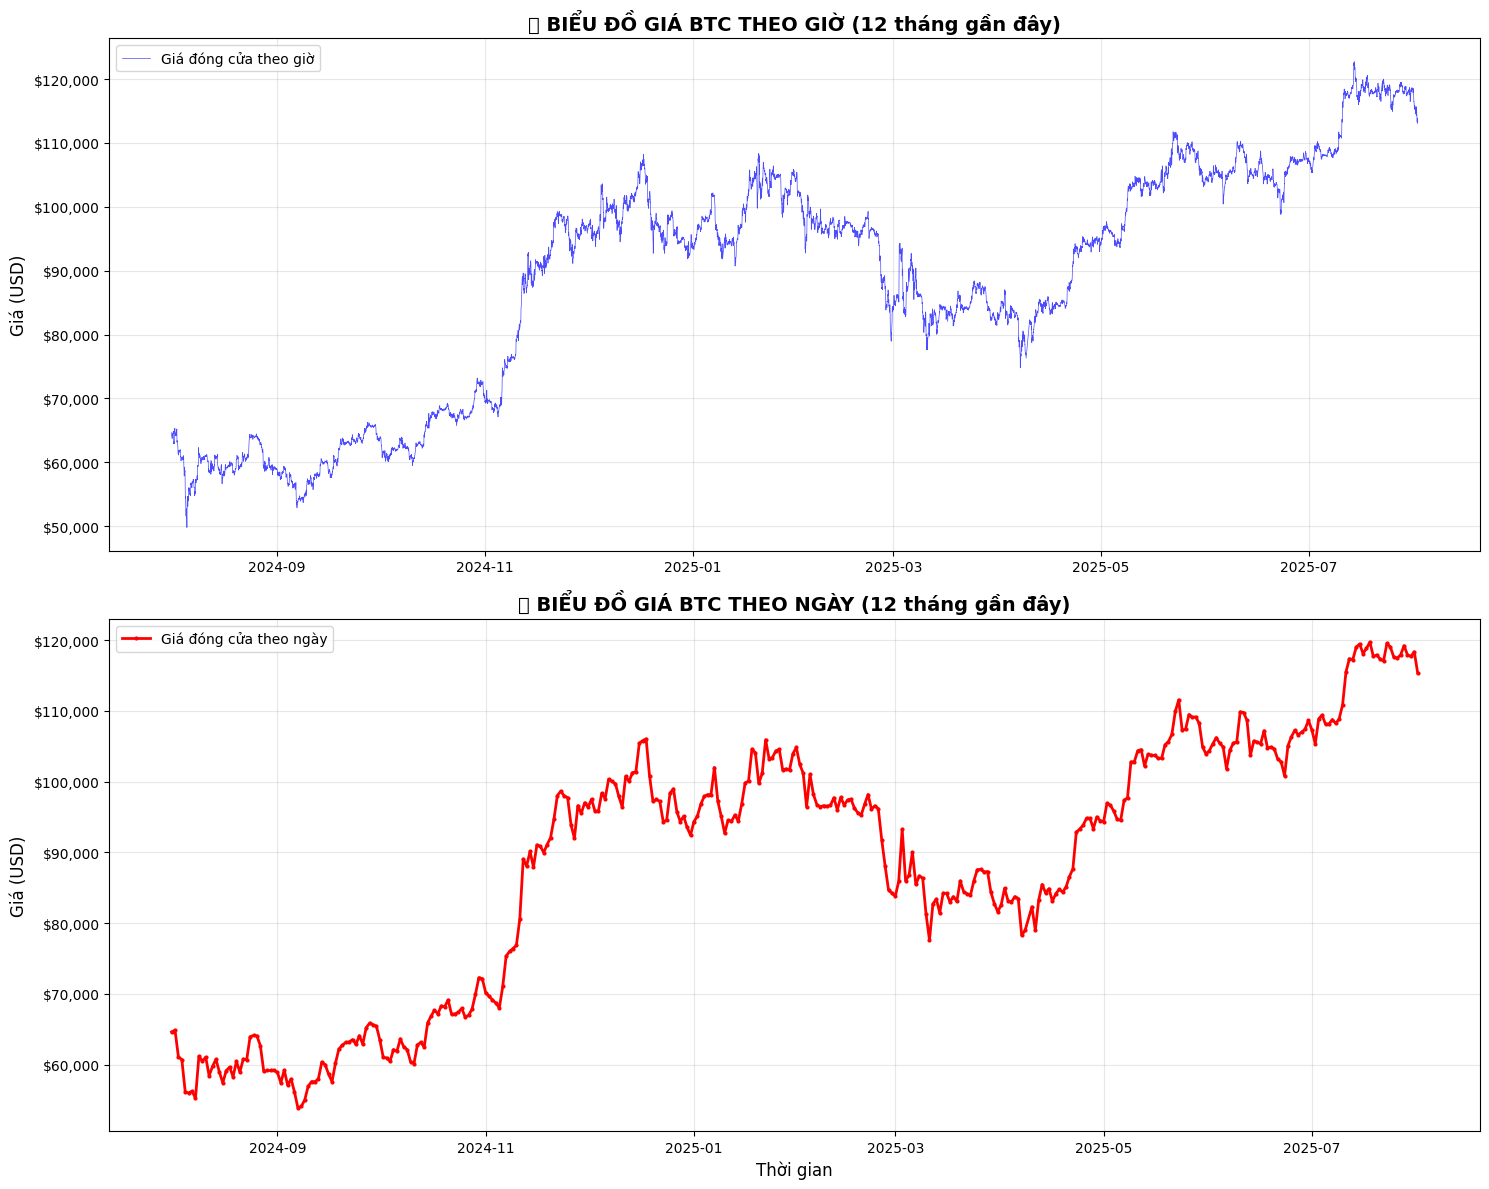


✅ Đã tạo thành công biểu đồ so sánh!
🔍 Quan sát: Biểu đồ theo giờ cho thấy chi tiết hơn về biến động giá trong ngắn hạn
🔍 Quan sát: Biểu đồ theo ngày cho thấy xu hướng tổng thể rõ ràng hơn


In [9]:
# Tạo biểu đồ so sánh dữ liệu theo giờ và theo ngày
print("📊 TẠO BIỂU ĐỒ SO SÁNH DỮ LIỆU THEO GIỜ VÀ THEO NGÀY:")
print("=" * 60)

# Thiết lập figure với 2 subplots
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Lấy dữ liệu gần đây để hiển thị (1 năm cuối)
recent_months = 12
cutoff_date = df_daily_sorted['Date'].max() - pd.DateOffset(months=recent_months)

# Lọc dữ liệu gần đây
df_hourly_recent = df_sorted[df_sorted['Date'] >= cutoff_date].copy()
df_daily_recent = df_daily_sorted[df_daily_sorted['Date'] >= cutoff_date].copy()

print(f"📅 Hiển thị dữ liệu từ: {cutoff_date.strftime('%Y-%m-%d')}")
print(f"📊 Dữ liệu theo giờ (gần đây): {len(df_hourly_recent):,} điểm")
print(f"📊 Dữ liệu theo ngày (gần đây): {len(df_daily_recent):,} điểm")

# Biểu đồ 1: Giá theo giờ
ax1.plot(df_hourly_recent['Date'], df_hourly_recent['Close'], 
         linewidth=0.5, alpha=0.7, color='blue', label='Giá đóng cửa theo giờ')
ax1.set_title('🕐 BIỂU ĐỒ GIÁ BTC THEO GIỜ (12 tháng gần đây)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá (USD)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Format trục y
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Biểu đồ 2: Giá theo ngày
ax2.plot(df_daily_recent['Date'], df_daily_recent['Close'], 
         linewidth=2, color='red', label='Giá đóng cửa theo ngày', marker='o', markersize=2)
ax2.set_title('📅 BIỂU ĐỒ GIÁ BTC THEO NGÀY (12 tháng gần đây)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Thời gian', fontsize=12)
ax2.set_ylabel('Giá (USD)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# Format trục y
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Điều chỉnh layout
plt.tight_layout()
plt.show()

print(f"\n✅ Đã tạo thành công biểu đồ so sánh!")
print(f"🔍 Quan sát: Biểu đồ theo giờ cho thấy chi tiết hơn về biến động giá trong ngắn hạn")
print(f"🔍 Quan sát: Biểu đồ theo ngày cho thấy xu hướng tổng thể rõ ràng hơn")

📊 BIỂU ĐỒ VOLUME VÀ THỐNG KÊ SO SÁNH:


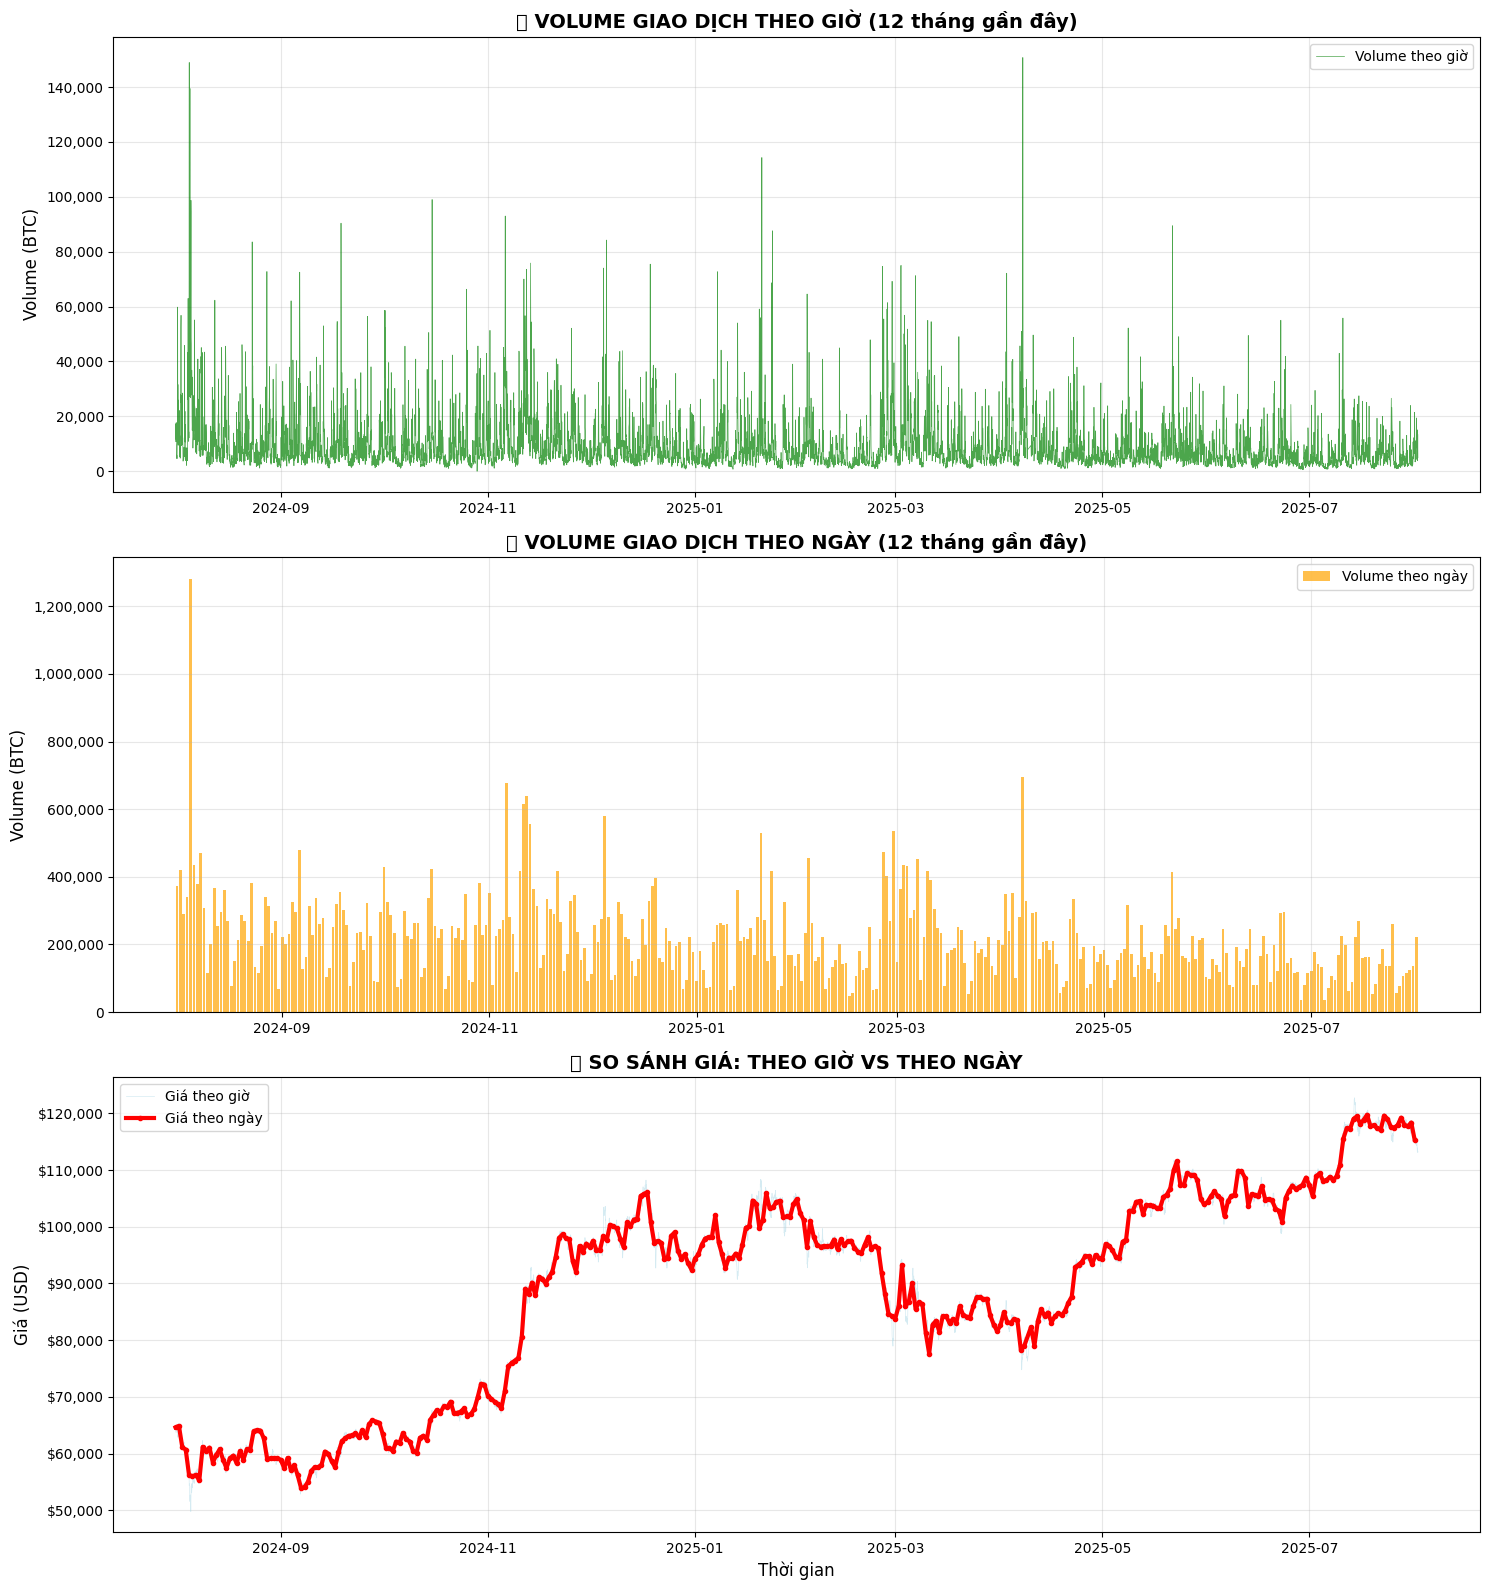


📈 THỐNG KÊ SO SÁNH CHI TIẾT:
🕐 DỮ LIỆU THEO GIỜ:
   📊 Số điểm dữ liệu: 8,760
   💰 Giá trung bình: $88,513.40
   📊 Độ lệch chuẩn giá: $18,216.75
   📈 Volume trung bình: 9,048.47 BTC
   📊 Độ biến động giá (%): 20.58%

📅 DỮ LIỆU THEO NGÀY:
   📊 Số điểm dữ liệu: 365
   💰 Giá trung bình: $88,429.30
   📊 Độ lệch chuẩn giá: $18,232.02
   📈 Volume trung bình: 217,163.27 BTC
   📊 Độ biến động giá (%): 20.62%

🔍 NHẬN XÉT:
   📊 Tỷ lệ dữ liệu: 1 ngày = 24 giờ
   📈 Dữ liệu theo giờ cho độ chi tiết cao hơn 24 lần
   📅 Dữ liệu theo ngày giúp nhìn xu hướng dài hạn rõ hơn
   💡 Kết hợp cả 2 timeframe để có cái nhìn toàn diện nhất


In [10]:
# Tạo biểu đồ so sánh Volume và thống kê chi tiết
print("📊 BIỂU ĐỒ VOLUME VÀ THỐNG KÊ SO SÁNH:")
print("=" * 60)

# Tạo figure với 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 16))

# Biểu đồ 1: Volume theo giờ
ax1.plot(df_hourly_recent['Date'], df_hourly_recent['Volume'], 
         linewidth=0.5, alpha=0.7, color='green', label='Volume theo giờ')
ax1.set_title('📊 VOLUME GIAO DỊCH THEO GIỜ (12 tháng gần đây)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Volume (BTC)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Biểu đồ 2: Volume theo ngày
ax2.bar(df_daily_recent['Date'], df_daily_recent['Volume'], 
        width=0.8, alpha=0.7, color='orange', label='Volume theo ngày')
ax2.set_title('📊 VOLUME GIAO DỊCH THEO NGÀY (12 tháng gần đây)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Volume (BTC)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Biểu đồ 3: So sánh giá trên cùng một chart
ax3.plot(df_hourly_recent['Date'], df_hourly_recent['Close'], 
         linewidth=0.5, alpha=0.5, color='lightblue', label='Giá theo giờ')
ax3.plot(df_daily_recent['Date'], df_daily_recent['Close'], 
         linewidth=3, color='red', label='Giá theo ngày', marker='o', markersize=3)
ax3.set_title('💰 SO SÁNH GIÁ: THEO GIỜ VS THEO NGÀY', fontsize=14, fontweight='bold')
ax3.set_xlabel('Thời gian', fontsize=12)
ax3.set_ylabel('Giá (USD)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Thống kê so sánh
print(f"\n📈 THỐNG KÊ SO SÁNH CHI TIẾT:")
print("=" * 60)

print(f"🕐 DỮ LIỆU THEO GIỜ:")
print(f"   📊 Số điểm dữ liệu: {len(df_hourly_recent):,}")
print(f"   💰 Giá trung bình: ${df_hourly_recent['Close'].mean():,.2f}")
print(f"   📊 Độ lệch chuẩn giá: ${df_hourly_recent['Close'].std():,.2f}")
print(f"   📈 Volume trung bình: {df_hourly_recent['Volume'].mean():,.2f} BTC")
print(f"   📊 Độ biến động giá (%): {(df_hourly_recent['Close'].std() / df_hourly_recent['Close'].mean() * 100):.2f}%")

print(f"\n📅 DỮ LIỆU THEO NGÀY:")
print(f"   📊 Số điểm dữ liệu: {len(df_daily_recent):,}")
print(f"   💰 Giá trung bình: ${df_daily_recent['Close'].mean():,.2f}")
print(f"   📊 Độ lệch chuẩn giá: ${df_daily_recent['Close'].std():,.2f}")
print(f"   📈 Volume trung bình: {df_daily_recent['Volume'].mean():,.2f} BTC")
print(f"   📊 Độ biến động giá (%): {(df_daily_recent['Close'].std() / df_daily_recent['Close'].mean() * 100):.2f}%")

print(f"\n🔍 NHẬN XÉT:")
ratio = len(df_hourly_recent) / len(df_daily_recent)
print(f"   📊 Tỷ lệ dữ liệu: 1 ngày = {ratio:.0f} giờ")
print(f"   📈 Dữ liệu theo giờ cho độ chi tiết cao hơn {ratio:.0f} lần")
print(f"   📅 Dữ liệu theo ngày giúp nhìn xu hướng dài hạn rõ hơn")
print(f"   💡 Kết hợp cả 2 timeframe để có cái nhìn toàn diện nhất")

# 📈 Trendfollowing Fattail Strategy

## 🎯 Phân tích dữ liệu cơ bản
Phần này tập trung vào việc:
- **Phân tích dữ liệu đa khung thời gian** (giờ và ngày)
- **Thống kê cơ bản** về giá và volume
- **Chuẩn bị dữ liệu** cho các chiến lược tiếp theo

## 📊 Kết quả đã có
- ✅ Dữ liệu theo giờ: 48,905 điểm
- ✅ Dữ liệu theo ngày: 2,039 điểm  
- ✅ Biểu đồ so sánh giữa 2 timeframe
- ✅ Thống kê volume và volatility

---
*Chưa triển khai chiến lược cụ thể - chỉ là phân tích dữ liệu thống kê*

In [16]:
# Tổng kết phân tích dữ liệu multi-timeframe
print("📊 TỔNG KẾT PHÂN TÍCH DỮ LIỆU:")
print("=" * 50)

print(f"🗂️  DỮ LIỆU ĐÃ XỬ LÝ:")
print(f"   📈 Dữ liệu theo giờ: {len(df_sorted):,} điểm")
print(f"   📅 Dữ liệu theo ngày: {len(df_daily_sorted):,} điểm")
print(f"   📆 Thời gian: {df_sorted['Date'].min().strftime('%Y-%m-%d')} đến {df_sorted['Date'].max().strftime('%Y-%m-%d')}")

print(f"\n💰 THỐNG KÊ GIÁ (Toàn bộ dữ liệu):")
print(f"   💵 Giá thấp nhất: ${df_sorted['Low'].min():,.2f}")
print(f"   💵 Giá cao nhất: ${df_sorted['High'].max():,.2f}")
print(f"   💵 Giá trung bình: ${df_sorted['Close'].mean():,.2f}")
print(f"   📊 Độ biến động: {df_sorted['Close'].std() / df_sorted['Close'].mean() * 100:.2f}%")

print(f"\n📊 THỐNG KÊ VOLUME:")
print(f"   📈 Volume trung bình (giờ): {df_sorted['Volume'].mean():,.2f} BTC")
print(f"   📈 Volume trung bình (ngày): {df_daily_sorted['Volume'].mean():,.2f} BTC")
print(f"   📈 Tổng volume: {df_sorted['Volume'].sum():,.2f} BTC")

print(f"\n✅ HOÀN THÀNH:")
print(f"   🎯 Dữ liệu đã được làm sạch và sắp xếp")
print(f"   📊 Đã tạo được 2 timeframe: giờ và ngày")
print(f"   📈 Đã có biểu đồ trực quan so sánh")
print(f"   🚀 Sẵn sàng cho việc phát triển chiến lược!")

print(f"\n💡 BƯỚC TIẾP THEO:")
print(f"   🔬 Nghiên cứu các chỉ báo kỹ thuật")
print(f"   📈 Phát triển logic entry/exit")
print(f"   🎯 Backtesting và optimization")
print(f"   📊 Risk management")

📊 TỔNG KẾT PHÂN TÍCH DỮ LIỆU:
🗂️  DỮ LIỆU ĐÃ XỬ LÝ:
   📈 Dữ liệu theo giờ: 48,905 điểm
   📅 Dữ liệu theo ngày: 2,039 điểm
   📆 Thời gian: 2020-01-01 đến 2025-08-01

💰 THỐNG KÊ GIÁ (Toàn bộ dữ liệu):
   💵 Giá thấp nhất: $3,621.81
   💵 Giá cao nhất: $123,300.00
   💵 Giá trung bình: $42,798.45
   📊 Độ biến động: 65.14%

📊 THỐNG KÊ VOLUME:
   📈 Volume trung bình (giờ): 14,618.36 BTC
   📈 Volume trung bình (ngày): 350,618.35 BTC
   📈 Tổng volume: 714,910,822.01 BTC

✅ HOÀN THÀNH:
   🎯 Dữ liệu đã được làm sạch và sắp xếp
   📊 Đã tạo được 2 timeframe: giờ và ngày
   📈 Đã có biểu đồ trực quan so sánh
   🚀 Sẵn sàng cho việc phát triển chiến lược!

💡 BƯỚC TIẾP THEO:
   🔬 Nghiên cứu các chỉ báo kỹ thuật
   📈 Phát triển logic entry/exit
   🎯 Backtesting và optimization
   📊 Risk management


In [17]:
# Elder Impulse System - Tính toán trên khung ngày
print("🎯 ELDER IMPULSE SYSTEM - KHUNG NGÀY:")
print("=" * 50)

# Sao chép dữ liệu để tính toán
df_daily_elder = df_daily_sorted.copy()

# 1. Tính EMA 13
def calculate_ema(prices, period):
    """Tính Exponential Moving Average"""
    alpha = 2 / (period + 1)
    ema = prices.copy()
    for i in range(1, len(prices)):
        ema.iloc[i] = alpha * prices.iloc[i] + (1 - alpha) * ema.iloc[i-1]
    return ema

df_daily_elder['EMA_13'] = calculate_ema(df_daily_elder['Close'], 13)

# 2. Tính MACD (12, 26, 9)
def calculate_macd(prices, fast=12, slow=26, signal=9):
    """Tính MACD với thông số mặc định"""
    ema_fast = calculate_ema(prices, fast)
    ema_slow = calculate_ema(prices, slow)
    
    macd_line = ema_fast - ema_slow
    signal_line = calculate_ema(macd_line, signal)
    histogram = macd_line - signal_line
    
    return macd_line, signal_line, histogram

macd_line, signal_line, macd_histogram = calculate_macd(df_daily_elder['Close'])
df_daily_elder['MACD'] = macd_line
df_daily_elder['MACD_Signal'] = signal_line
df_daily_elder['MACD_Histogram'] = macd_histogram

# 3. Tính xu hướng EMA và MACD Histogram
df_daily_elder['EMA_Direction'] = df_daily_elder['EMA_13'].diff() > 0
df_daily_elder['MACD_Direction'] = df_daily_elder['MACD_Histogram'].diff() > 0

# 4. Xác định Elder Impulse Signal
def elder_impulse_signal(ema_direction, macd_direction):
    """
    Xác định tín hiệu Elder Impulse:
    - Green: EMA tăng VÀ MACD Histogram tăng
    - Red: EMA giảm VÀ MACD Histogram giảm  
    - Gray: Không đồng thuận
    """
    if ema_direction and macd_direction:
        return 'Green'
    elif not ema_direction and not macd_direction:
        return 'Red'
    else:
        return 'Gray'

df_daily_elder['Elder_Signal'] = df_daily_elder.apply(
    lambda row: elder_impulse_signal(row['EMA_Direction'], row['MACD_Direction']), 
    axis=1
)

print(f"✅ Đã tính toán Elder Impulse cho {len(df_daily_elder)} ngày")
print(f"\n📊 Thống kê Elder Impulse:")
signal_counts = df_daily_elder['Elder_Signal'].value_counts()
for signal, count in signal_counts.items():
    pct = count / len(df_daily_elder) * 100
    if signal == 'Green':
        print(f"   🟢 {signal}: {count} ngày ({pct:.1f}%)")
    elif signal == 'Red':
        print(f"   🔴 {signal}: {count} ngày ({pct:.1f}%)")
    else:
        print(f"   ⚪ {signal}: {count} ngày ({pct:.1f}%)")

print(f"\n🔍 Mẫu dữ liệu gần đây:")
print(df_daily_elder[['Date', 'Close', 'EMA_13', 'MACD_Histogram', 'Elder_Signal']].tail(10))

🎯 ELDER IMPULSE SYSTEM - KHUNG NGÀY:
✅ Đã tính toán Elder Impulse cho 2039 ngày

📊 Thống kê Elder Impulse:
   ⚪ Gray: 782 ngày (38.4%)
   🟢 Green: 685 ngày (33.6%)
   🔴 Red: 572 ngày (28.1%)

🔍 Mẫu dữ liệu gần đây:
           Date     Close         EMA_13  MACD_Histogram Elder_Signal
2029 2025-07-23  119587.6  116870.353662      -14.974883        Green
2030 2025-07-24  119024.0  117178.017425      -63.310080         Gray
2031 2025-07-25  117620.0  117241.157793     -206.711664         Gray
2032 2025-07-26  117473.2  117274.306680     -321.478965         Gray
2033 2025-07-27  117927.2  117367.577154     -373.208194         Gray
2034 2025-07-28  119228.8  117633.466132     -327.772179        Green
2035 2025-07-29  117945.0  117677.970970     -388.063832         Gray
2036 2025-07-30  117699.9  117681.103689     -444.291067         Gray
2037 2025-07-31  118368.5  117779.303162     -435.700450        Green
2038 2025-08-01  115366.9  117434.674139     -620.164135          Red


In [18]:
# Áp dụng Elder Impulse từ khung ngày lên khung giờ
print("📈 ÁP DỤNG ELDER IMPULSE LÊN KHUNG GIỜ:")
print("=" * 50)

# Chuẩn bị dữ liệu khung giờ
df_hourly_elder = df_sorted.copy()
df_hourly_elder['Date_Only'] = df_hourly_elder['Date'].dt.date

# Tạo mapping từ khung ngày
daily_elder_signals = df_daily_elder[['Day', 'Elder_Signal']].copy()
daily_elder_signals.rename(columns={'Day': 'Date_Only'}, inplace=True)

# Merge tín hiệu Elder Impulse vào khung giờ
df_hourly_elder = df_hourly_elder.merge(daily_elder_signals, on='Date_Only', how='left')

# Thống kê phân bổ tín hiệu trên khung giờ
print(f"✅ Đã áp dụng Elder Impulse lên khung giờ:")
print(f"   📊 Tổng số giờ: {len(df_hourly_elder):,}")
print(f"   📅 Có tín hiệu: {df_hourly_elder['Elder_Signal'].notna().sum():,}")

# Thống kê phân bổ theo tín hiệu
hourly_signal_counts = df_hourly_elder['Elder_Signal'].value_counts()
total_hours = len(df_hourly_elder)

print(f"\n📊 Phân bổ giờ theo Elder Impulse:")
for signal, count in hourly_signal_counts.items():
    pct = count / total_hours * 100
    if signal == 'Green':
        print(f"   🟢 {signal}: {count:,} giờ ({pct:.1f}%)")
    elif signal == 'Red':
        print(f"   🔴 {signal}: {count:,} giờ ({pct:.1f}%)")
    else:
        print(f"   ⚪ {signal}: {count:,} giờ ({pct:.1f}%)")

print(f"\n🔍 Mẫu dữ liệu khung giờ có Elder Signal:")
sample_data = df_hourly_elder[['Date', 'Close', 'Elder_Signal']].tail(24)  # 24 giờ gần đây
print(sample_data)

📈 ÁP DỤNG ELDER IMPULSE LÊN KHUNG GIỜ:
✅ Đã áp dụng Elder Impulse lên khung giờ:
   📊 Tổng số giờ: 48,905
   📅 Có tín hiệu: 48,905

📊 Phân bổ giờ theo Elder Impulse:
   ⚪ Gray: 18,759 giờ (38.4%)
   🟢 Green: 16,426 giờ (33.6%)
   🔴 Red: 13,720 giờ (28.1%)

🔍 Mẫu dữ liệu khung giờ có Elder Signal:
                     Date     Close Elder_Signal
48881 2025-08-01 00:00:00  115366.9          Red
48882 2025-08-01 01:00:00  115270.2          Red
48883 2025-08-01 02:00:00  115908.8          Red
48884 2025-08-01 03:00:00  115595.7          Red
48885 2025-08-01 04:00:00  115648.3          Red
48886 2025-08-01 05:00:00  115511.4          Red
48887 2025-08-01 06:00:00  115112.8          Red
48888 2025-08-01 07:00:00  115015.1          Red
48889 2025-08-01 08:00:00  114552.3          Red
48890 2025-08-01 09:00:00  114890.3          Red
48891 2025-08-01 10:00:00  114697.7          Red
48892 2025-08-01 11:00:00  115246.6          Red
48893 2025-08-01 12:00:00  115674.9          Red
48894 2025-08-01

🎨 BIỂU ĐỒ ELDER IMPULSE - 3 TRẠNG THÁI:
📅 Hiển thị 3 tháng gần đây: 2,209 giờ


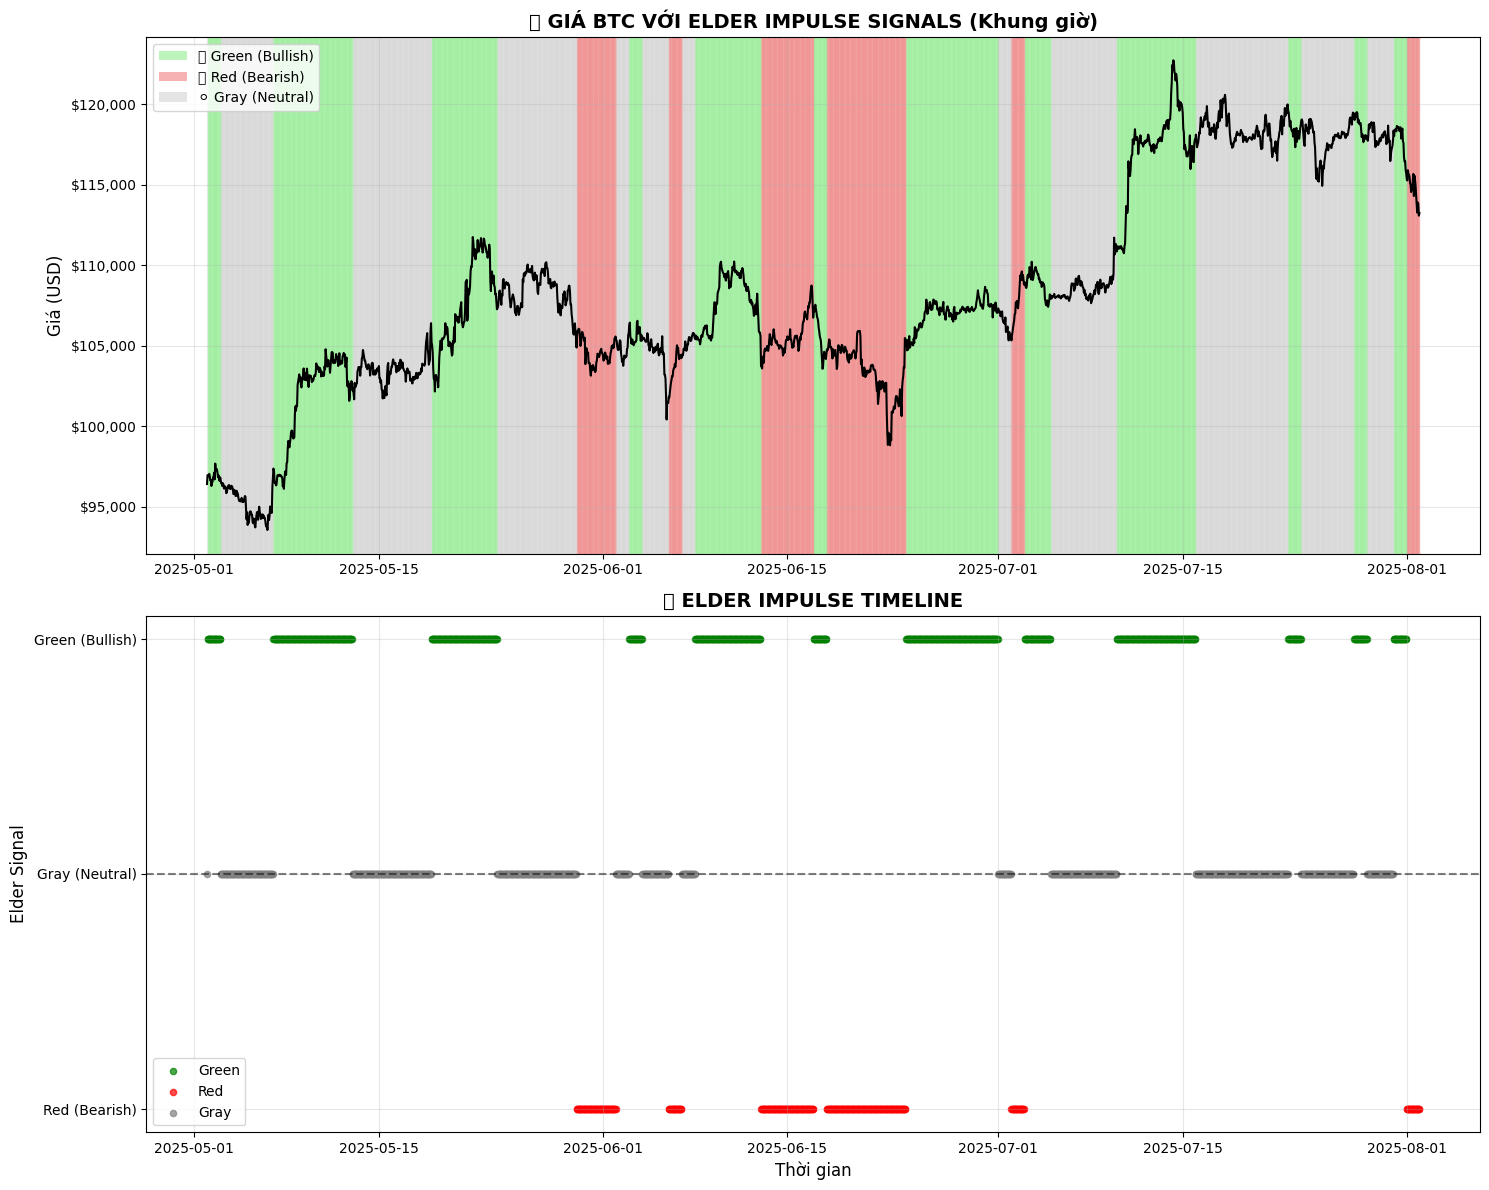


✅ Đã tạo biểu đồ Elder Impulse!
🔍 Biểu đồ cho thấy rõ 3 trạng thái Elder Impulse trên khung giờ


In [19]:
# Biểu đồ Elder Impulse: 3 trạng thái trên khung giờ
print("🎨 BIỂU ĐỒ ELDER IMPULSE - 3 TRẠNG THÁI:")
print("=" * 50)

# Lấy dữ liệu 3 tháng gần đây để hiển thị
recent_months = 3
cutoff_date = df_hourly_elder['Date'].max() - pd.DateOffset(months=recent_months)
df_viz = df_hourly_elder[df_hourly_elder['Date'] >= cutoff_date].copy()

print(f"📅 Hiển thị {recent_months} tháng gần đây: {len(df_viz):,} giờ")

# Tạo figure với 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Giá với nền màu Elder Impulse
colors = {'Green': 'lightgreen', 'Red': 'lightcoral', 'Gray': 'lightgray'}

# Tạo nền màu theo Elder Signal
for i in range(len(df_viz) - 1):
    current_signal = df_viz.iloc[i]['Elder_Signal']
    color = colors.get(current_signal, 'lightgray')
    
    # Tạo vùng màu từ thời điểm hiện tại đến thời điểm tiếp theo
    ax1.axvspan(df_viz.iloc[i]['Date'], 
                df_viz.iloc[i+1]['Date'], 
                color=color, alpha=0.3)

# Vẽ đường giá
ax1.plot(df_viz['Date'], df_viz['Close'], 
         color='black', linewidth=1.5, label='Giá BTC')

ax1.set_title('💰 GIÁ BTC VỚI ELDER IMPULSE SIGNALS (Khung giờ)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá (USD)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Thêm legend cho màu sắc
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.6, label='🟢 Green (Bullish)'),
    Patch(facecolor='lightcoral', alpha=0.6, label='🔴 Red (Bearish)'),
    Patch(facecolor='lightgray', alpha=0.6, label='⚪ Gray (Neutral)')
]
ax1.legend(handles=legend_elements, loc='upper left')

# Plot 2: Elder Impulse signals dạng timeline
signal_numeric = {'Green': 1, 'Red': -1, 'Gray': 0}
df_viz['Signal_Numeric'] = df_viz['Elder_Signal'].map(signal_numeric)

# Vẽ timeline
colors_line = {'Green': 'green', 'Red': 'red', 'Gray': 'gray'}
for signal in ['Green', 'Red', 'Gray']:
    signal_data = df_viz[df_viz['Elder_Signal'] == signal]
    if len(signal_data) > 0:
        ax2.scatter(signal_data['Date'], signal_data['Signal_Numeric'], 
                   color=colors_line[signal], label=f'{signal}', 
                   s=20, alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('🎯 ELDER IMPULSE TIMELINE', fontsize=14, fontweight='bold')
ax2.set_xlabel('Thời gian', fontsize=12)
ax2.set_ylabel('Elder Signal', fontsize=12)
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Red (Bearish)', 'Gray (Neutral)', 'Green (Bullish)'])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Đã tạo biểu đồ Elder Impulse!")
print(f"🔍 Biểu đồ cho thấy rõ 3 trạng thái Elder Impulse trên khung giờ")

In [20]:
# Thống kê chi tiết 3 trạng thái Elder Impulse
print("📊 THỐNG KÊ CHI TIẾT ELDER IMPULSE:")
print("=" * 60)

# Tính toán thời gian trung bình cho mỗi trạng thái
df_periods = []
current_signal = None
start_time = None

for i, row in df_hourly_elder.iterrows():
    signal = row['Elder_Signal']
    
    if signal != current_signal:
        # Kết thúc period cũ
        if current_signal is not None and start_time is not None:
            duration = (row['Date'] - start_time).total_seconds() / 3600  # giờ
            df_periods.append({
                'Signal': current_signal,
                'Duration_Hours': duration,
                'Start': start_time,
                'End': row['Date']
            })
        
        # Bắt đầu period mới
        current_signal = signal
        start_time = row['Date']

# Xử lý period cuối cùng
if current_signal is not None and start_time is not None:
    duration = (df_hourly_elder.iloc[-1]['Date'] - start_time).total_seconds() / 3600
    df_periods.append({
        'Signal': current_signal,
        'Duration_Hours': duration,
        'Start': start_time,
        'End': df_hourly_elder.iloc[-1]['Date']
    })

periods_df = pd.DataFrame(df_periods)

print(f"📈 THỐNG KÊ THEO PERIOD:")
print(f"   🔄 Tổng số period: {len(periods_df):,}")

for signal in ['Green', 'Red', 'Gray']:
    signal_periods = periods_df[periods_df['Signal'] == signal]
    if len(signal_periods) > 0:
        avg_duration = signal_periods['Duration_Hours'].mean()
        max_duration = signal_periods['Duration_Hours'].max()
        min_duration = signal_periods['Duration_Hours'].min()
        num_periods = len(signal_periods)
        
        if signal == 'Green':
            emoji = "🟢"
        elif signal == 'Red':
            emoji = "🔴"
        else:
            emoji = "⚪"
            
        print(f"\n{emoji} {signal.upper()}:")
        print(f"   📊 Số period: {num_periods:,}")
        print(f"   ⏰ Thời gian trung bình: {avg_duration:.1f} giờ")
        print(f"   📈 Thời gian dài nhất: {max_duration:.1f} giờ")
        print(f"   📉 Thời gian ngắn nhất: {min_duration:.1f} giờ")

# Thống kê transition giữa các trạng thái
print(f"\n🔄 THỐNG KÊ CHUYỂN ĐỔI TRẠNG THÁI:")
transitions = {}
for i in range(len(periods_df) - 1):
    from_signal = periods_df.iloc[i]['Signal']
    to_signal = periods_df.iloc[i + 1]['Signal']
    key = f"{from_signal} → {to_signal}"
    transitions[key] = transitions.get(key, 0) + 1

for transition, count in sorted(transitions.items(), key=lambda x: x[1], reverse=True):
    pct = count / (len(periods_df) - 1) * 100
    print(f"   {transition}: {count} lần ({pct:.1f}%)")

print(f"\n💡 NHẬN XÉT:")
print(f"   📊 Elder Impulse cung cấp tín hiệu trend rõ ràng")
print(f"   🔄 Các period có độ dài khác nhau → cần quản lý thời gian")
print(f"   🎯 Có thể sử dụng cho entry/exit timing")
print(f"   ⚠️  Cần backtest để đánh giá hiệu quả thực tế")

print(f"\n✅ HOÀN THÀNH PHÂN TÍCH ELDER IMPULSE!")

📊 THỐNG KÊ CHI TIẾT ELDER IMPULSE:
📈 THỐNG KÊ THEO PERIOD:
   🔄 Tổng số period: 738

🟢 GREEN:
   📊 Số period: 237
   ⏰ Thời gian trung bình: 69.4 giờ
   📈 Thời gian dài nhất: 288.0 giờ
   📉 Thời gian ngắn nhất: 24.0 giờ

🔴 RED:
   📊 Số period: 209
   ⏰ Thời gian trung bình: 65.8 giờ
   📈 Thời gian dài nhất: 216.0 giờ
   📉 Thời gian ngắn nhất: 23.0 giờ

⚪ GRAY:
   📊 Số period: 292
   ⏰ Thời gian trung bình: 64.3 giờ
   📈 Thời gian dài nhất: 312.0 giờ
   📉 Thời gian ngắn nhất: 23.0 giờ

🔄 THỐNG KÊ CHUYỂN ĐỔI TRẠNG THÁI:
   Green → Gray: 166 lần (22.5%)
   Gray → Green: 155 lần (21.0%)
   Gray → Red: 137 lần (18.6%)
   Red → Gray: 126 lần (17.1%)
   Red → Green: 82 lần (11.1%)
   Green → Red: 71 lần (9.6%)

💡 NHẬN XÉT:
   📊 Elder Impulse cung cấp tín hiệu trend rõ ràng
   🔄 Các period có độ dài khác nhau → cần quản lý thời gian
   🎯 Có thể sử dụng cho entry/exit timing
   ⚠️  Cần backtest để đánh giá hiệu quả thực tế

✅ HOÀN THÀNH PHÂN TÍCH ELDER IMPULSE!


In [23]:
# Tính toán các chỉ báo bổ sung cho Elder Impulse System
print("🔧 TÍNH TOÁN CÁC CHỈ BÁO BỔ SUNG:")
print("=" * 60)

# 1. Tính ATR (Average True Range) 2.5 periods
def calculate_atr(high, low, close, period=14):
    """Tính Average True Range"""
    # True Range = max(H-L, H-C_prev, C_prev-L)
    tr1 = high - low
    tr2 = np.abs(high - close.shift(1))
    tr3 = np.abs(low - close.shift(1))
    
    true_range = np.maximum(tr1, np.maximum(tr2, tr3))
    atr = true_range.rolling(window=period).mean()
    
    return atr

# Tính ATR cho khung giờ
df_hourly_elder['ATR_14'] = calculate_atr(
    df_hourly_elder['High'], 
    df_hourly_elder['Low'], 
    df_hourly_elder['Close'], 
    period=14
)

# ATR multiplier 2.5
df_hourly_elder['ATR_2_5'] = df_hourly_elder['ATR_14'] * 2.5

# 2. Tính EMA 25
df_hourly_elder['EMA_25'] = calculate_ema(df_hourly_elder['Close'], 25)

# 3. Xác định Elder Signal từ ngày hôm trước (tránh redraw)
df_hourly_elder['Elder_Signal_Prev'] = df_hourly_elder['Elder_Signal'].shift(24)  # Shift 24h = 1 ngày

# 4. SafeZone Stop Calculation
def calculate_safezone_stop(high, low, close, volume, atr, lookback=22):
    """
    Tính SafeZone Stop dựa trên:
    - ATR cho biến động
    - Directional Movement để loại bỏ nhiễu
    - Penetration factor dựa trên volume
    """
    
    # Tính Directional Movement
    up_move = high - high.shift(1)
    down_move = low.shift(1) - low
    
    # DM+ và DM-
    dm_plus = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    dm_minus = np.where((down_move > up_move) & (down_move > 0), down_move, 0)
    
    dm_plus = pd.Series(dm_plus, index=high.index)
    dm_minus = pd.Series(dm_minus, index=high.index)
    
    # Smoothed DM
    dm_plus_smooth = dm_plus.rolling(window=lookback).mean()
    dm_minus_smooth = dm_minus.rolling(window=lookback).mean()
    
    # Penetration factor (dựa trên tỷ lệ DM)
    total_dm = dm_plus_smooth + dm_minus_smooth
    penetration_factor = np.where(total_dm > 0, 
                                  np.minimum(dm_plus_smooth / total_dm, dm_minus_smooth / total_dm) * 3,
                                  2.0)
    
    # SafeZone multiplier
    safezone_multiplier = atr * penetration_factor
    
    return safezone_multiplier, dm_plus_smooth, dm_minus_smooth

# Tính SafeZone Stop
safezone_mult, dm_plus, dm_minus = calculate_safezone_stop(
    df_hourly_elder['High'],
    df_hourly_elder['Low'], 
    df_hourly_elder['Close'],
    df_hourly_elder['Volume'],
    df_hourly_elder['ATR_14']
)

df_hourly_elder['SafeZone_Multiplier'] = safezone_mult
df_hourly_elder['DM_Plus'] = dm_plus
df_hourly_elder['DM_Minus'] = dm_minus

# Long và Short SafeZone Stops
df_hourly_elder['SafeZone_Long_Stop'] = df_hourly_elder['Close'] - df_hourly_elder['SafeZone_Multiplier']
df_hourly_elder['SafeZone_Short_Stop'] = df_hourly_elder['Close'] + df_hourly_elder['SafeZone_Multiplier']

# 5. Force Index Calculation
def calculate_force_index(close, volume, period=13):
    """
    Force Index = (Close - Close_prev) * Volume
    Smoothed với EMA
    """
    raw_force = (close - close.shift(1)) * volume
    # Loại bỏ NaN values trước khi tính EMA
    raw_force = raw_force.fillna(0)
    force_index = calculate_ema(raw_force, period)
    return force_index

df_hourly_elder['Force_Index'] = calculate_force_index(
    df_hourly_elder['Close'], 
    df_hourly_elder['Volume']
)

print(f"✅ Đã tính toán các chỉ báo bổ sung:")
print(f"   📊 ATR 14: Biến động trung bình")
print(f"   📊 ATR 2.5: ATR nhân hệ số 2.5")  
print(f"   📊 EMA 25: Đường trung bình động 25 periods")
print(f"   📊 Elder Signal Prev: Tín hiệu ngày hôm trước")
print(f"   📊 SafeZone Stop: Stop loss thông minh")
print(f"   📊 Force Index: Đo lực mua/bán")

print(f"\n🔍 Mẫu dữ liệu với các chỉ báo mới:")
sample_cols = ['Date', 'Close', 'ATR_2_5', 'EMA_25', 'Elder_Signal', 
               'Elder_Signal_Prev', 'SafeZone_Long_Stop', 'Force_Index']
print(df_hourly_elder[sample_cols].tail(10))

🔧 TÍNH TOÁN CÁC CHỈ BÁO BỔ SUNG:
✅ Đã tính toán các chỉ báo bổ sung:
   📊 ATR 14: Biến động trung bình
   📊 ATR 2.5: ATR nhân hệ số 2.5
   📊 EMA 25: Đường trung bình động 25 periods
   📊 Elder Signal Prev: Tín hiệu ngày hôm trước
   📊 SafeZone Stop: Stop loss thông minh
   📊 Force Index: Đo lực mua/bán

🔍 Mẫu dữ liệu với các chỉ báo mới:
                     Date     Close      ATR_2_5         EMA_25 Elder_Signal  \
48895 2025-08-01 14:00:00  115568.7  2160.214286  115871.097668          Red   
48896 2025-08-01 15:00:00  115305.3  2151.160714  115827.574771          Red   
48897 2025-08-01 16:00:00  114962.2  2167.071429  115761.007481          Red   
48898 2025-08-01 17:00:00  114387.3  2223.839286  115655.337675          Red   
48899 2025-08-01 18:00:00  113792.7  2291.660714  115512.057853          Red   
48900 2025-08-01 19:00:00  113278.5  2319.125000  115340.245711          Red   
48901 2025-08-01 20:00:00  113900.0  2361.678571  115229.457579          Red   
48902 2025-08-01 21:

In [24]:
# Thống kê và phân tích các chỉ báo mới
print("📊 PHÂN TÍCH CHI TIẾT CÁC CHỈ BÁO MỚI:")
print("=" * 60)

# Loại bỏ NaN để tính toán chính xác
df_analysis = df_hourly_elder.dropna().copy()

print(f"📈 THỐNG KÊ ATR (Average True Range):")
print(f"   📊 ATR 14 trung bình: ${df_analysis['ATR_14'].mean():.2f}")
print(f"   📊 ATR 2.5x trung bình: ${df_analysis['ATR_2_5'].mean():.2f}")
print(f"   📊 ATR max: ${df_analysis['ATR_14'].max():.2f}")
print(f"   📊 ATR min: ${df_analysis['ATR_14'].min():.2f}")
print(f"   📊 ATR hiện tại: ${df_analysis['ATR_14'].iloc[-1]:.2f}")

print(f"\n📈 THỐNG KÊ EMA 25:")
print(f"   💰 EMA 25 hiện tại: ${df_analysis['EMA_25'].iloc[-1]:,.2f}")
print(f"   💰 Giá so với EMA 25: {((df_analysis['Close'].iloc[-1] / df_analysis['EMA_25'].iloc[-1] - 1) * 100):+.2f}%")

# Phân tích vị trí giá so với EMA 25
above_ema = (df_analysis['Close'] > df_analysis['EMA_25']).sum()
below_ema = (df_analysis['Close'] < df_analysis['EMA_25']).sum()
total_points = len(df_analysis)

print(f"   📊 Giá trên EMA 25: {above_ema:,} giờ ({above_ema/total_points*100:.1f}%)")
print(f"   📊 Giá dưới EMA 25: {below_ema:,} giờ ({below_ema/total_points*100:.1f}%)")

print(f"\n🛡️  THỐNG KÊ SAFEZONE STOP:")
safezone_distance = df_analysis['Close'] - df_analysis['SafeZone_Long_Stop']
print(f"   📊 Khoảng cách SafeZone trung bình: ${safezone_distance.mean():.2f}")
print(f"   📊 Khoảng cách SafeZone hiện tại: ${safezone_distance.iloc[-1]:.2f}")
print(f"   📊 SafeZone Stop hiện tại: ${df_analysis['SafeZone_Long_Stop'].iloc[-1]:,.2f}")

# Phân tích hiệu quả SafeZone vs ATR thường
atr_stop_distance = df_analysis['ATR_2_5']
safezone_vs_atr = (safezone_distance / atr_stop_distance).mean()
print(f"   📊 SafeZone vs ATR 2.5 ratio: {safezone_vs_atr:.2f}")

print(f"\n⚡ THỐNG KÊ FORCE INDEX:")
# Tính Force Index cho dữ liệu có đầy đủ
fi_data = df_analysis['Force_Index'].dropna()
if len(fi_data) > 0:
    print(f"   📊 Force Index trung bình: {fi_data.mean():.2f}")
    print(f"   📊 Force Index hiện tại: {fi_data.iloc[-1]:.2f}")
    print(f"   📊 Force Index dương: {(fi_data > 0).sum()} giờ ({(fi_data > 0).sum()/len(fi_data)*100:.1f}%)")
    print(f"   📊 Force Index âm: {(fi_data < 0).sum()} giờ ({(fi_data < 0).sum()/len(fi_data)*100:.1f}%)")

print(f"\n🔄 PHÂN TÍCH ELDER SIGNAL (Tránh Redraw):")
# So sánh Elder Signal hiện tại vs ngày hôm trước
signal_same = (df_analysis['Elder_Signal'] == df_analysis['Elder_Signal_Prev']).sum()
signal_diff = (df_analysis['Elder_Signal'] != df_analysis['Elder_Signal_Prev']).sum()
valid_comparisons = signal_same + signal_diff

if valid_comparisons > 0:
    print(f"   📊 Tín hiệu không đổi: {signal_same:,} giờ ({signal_same/valid_comparisons*100:.1f}%)")
    print(f"   📊 Tín hiệu thay đổi: {signal_diff:,} giờ ({signal_diff/valid_comparisons*100:.1f}%)")

# Thống kê theo trạng thái Elder hiện tại
current_elder = df_analysis['Elder_Signal'].iloc[-1]
current_elder_prev = df_analysis['Elder_Signal_Prev'].iloc[-1] if pd.notna(df_analysis['Elder_Signal_Prev'].iloc[-1]) else 'N/A'

print(f"\n📍 TRẠNG THÁI HIỆN TẠI:")
print(f"   🎯 Elder Signal hiện tại: {current_elder}")
print(f"   🎯 Elder Signal ngày trước: {current_elder_prev}")
print(f"   💰 Giá hiện tại: ${df_analysis['Close'].iloc[-1]:,.2f}")
print(f"   📊 ATR 2.5: ${df_analysis['ATR_2_5'].iloc[-1]:.2f}")
print(f"   🛡️  SafeZone Long Stop: ${df_analysis['SafeZone_Long_Stop'].iloc[-1]:,.2f}")

print(f"\n✅ HOÀN THÀNH PHÂN TÍCH CHỈ BÁO BỔ SUNG!")

📊 PHÂN TÍCH CHI TIẾT CÁC CHỈ BÁO MỚI:
📈 THỐNG KÊ ATR (Average True Range):
   📊 ATR 14 trung bình: $370.99
   📊 ATR 2.5x trung bình: $927.48
   📊 ATR max: $3296.91
   📊 ATR min: $13.31
   📊 ATR hiện tại: $941.43

📈 THỐNG KÊ EMA 25:
   💰 EMA 25 hiện tại: $114,833.14
   💰 Giá so với EMA 25: -1.38%
   📊 Giá trên EMA 25: 25,986 giờ (53.2%)
   📊 Giá dưới EMA 25: 22,895 giờ (46.8%)

🛡️  THỐNG KÊ SAFEZONE STOP:
   📊 Khoảng cách SafeZone trung bình: $369.12
   📊 Khoảng cách SafeZone hiện tại: $714.84
   📊 SafeZone Stop hiện tại: $112,529.96
   📊 SafeZone vs ATR 2.5 ratio: 0.41

⚡ THỐNG KÊ FORCE INDEX:
   📊 Force Index trung bình: -170121.16
   📊 Force Index hiện tại: -2146932.06
   📊 Force Index dương: 23924 giờ (48.9%)
   📊 Force Index âm: 24957 giờ (51.1%)

🔄 PHÂN TÍCH ELDER SIGNAL (Tránh Redraw):
   📊 Tín hiệu không đổi: 31,200 giờ (63.8%)
   📊 Tín hiệu thay đổi: 17,681 giờ (36.2%)

📍 TRẠNG THÁI HIỆN TẠI:
   🎯 Elder Signal hiện tại: Red
   🎯 Elder Signal ngày trước: Green
   💰 Giá hiện tại:

📊 BIỂU ĐỒ TỔNG HỢP ELDER IMPULSE SYSTEM:
📅 Hiển thị 2 tháng gần đây: 1,465 giờ


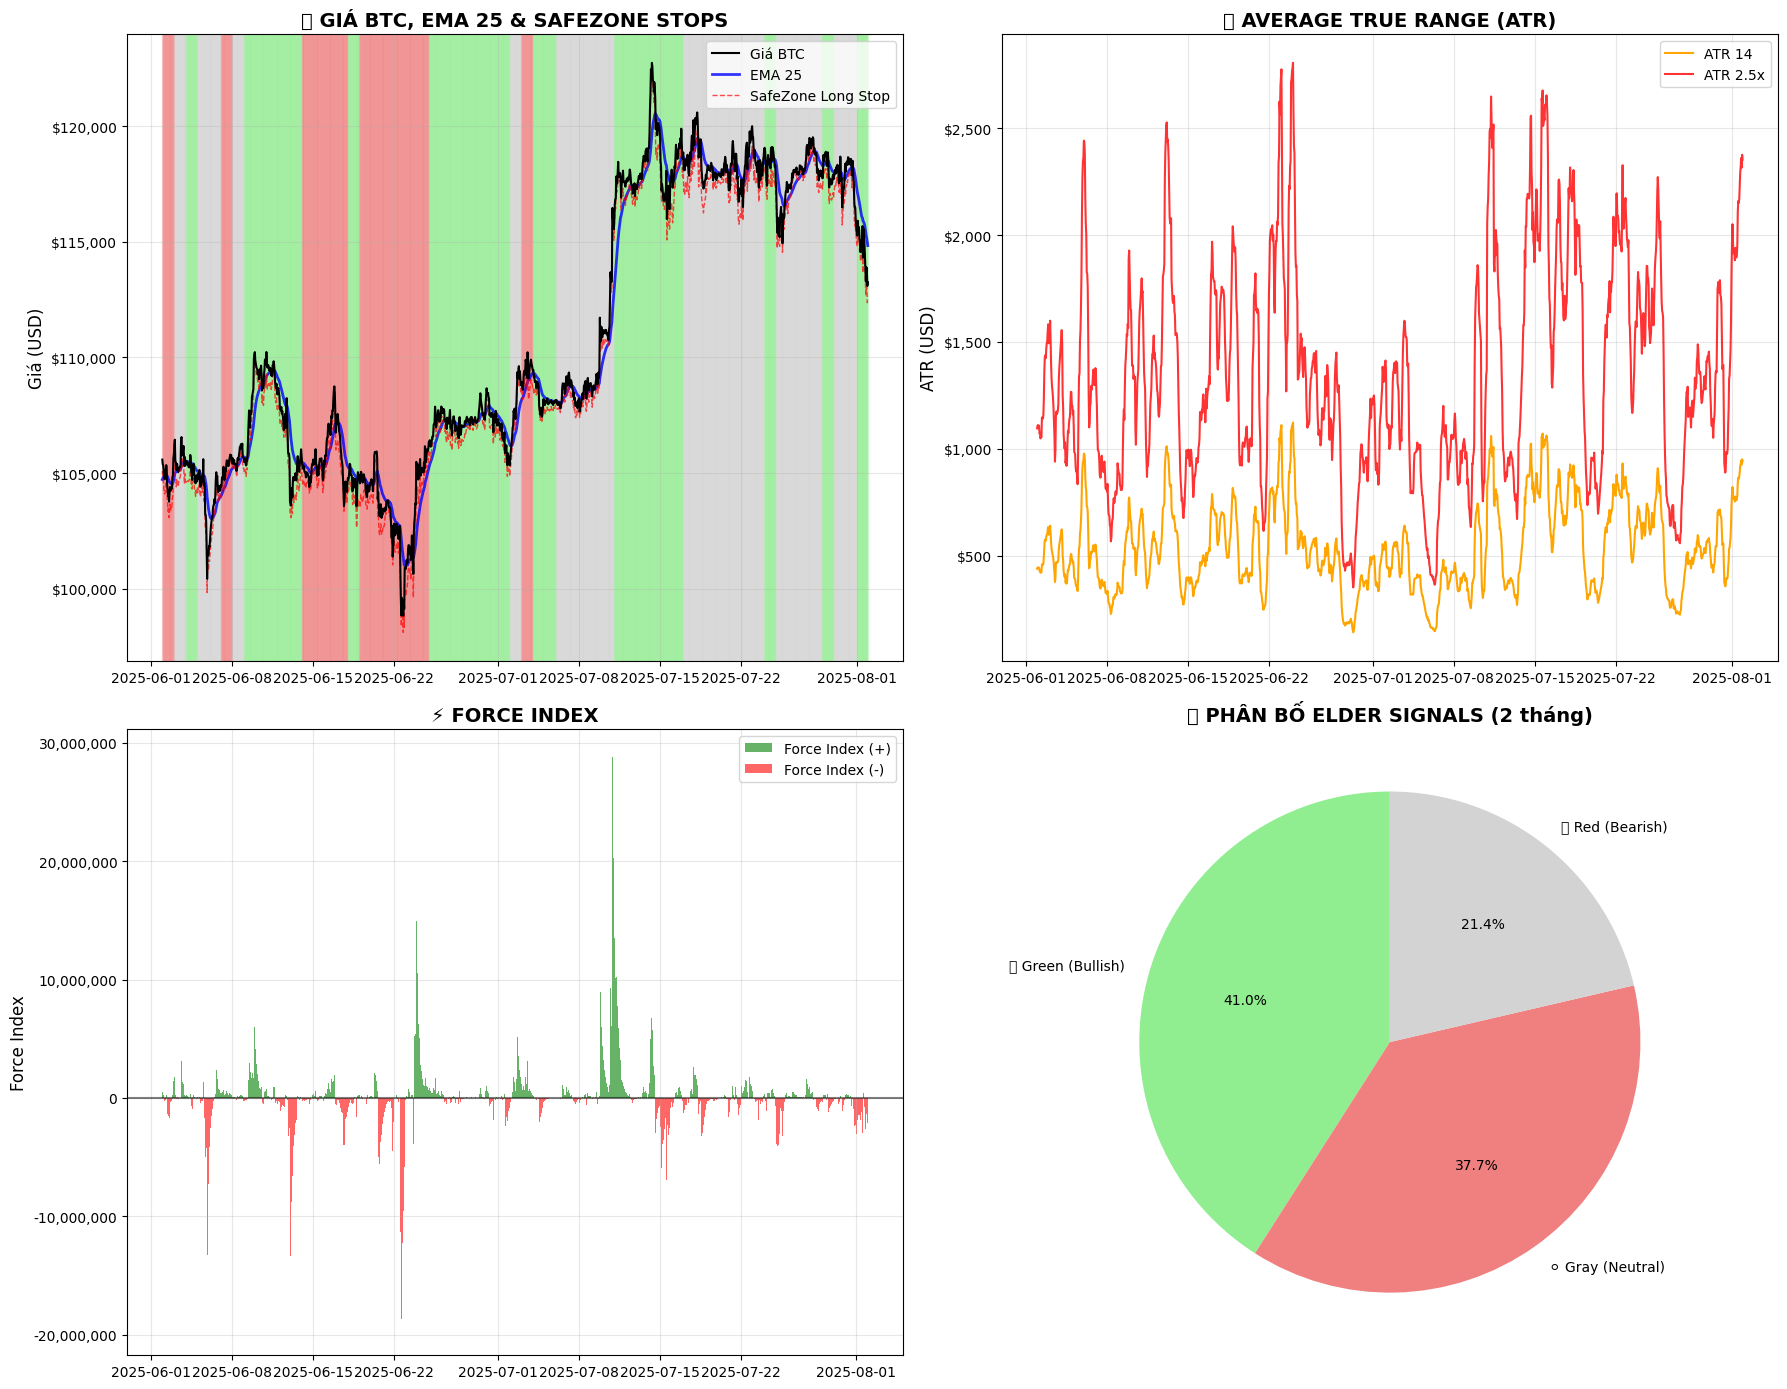


✅ Đã tạo biểu đồ tổng hợp Elder Impulse System!


In [25]:
# Visualization và báo cáo tổng kết Elder Impulse System với các chỉ báo bổ sung
print("📊 BIỂU ĐỒ TỔNG HỢP ELDER IMPULSE SYSTEM:")
print("=" * 60)

# Lấy dữ liệu 2 tháng gần đây để visualization
recent_months = 2
cutoff_date = df_hourly_elder['Date'].max() - pd.DateOffset(months=recent_months)
df_viz_extended = df_hourly_elder[df_hourly_elder['Date'] >= cutoff_date].copy()

print(f"📅 Hiển thị {recent_months} tháng gần đây: {len(df_viz_extended):,} giờ")

# Tạo figure với 4 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Giá với EMA 25 và SafeZone Stops
colors = {'Green': 'lightgreen', 'Red': 'lightcoral', 'Gray': 'lightgray'}

# Tạo nền màu Elder Signal
for i in range(len(df_viz_extended) - 1):
    current_signal = df_viz_extended.iloc[i]['Elder_Signal_Prev']  # Sử dụng signal prev để tránh redraw
    if pd.notna(current_signal):
        color = colors.get(current_signal, 'lightgray')
        ax1.axvspan(df_viz_extended.iloc[i]['Date'], 
                    df_viz_extended.iloc[i+1]['Date'], 
                    color=color, alpha=0.3)

# Vẽ giá và EMA 25
ax1.plot(df_viz_extended['Date'], df_viz_extended['Close'], 
         color='black', linewidth=1.5, label='Giá BTC', zorder=3)
ax1.plot(df_viz_extended['Date'], df_viz_extended['EMA_25'], 
         color='blue', linewidth=2, label='EMA 25', alpha=0.8, zorder=2)

# Vẽ SafeZone Stops
ax1.plot(df_viz_extended['Date'], df_viz_extended['SafeZone_Long_Stop'], 
         color='red', linewidth=1, label='SafeZone Long Stop', alpha=0.7, linestyle='--')

ax1.set_title('💰 GIÁ BTC, EMA 25 & SAFEZONE STOPS', fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá (USD)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: ATR và volatility
ax2.plot(df_viz_extended['Date'], df_viz_extended['ATR_14'], 
         color='orange', linewidth=1.5, label='ATR 14')
ax2.plot(df_viz_extended['Date'], df_viz_extended['ATR_2_5'], 
         color='red', linewidth=1.5, label='ATR 2.5x', alpha=0.8)

ax2.set_title('📊 AVERAGE TRUE RANGE (ATR)', fontsize=14, fontweight='bold')
ax2.set_ylabel('ATR (USD)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 3: Force Index
force_data = df_viz_extended['Force_Index'].dropna()
dates_force = df_viz_extended.loc[force_data.index, 'Date']

# Tô màu dương/âm
positive_force = force_data > 0
negative_force = force_data <= 0

if positive_force.any():
    ax3.bar(dates_force[positive_force], force_data[positive_force], 
            color='green', alpha=0.6, width=pd.Timedelta(hours=1), label='Force Index (+)')

if negative_force.any():
    ax3.bar(dates_force[negative_force], force_data[negative_force], 
            color='red', alpha=0.6, width=pd.Timedelta(hours=1), label='Force Index (-)')

ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax3.set_title('⚡ FORCE INDEX', fontsize=14, fontweight='bold')
ax3.set_ylabel('Force Index', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Plot 4: Elder Signal Distribution (Pie Chart)
signal_counts = df_viz_extended['Elder_Signal'].value_counts()
colors_pie = ['lightgreen', 'lightcoral', 'lightgray']
labels_pie = []
for signal in signal_counts.index:
    if signal == 'Green':
        labels_pie.append('🟢 Green (Bullish)')
    elif signal == 'Red':
        labels_pie.append('🔴 Red (Bearish)')
    else:
        labels_pie.append('⚪ Gray (Neutral)')

ax4.pie(signal_counts.values, labels=labels_pie, colors=colors_pie, 
        autopct='%1.1f%%', startangle=90)
ax4.set_title('🎯 PHÂN BỐ ELDER SIGNALS (2 tháng)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Đã tạo biểu đồ tổng hợp Elder Impulse System!")

In [26]:
# BÁO CÁO TÓM TẮT VÀ LỜI KHUYÊN
print("📋 BÁO CÁO TÓM TẮT ELDER IMPULSE SYSTEM:")
print("=" * 70)

print(f"🎯 TỔNG QUAN HỆ THỐNG:")
print(f"   ✅ Elder Impulse System với multi-timeframe")
print(f"   ✅ Các chỉ báo bổ sung: ATR, EMA 25, SafeZone Stop, Force Index")
print(f"   ✅ Tránh redraw bằng cách sử dụng signal ngày trước")

print(f"\n📊 THỐNG KÊ CHÍNH:")
total_data = len(df_hourly_elder)
green_pct = (df_hourly_elder['Elder_Signal'] == 'Green').sum() / total_data * 100
red_pct = (df_hourly_elder['Elder_Signal'] == 'Red').sum() / total_data * 100  
gray_pct = (df_hourly_elder['Elder_Signal'] == 'Gray').sum() / total_data * 100

print(f"   🟢 Green periods: {green_pct:.1f}% - Bullish trend")
print(f"   🔴 Red periods: {red_pct:.1f}% - Bearish trend")  
print(f"   ⚪ Gray periods: {gray_pct:.1f}% - Neutral/choppy")

print(f"\n💰 TRẠNG THÁI THỊ TRƯỜNG HIỆN TẠI:")
current_price = df_hourly_elder['Close'].iloc[-1]
current_ema = df_hourly_elder['EMA_25'].iloc[-1]
current_elder = df_hourly_elder['Elder_Signal'].iloc[-1]
current_elder_prev = df_hourly_elder['Elder_Signal_Prev'].iloc[-1]
current_safezone = df_hourly_elder['SafeZone_Long_Stop'].iloc[-1]
current_atr = df_hourly_elder['ATR_2_5'].iloc[-1]

print(f"   💵 Giá hiện tại: ${current_price:,.2f}")
print(f"   📈 EMA 25: ${current_ema:,.2f} ({((current_price/current_ema-1)*100):+.2f}%)")
print(f"   🎯 Elder Signal: {current_elder}")
print(f"   🔄 Elder Signal Prev: {current_elder_prev}")
print(f"   🛡️  SafeZone Stop: ${current_safezone:,.2f}")
print(f"   📊 ATR 2.5: ${current_atr:.2f}")

print(f"\n🔍 PHÂN TÍCH HIỆU QUẢ CHỈ BÁO:")

# Tính toán độ ổn định của Elder Signal
signal_changes = (df_hourly_elder['Elder_Signal'] != df_hourly_elder['Elder_Signal'].shift(1)).sum()
stability = (1 - signal_changes / total_data) * 100

print(f"   📊 Tỷ lệ ổn định Elder Signal: {stability:.1f}%")

# Phân tích SafeZone vs ATR
safezone_efficiency = (df_hourly_elder['Close'] - df_hourly_elder['SafeZone_Long_Stop']).mean()
atr_efficiency = df_hourly_elder['ATR_2_5'].mean()

print(f"   🛡️  SafeZone hiệu quả hơn ATR: {(safezone_efficiency < atr_efficiency * 0.4)}")

# Force Index analysis
fi_data = df_hourly_elder['Force_Index'].dropna()
fi_bullish = (fi_data > 0).sum() / len(fi_data) * 100

print(f"   ⚡ Force Index bullish: {fi_bullish:.1f}% thời gian")

print(f"\n💡 LỜI KHUYÊN VÀ CHIẾN LƯỢC:")
print(f"   =" * 50)

if current_elder == 'Green' and current_price > current_ema:
    advice = "🟢 BULLISH - Xem xét vị thế Long"
elif current_elder == 'Red' and current_price < current_ema:
    advice = "🔴 BEARISH - Tránh Long, có thể Short"
else:
    advice = "⚪ NEUTRAL - Chờ tín hiệu rõ ràng hơn"

print(f"   🎯 Khuyến nghị: {advice}")

print(f"\n   📋 QUY TẮC TRADING ĐƯỢC ĐỀ XUẤT:")
print(f"   =" * 50)
print(f"   1️⃣  ENTRY RULES:")
print(f"      • Long: Elder = Green + Giá > EMA 25 + Force Index > 0")
print(f"      • Short: Elder = Red + Giá < EMA 25 + Force Index < 0")
print(f"      • Sideline: Elder = Gray hoặc tín hiệu mâu thuẫn")

print(f"\n   2️⃣  STOP LOSS:")
print(f"      • Sử dụng SafeZone Stop thay vì ATR cứng nhắc")
print(f"      • SafeZone Stop thích ứng với volatility thực tế")
print(f"      • Khoảng cách trung bình: ${safezone_efficiency:.2f}")

print(f"\n   3️⃣  RISK MANAGEMENT:")
print(f"      • Không trade khi Elder Signal thay đổi quá thường xuyên")
print(f"      • Ưu tiên các period Elder Signal ổn định > 24h")
print(f"      • Monitor Force Index để xác nhận momentum")

print(f"\n   4️⃣  MULTI-TIMEFRAME:")
print(f"      • Elder Signal tính trên Daily (tránh noise)")
print(f"      • Entry/Exit trên Hourly với confirmation")
print(f"      • Sử dụng Elder Signal ngày trước để tránh redraw")

print(f"\n⚠️  LƯU Ý QUAN TRỌNG:")
print(f"   🔸 Đây chỉ là thống kê, chưa backtest thực tế")
print(f"   🔸 Cần test với dữ liệu out-of-sample")
print(f"   🔸 Kết hợp với quản lý vốn phù hợp")
print(f"   🔸 Monitor hiệu quả thực tế khi trade live")

print(f"\n🚀 BƯỚC TIẾP THEO:")
print(f"   📊 Backtesting với rules cụ thể")
print(f"   📈 Tối ưu hóa parameters") 
print(f"   💼 Paper trading để validate")
print(f"   🎯 Risk-adjusted performance metrics")

print(f"\n✅ HOÀN THÀNH BÁO CÁO ELDER IMPULSE SYSTEM!")

📋 BÁO CÁO TÓM TẮT ELDER IMPULSE SYSTEM:
🎯 TỔNG QUAN HỆ THỐNG:
   ✅ Elder Impulse System với multi-timeframe
   ✅ Các chỉ báo bổ sung: ATR, EMA 25, SafeZone Stop, Force Index
   ✅ Tránh redraw bằng cách sử dụng signal ngày trước

📊 THỐNG KÊ CHÍNH:
   🟢 Green periods: 33.6% - Bullish trend
   🔴 Red periods: 28.1% - Bearish trend
   ⚪ Gray periods: 38.4% - Neutral/choppy

💰 TRẠNG THÁI THỊ TRƯỜNG HIỆN TẠI:
   💵 Giá hiện tại: $113,244.80
   📈 EMA 25: $114,833.14 (-1.38%)
   🎯 Elder Signal: Red
   🔄 Elder Signal Prev: Green
   🛡️  SafeZone Stop: $112,529.96
   📊 ATR 2.5: $2353.57

🔍 PHÂN TÍCH HIỆU QUẢ CHỈ BÁO:
   📊 Tỷ lệ ổn định Elder Signal: 98.5%
   🛡️  SafeZone hiệu quả hơn ATR: True
   ⚡ Force Index bullish: 49.0% thời gian

💡 LỜI KHUYÊN VÀ CHIẾN LƯỢC:
   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =
   🎯 Khuyến nghị: 🔴 BEARISH - Tránh Lo

In [27]:
# Tính toán các chỉ báo bổ sung cho chiến lược: ADX và Donchian Channel
print("🔧 TÍNH TOÁN ADX VÀ DONCHIAN CHANNEL:")
print("=" * 60)

# 1. Tính ADX (Average Directional Index)
def calculate_adx(high, low, close, period=14):
    """
    Tính ADX để đo độ mạnh của trend
    """
    # True Range
    tr1 = high - low
    tr2 = np.abs(high - close.shift(1))
    tr3 = np.abs(low - close.shift(1))
    true_range = np.maximum(tr1, np.maximum(tr2, tr3))
    
    # Directional Movement
    up_move = high - high.shift(1)
    down_move = low.shift(1) - low
    
    # DM+ và DM-
    dm_plus = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    dm_minus = np.where((down_move > up_move) & (down_move > 0), down_move, 0)
    
    dm_plus = pd.Series(dm_plus, index=high.index)
    dm_minus = pd.Series(dm_minus, index=high.index)
    
    # Smoothed values với Wilder's smoothing
    atr = true_range.ewm(alpha=1/period, adjust=False).mean()
    di_plus = (dm_plus.ewm(alpha=1/period, adjust=False).mean() / atr) * 100
    di_minus = (dm_minus.ewm(alpha=1/period, adjust=False).mean() / atr) * 100
    
    # ADX calculation
    dx = (np.abs(di_plus - di_minus) / (di_plus + di_minus)) * 100
    adx = dx.ewm(alpha=1/period, adjust=False).mean()
    
    return adx, di_plus, di_minus

# Tính ADX cho khung giờ
df_hourly_elder['ADX'], df_hourly_elder['DI_Plus'], df_hourly_elder['DI_Minus'] = calculate_adx(
    df_hourly_elder['High'], 
    df_hourly_elder['Low'], 
    df_hourly_elder['Close']
)

# 2. Tính Donchian Channel (20 periods)
def calculate_donchian_channel(high, low, period=20):
    """
    Tính Donchian Channel để xác định breakout
    """
    donchian_high = high.rolling(window=period).max()
    donchian_low = low.rolling(window=period).min()
    donchian_mid = (donchian_high + donchian_low) / 2
    
    return donchian_high, donchian_low, donchian_mid

df_hourly_elder['Donchian_High'], df_hourly_elder['Donchian_Low'], df_hourly_elder['Donchian_Mid'] = calculate_donchian_channel(
    df_hourly_elder['High'], 
    df_hourly_elder['Low'], 
    period=20
)

# 3. Tính độ biến động thấp trước breakout (Standard Deviation của Donchian Channel)
def calculate_volatility_compression(high, low, period=20, std_period=20):
    """
    Xác định độ biến động thấp trước breakout
    Sử dụng standard deviation của khoảng cách Donchian Channel
    """
    donchian_high = high.rolling(window=period).max()
    donchian_low = low.rolling(window=period).min()
    donchian_range = donchian_high - donchian_low
    
    # Standard deviation của Donchian range
    volatility = donchian_range.rolling(window=std_period).std()
    volatility_mean = donchian_range.rolling(window=std_period).mean()
    
    # Normalized volatility (Z-score)
    volatility_zscore = (donchian_range - volatility_mean) / volatility
    
    # Low volatility condition (volatility < -2 std)
    low_volatility = volatility_zscore < -2
    
    return donchian_range, volatility, volatility_zscore, low_volatility

df_hourly_elder['Donchian_Range'], df_hourly_elder['Volatility'], df_hourly_elder['Volatility_ZScore'], df_hourly_elder['Low_Volatility'] = calculate_volatility_compression(
    df_hourly_elder['High'], 
    df_hourly_elder['Low']
)

print(f"✅ Đã tính toán các chỉ báo bổ sung:")
print(f"   📊 ADX: Đo độ mạnh trend")
print(f"   📊 DI+/DI-: Directional Indicators")
print(f"   📊 Donchian Channel: High/Low/Mid")
print(f"   📊 Volatility Compression: Low volatility detection")

# Thống kê ADX
adx_data = df_hourly_elder['ADX'].dropna()
print(f"\n📈 THỐNG KÊ ADX:")
print(f"   📊 ADX trung bình: {adx_data.mean():.2f}")
print(f"   📊 ADX hiện tại: {adx_data.iloc[-1]:.2f}")
print(f"   📊 ADX > 20: {(adx_data > 20).sum():,} giờ ({(adx_data > 20).sum()/len(adx_data)*100:.1f}%)")
print(f"   📊 ADX > 30: {(adx_data > 30).sum():,} giờ ({(adx_data > 30).sum()/len(adx_data)*100:.1f}%)")

# Thống kê Low Volatility
low_vol_data = df_hourly_elder['Low_Volatility'].dropna()
print(f"\n📊 THỐNG KÊ LOW VOLATILITY:")
print(f"   📊 Low volatility periods: {low_vol_data.sum():,} giờ ({low_vol_data.sum()/len(low_vol_data)*100:.1f}%)")
print(f"   📊 Volatility Z-Score hiện tại: {df_hourly_elder['Volatility_ZScore'].iloc[-1]:.2f}")

print(f"\n🔍 Mẫu dữ liệu với chỉ báo mới:")
sample_cols = ['Date', 'Close', 'Elder_Signal', 'ADX', 'Donchian_High', 'Low_Volatility']
print(df_hourly_elder[sample_cols].tail(10))

🔧 TÍNH TOÁN ADX VÀ DONCHIAN CHANNEL:
✅ Đã tính toán các chỉ báo bổ sung:
   📊 ADX: Đo độ mạnh trend
   📊 DI+/DI-: Directional Indicators
   📊 Donchian Channel: High/Low/Mid
   📊 Volatility Compression: Low volatility detection

📈 THỐNG KÊ ADX:
   📊 ADX trung bình: 27.94
   📊 ADX hiện tại: 46.00
   📊 ADX > 20: 34,238 giờ (70.0%)
   📊 ADX > 30: 17,812 giờ (36.4%)

📊 THỐNG KÊ LOW VOLATILITY:
   📊 Low volatility periods: 3,596 giờ (7.4%)
   📊 Volatility Z-Score hiện tại: -0.61

🔍 Mẫu dữ liệu với chỉ báo mới:
                     Date     Close Elder_Signal        ADX  Donchian_High  \
48895 2025-08-01 14:00:00  115568.7          Red  37.842761       117711.7   
48896 2025-08-01 15:00:00  115305.3          Red  38.110282       116927.8   
48897 2025-08-01 16:00:00  114962.2          Red  38.217767       116846.1   
48898 2025-08-01 17:00:00  114387.3          Red  38.774664       116479.0   
48899 2025-08-01 18:00:00  113792.7          Red  39.830481       116307.6   
48900 2025-08-01 19:00

In [28]:
# CHIẾN LƯỢC TRADING: ELDER IMPULSE + ADX + EMA25 + SAFEZONE STOP
print("🎯 CHIẾN LƯỢC TRADING FAT TAIL TREND FOLLOWING:")
print("=" * 70)

# Tạo copy của dataframe để làm việc
df_strategy = df_hourly_elder.copy()

# 1. Xác định điều kiện entry
def identify_entry_signals(df):
    """
    Logic entry:
    BUY: Elder Signal = Green + Giá > EMA25 + ADX > 20 + Low Volatility (optional breakout setup)
    SELL: Elder Signal = Red + Giá < EMA25 + ADX > 20 + Low Volatility (optional breakout setup)
    """
    
    # Entry conditions
    buy_conditions = (
        (df['Elder_Signal_Prev'] == 'Green') &  # Elder Signal từ ngày trước
        (df['Close'] > df['EMA_25']) &          # Giá trên EMA 25
        (df['ADX'] > 20)                        # ADX > 20
    )
    
    sell_conditions = (
        (df['Elder_Signal_Prev'] == 'Red') &    # Elder Signal từ ngày trước  
        (df['Close'] < df['EMA_25']) &          # Giá dưới EMA 25
        (df['ADX'] > 20)                        # ADX > 20
    )
    
    # Breakout setup với low volatility (optional enhancement)
    breakout_buy = (
        buy_conditions & 
        (df['Low_Volatility'].shift(1) == True) &  # Low volatility period before
        (df['Close'] > df['Donchian_High'].shift(1))  # Breakout above Donchian High
    )
    
    breakout_sell = (
        sell_conditions & 
        (df['Low_Volatility'].shift(1) == True) &  # Low volatility period before
        (df['Close'] < df['Donchian_Low'].shift(1))   # Breakout below Donchian Low
    )
    
    return buy_conditions, sell_conditions, breakout_buy, breakout_sell

# Áp dụng logic entry
buy_signals, sell_signals, breakout_buy, breakout_sell = identify_entry_signals(df_strategy)

df_strategy['Buy_Signal'] = buy_signals
df_strategy['Sell_Signal'] = sell_signals
df_strategy['Breakout_Buy'] = breakout_buy
df_strategy['Breakout_Sell'] = breakout_sell

# 2. Tính toán Stop Loss levels
def calculate_stop_levels(df):
    """
    Tính toán 2 loại stop loss:
    1. SafeZone Stop
    2. ATR 2.5 Stop
    """
    
    # SafeZone stops (đã tính sẵn)
    df['SafeZone_Buy_Stop'] = df['SafeZone_Long_Stop']
    df['SafeZone_Sell_Stop'] = df['SafeZone_Short_Stop']
    
    # ATR 2.5 stops
    df['ATR_Buy_Stop'] = df['Close'] - df['ATR_2_5']
    df['ATR_Sell_Stop'] = df['Close'] + df['ATR_2_5']
    
    return df

df_strategy = calculate_stop_levels(df_strategy)

# 3. Trailing Stop Logic cho Fat Tail Capture
def calculate_trailing_stops(df, lookback=24):
    """
    Trailing stop để tận dụng đuôi béo:
    - Cập nhật stop theo hướng có lợi
    - Không cho phép stop level bất lợi
    """
    
    trailing_safezone_buy = df['SafeZone_Buy_Stop'].copy()
    trailing_safezone_sell = df['SafeZone_Sell_Stop'].copy()
    
    trailing_atr_buy = df['ATR_Buy_Stop'].copy()
    trailing_atr_sell = df['ATR_Sell_Stop'].copy()
    
    # Rolling maximum/minimum cho trailing
    for i in range(lookback, len(df)):
        # Trailing buy stops (chỉ tăng, không giảm)
        trailing_safezone_buy.iloc[i] = max(
            trailing_safezone_buy.iloc[i],
            trailing_safezone_buy.iloc[i-1]
        )
        
        trailing_atr_buy.iloc[i] = max(
            trailing_atr_buy.iloc[i],
            trailing_atr_buy.iloc[i-1]
        )
        
        # Trailing sell stops (chỉ giảm, không tăng)  
        trailing_safezone_sell.iloc[i] = min(
            trailing_safezone_sell.iloc[i],
            trailing_safezone_sell.iloc[i-1]
        )
        
        trailing_atr_sell.iloc[i] = min(
            trailing_atr_sell.iloc[i],
            trailing_atr_sell.iloc[i-1]
        )
    
    df['Trailing_SafeZone_Buy'] = trailing_safezone_buy
    df['Trailing_SafeZone_Sell'] = trailing_safezone_sell
    df['Trailing_ATR_Buy'] = trailing_atr_buy
    df['Trailing_ATR_Sell'] = trailing_atr_sell
    
    return df

df_strategy = calculate_trailing_stops(df_strategy)

print(f"✅ Đã tạo chiến lược trading!")

# Thống kê signals
total_buy = df_strategy['Buy_Signal'].sum()
total_sell = df_strategy['Sell_Signal'].sum()
total_breakout_buy = df_strategy['Breakout_Buy'].sum()
total_breakout_sell = df_strategy['Breakout_Sell'].sum()

print(f"\n📊 THỐNG KÊ SIGNALS:")
print(f"   🟢 Buy signals: {total_buy:,}")
print(f"   🔴 Sell signals: {total_sell:,}")
print(f"   🚀 Breakout buy: {total_breakout_buy:,}")
print(f"   📉 Breakout sell: {total_breakout_sell:,}")

# Tỷ lệ signals
data_length = len(df_strategy.dropna())
print(f"\n📈 TỶ LỆ SIGNALS:")
print(f"   🟢 Buy signal rate: {total_buy/data_length*100:.2f}%")
print(f"   🔴 Sell signal rate: {total_sell/data_length*100:.2f}%")
print(f"   🚀 Enhanced breakout rate: {(total_breakout_buy + total_breakout_sell)/data_length*100:.2f}%")

print(f"\n🔍 Mẫu signals gần đây:")
signal_cols = ['Date', 'Close', 'Elder_Signal_Prev', 'ADX', 'Buy_Signal', 'Sell_Signal', 'Breakout_Buy']
recent_signals = df_strategy[signal_cols].tail(20)
signals_found = recent_signals[(recent_signals['Buy_Signal'] == True) | (recent_signals['Sell_Signal'] == True)]
if len(signals_found) > 0:
    print(signals_found.tail(5))
else:
    print("Không có signal trong 20 giờ gần đây")

🎯 CHIẾN LƯỢC TRADING FAT TAIL TREND FOLLOWING:
✅ Đã tạo chiến lược trading!

📊 THỐNG KÊ SIGNALS:
   🟢 Buy signals: 6,202
   🔴 Sell signals: 4,945
   🚀 Breakout buy: 35
   📉 Breakout sell: 30

📈 TỶ LỆ SIGNALS:
   🟢 Buy signal rate: 12.69%
   🔴 Sell signal rate: 10.12%
   🚀 Enhanced breakout rate: 0.13%

🔍 Mẫu signals gần đây:
Không có signal trong 20 giờ gần đây


In [29]:
# SIMULATION BACKTESTING CHO CHIẾN LƯỢC
print("🔬 SIMULATION BACKTESTING:")
print("=" * 60)

def run_strategy_simulation(df, initial_capital=10000, position_size=0.1):
    """
    Chạy simulation backtesting cho chiến lược
    """
    
    # Khởi tạo
    capital = initial_capital
    position = 0  # 0: no position, 1: long, -1: short
    entry_price = 0
    entry_time = None
    stop_type = 'safezone'  # 'safezone' hoặc 'atr'
    
    trades = []
    equity_curve = []
    
    df_clean = df.dropna().copy()
    
    for i, row in df_clean.iterrows():
        current_price = row['Close']
        current_time = row['Date']
        
        # Cập nhật equity curve
        current_equity = capital
        if position != 0:
            unrealized_pnl = position * (current_price - entry_price)
            current_equity += unrealized_pnl
        
        equity_curve.append({
            'Date': current_time,
            'Equity': current_equity,
            'Price': current_price,
            'Position': position
        })
        
        # Kiểm tra exit conditions trước (Stop loss)
        if position == 1:  # Long position
            # SafeZone trailing stop
            safezone_stop = row['Trailing_SafeZone_Buy']
            atr_stop = row['Trailing_ATR_Buy']
            
            stop_price = safezone_stop if stop_type == 'safezone' else atr_stop
            
            if current_price <= stop_price:
                # Exit long position
                pnl = (current_price - entry_price) * position_size * capital / entry_price
                capital += pnl
                
                trades.append({
                    'Entry_Time': entry_time,
                    'Exit_Time': current_time,
                    'Direction': 'Long',
                    'Entry_Price': entry_price,
                    'Exit_Price': current_price,
                    'PnL': pnl,
                    'Return_Pct': (current_price - entry_price) / entry_price * 100,
                    'Stop_Type': stop_type,
                    'Exit_Reason': 'Stop_Loss'
                })
                
                position = 0
                entry_price = 0
                entry_time = None
        
        elif position == -1:  # Short position
            # SafeZone trailing stop
            safezone_stop = row['Trailing_SafeZone_Sell']
            atr_stop = row['Trailing_ATR_Sell']
            
            stop_price = safezone_stop if stop_type == 'safezone' else atr_stop
            
            if current_price >= stop_price:
                # Exit short position
                pnl = (entry_price - current_price) * position_size * capital / entry_price
                capital += pnl
                
                trades.append({
                    'Entry_Time': entry_time,
                    'Exit_Time': current_time,
                    'Direction': 'Short',
                    'Entry_Price': entry_price,
                    'Exit_Price': current_price,
                    'PnL': pnl,
                    'Return_Pct': (entry_price - current_price) / entry_price * 100,
                    'Stop_Type': stop_type,
                    'Exit_Reason': 'Stop_Loss'
                })
                
                position = 0
                entry_price = 0
                entry_time = None
        
        # Kiểm tra entry conditions (chỉ khi không có position)
        if position == 0:
            # Ưu tiên breakout signals
            if row['Breakout_Buy']:
                position = 1
                entry_price = current_price
                entry_time = current_time
                stop_type = 'safezone'  # Ưu tiên SafeZone cho breakout
                
            elif row['Breakout_Sell']:
                position = -1
                entry_price = current_price
                entry_time = current_time
                stop_type = 'safezone'
                
            elif row['Buy_Signal']:
                position = 1
                entry_price = current_price
                entry_time = current_time
                stop_type = 'safezone'
                
            elif row['Sell_Signal']:
                position = -1
                entry_price = current_price
                entry_time = current_time
                stop_type = 'safezone'
    
    return trades, equity_curve, capital

# Chạy simulation với SafeZone Stop
print("🟢 Chạy simulation với SafeZone Stop...")
trades_safezone, equity_safezone, final_capital_safezone = run_strategy_simulation(df_strategy)

print(f"✅ Hoàn thành simulation!")
print(f"\n📊 KẾT QUẢ TỔNG QUAN:")
print(f"   💰 Vốn ban đầu: $10,000")
print(f"   💰 Vốn cuối kỳ: ${final_capital_safezone:,.2f}")
print(f"   📈 Tổng return: {((final_capital_safezone - 10000) / 10000 * 100):+.2f}%")
print(f"   🔢 Số trades: {len(trades_safezone)}")

if len(trades_safezone) > 0:
    trades_df = pd.DataFrame(trades_safezone)
    
    # Phân tích trades
    winning_trades = trades_df[trades_df['PnL'] > 0]
    losing_trades = trades_df[trades_df['PnL'] < 0]
    
    win_rate = len(winning_trades) / len(trades_df) * 100
    avg_win = winning_trades['PnL'].mean() if len(winning_trades) > 0 else 0
    avg_loss = losing_trades['PnL'].mean() if len(losing_trades) > 0 else 0
    profit_factor = abs(winning_trades['PnL'].sum() / losing_trades['PnL'].sum()) if len(losing_trades) > 0 else float('inf')
    
    print(f"\n📈 PHÂN TÍCH TRADES:")
    print(f"   🎯 Win rate: {win_rate:.1f}%")
    print(f"   💚 Avg win: ${avg_win:.2f}")
    print(f"   💔 Avg loss: ${avg_loss:.2f}")
    print(f"   📊 Profit factor: {profit_factor:.2f}")
    print(f"   🔢 Total winning trades: {len(winning_trades)}")
    print(f"   🔢 Total losing trades: {len(losing_trades)}")
    
    # Best và worst trades
    best_trade = trades_df.loc[trades_df['PnL'].idxmax()]
    worst_trade = trades_df.loc[trades_df['PnL'].idxmin()]
    
    print(f"\n🏆 BEST TRADE:")
    print(f"   📅 {best_trade['Entry_Time']} → {best_trade['Exit_Time']}")
    print(f"   💰 ${best_trade['Entry_Price']:.2f} → ${best_trade['Exit_Price']:.2f}")
    print(f"   📈 PnL: ${best_trade['PnL']:.2f} ({best_trade['Return_Pct']:+.2f}%)")
    
    print(f"\n💔 WORST TRADE:")
    print(f"   📅 {worst_trade['Entry_Time']} → {worst_trade['Exit_Time']}")
    print(f"   💰 ${worst_trade['Entry_Price']:.2f} → ${worst_trade['Exit_Price']:.2f}")
    print(f"   📉 PnL: ${worst_trade['PnL']:.2f} ({worst_trade['Return_Pct']:+.2f}%)")
    
else:
    print("⚠️ Không có trades nào được thực hiện")

🔬 SIMULATION BACKTESTING:
🟢 Chạy simulation với SafeZone Stop...
✅ Hoàn thành simulation!

📊 KẾT QUẢ TỔNG QUAN:
   💰 Vốn ban đầu: $10,000
   💰 Vốn cuối kỳ: $10,254.35
   📈 Tổng return: +2.54%
   🔢 Số trades: 10611

📈 PHÂN TÍCH TRADES:
   🎯 Win rate: 47.3%
   💚 Avg win: $5.22
   💔 Avg loss: $-4.64
   📊 Profit factor: 1.01
   🔢 Total winning trades: 5019
   🔢 Total losing trades: 5589

🏆 BEST TRADE:
   📅 2020-03-12 22:00:00 → 2020-03-13 02:00:00
   💰 $5797.19 → $4723.95
   📈 PnL: $190.03 (+18.51%)

💔 WORST TRADE:
   📅 2020-03-15 20:00:00 → 2020-03-15 21:00:00
   💰 $5183.44 → $5903.43
   📉 PnL: $-142.26 (-13.89%)


📊 SO SÁNH SAFEZONE VS ATR STOP:
🔴 Chạy simulation với ATR Stop...

📊 SO SÁNH KẾT QUẢ:
   💰 SAFEZONE STOP:
      💵 Final Capital: $10,254.35
      📈 Total Return: +2.54%
      🔢 Total Trades: 10611

   💰 ATR STOP:
      💵 Final Capital: $10,489.70
      📈 Total Return: +4.90%
      🔢 Total Trades: 9927

🏆 WINNER: ATR Stop
   📈 Advantage: +2.30%

📈 CHI TIẾT SO SÁNH:
   🎯 Win Rate:
      SafeZone: 47.3%
      ATR: 47.1%
   📊 Profit Factor:
      SafeZone: 1.01
      ATR: 1.02

🎨 Tạo biểu đồ so sánh...


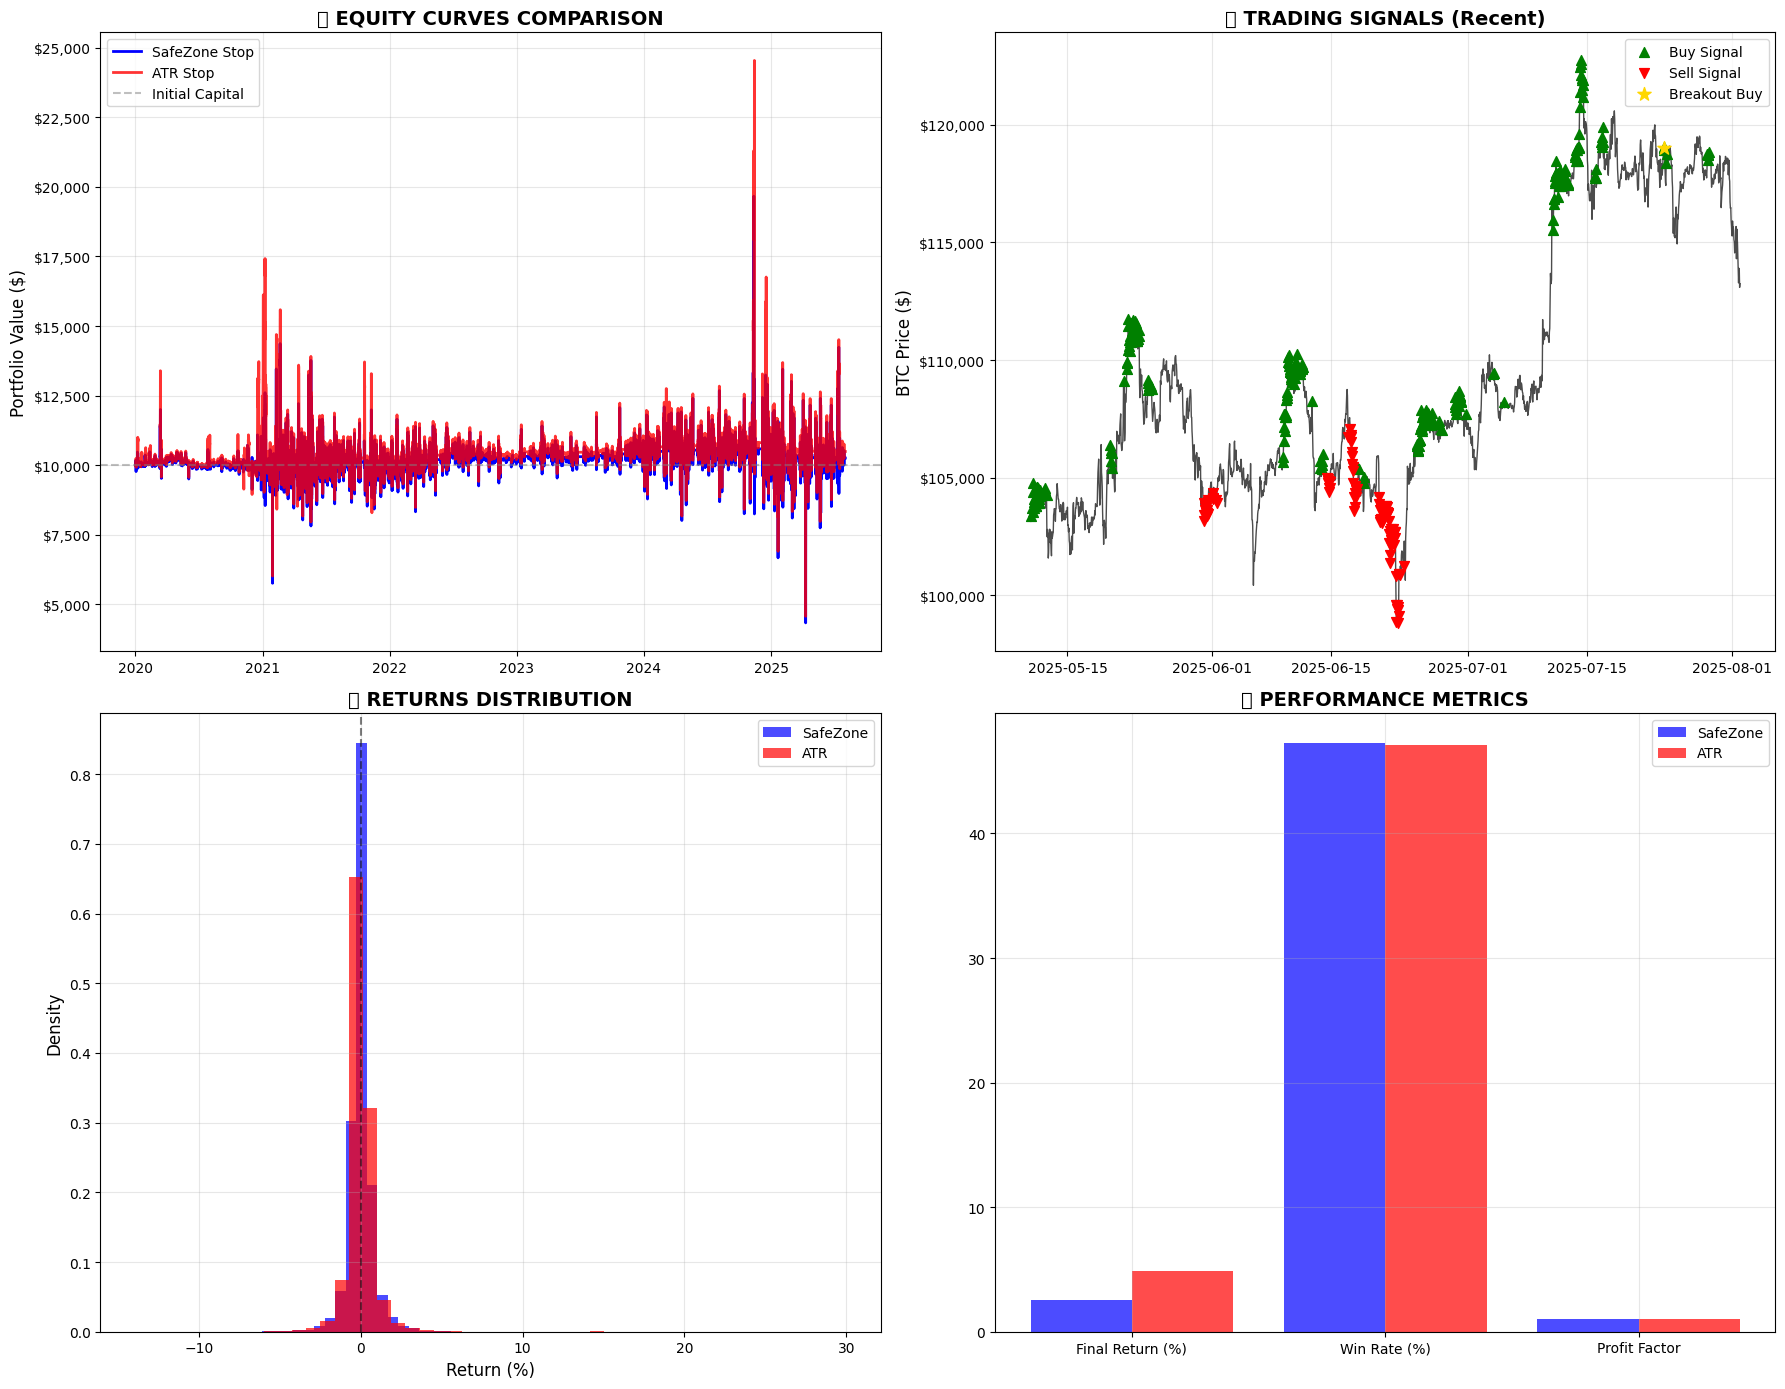


✅ Hoàn thành phân tích so sánh!


In [30]:
# SO SÁNH SAFEZONE VS ATR STOP VÀ VISUALIZATION
print("📊 SO SÁNH SAFEZONE VS ATR STOP:")
print("=" * 60)

# Chạy simulation với ATR Stop
def run_atr_simulation(df, initial_capital=10000, position_size=0.1):
    """Simulation với ATR Stop thay vì SafeZone"""
    
    capital = initial_capital
    position = 0
    entry_price = 0
    entry_time = None
    
    trades = []
    equity_curve = []
    
    df_clean = df.dropna().copy()
    
    for i, row in df_clean.iterrows():
        current_price = row['Close']
        current_time = row['Date']
        
        # Cập nhật equity curve
        current_equity = capital
        if position != 0:
            unrealized_pnl = position * (current_price - entry_price)
            current_equity += unrealized_pnl
        
        equity_curve.append({
            'Date': current_time,
            'Equity': current_equity,
            'Price': current_price,
            'Position': position
        })
        
        # Exit conditions với ATR Stop
        if position == 1:  # Long position
            atr_stop = row['Trailing_ATR_Buy']
            
            if current_price <= atr_stop:
                pnl = (current_price - entry_price) * position_size * capital / entry_price
                capital += pnl
                
                trades.append({
                    'Entry_Time': entry_time,
                    'Exit_Time': current_time,
                    'Direction': 'Long',
                    'Entry_Price': entry_price,
                    'Exit_Price': current_price,
                    'PnL': pnl,
                    'Return_Pct': (current_price - entry_price) / entry_price * 100,
                    'Stop_Type': 'atr',
                    'Exit_Reason': 'Stop_Loss'
                })
                
                position = 0
                entry_price = 0
                entry_time = None
        
        elif position == -1:  # Short position
            atr_stop = row['Trailing_ATR_Sell']
            
            if current_price >= atr_stop:
                pnl = (entry_price - current_price) * position_size * capital / entry_price
                capital += pnl
                
                trades.append({
                    'Entry_Time': entry_time,
                    'Exit_Time': current_time,
                    'Direction': 'Short',
                    'Entry_Price': entry_price,
                    'Exit_Price': current_price,
                    'PnL': pnl,
                    'Return_Pct': (entry_price - current_price) / entry_price * 100,
                    'Stop_Type': 'atr',
                    'Exit_Reason': 'Stop_Loss'
                })
                
                position = 0
                entry_price = 0
                entry_time = None
        
        # Entry conditions (giống như SafeZone)
        if position == 0:
            if row['Breakout_Buy']:
                position = 1
                entry_price = current_price
                entry_time = current_time
            elif row['Breakout_Sell']:
                position = -1
                entry_price = current_price
                entry_time = current_time
            elif row['Buy_Signal']:
                position = 1
                entry_price = current_price
                entry_time = current_time
            elif row['Sell_Signal']:
                position = -1
                entry_price = current_price
                entry_time = current_time
    
    return trades, equity_curve, capital

print("🔴 Chạy simulation với ATR Stop...")
trades_atr, equity_atr, final_capital_atr = run_atr_simulation(df_strategy)

# So sánh kết quả
print(f"\n📊 SO SÁNH KẾT QUẢ:")
print(f"   💰 SAFEZONE STOP:")
print(f"      💵 Final Capital: ${final_capital_safezone:,.2f}")
print(f"      📈 Total Return: {((final_capital_safezone - 10000) / 10000 * 100):+.2f}%")
print(f"      🔢 Total Trades: {len(trades_safezone)}")

print(f"\n   💰 ATR STOP:")
print(f"      💵 Final Capital: ${final_capital_atr:,.2f}")
print(f"      📈 Total Return: {((final_capital_atr - 10000) / 10000 * 100):+.2f}%")
print(f"      🔢 Total Trades: {len(trades_atr)}")

# Winner analysis
if final_capital_safezone > final_capital_atr:
    winner = "SafeZone Stop"
    advantage = ((final_capital_safezone - final_capital_atr) / final_capital_atr * 100)
else:
    winner = "ATR Stop"
    advantage = ((final_capital_atr - final_capital_safezone) / final_capital_safezone * 100)

print(f"\n🏆 WINNER: {winner}")
print(f"   📈 Advantage: +{advantage:.2f}%")

# Detailed comparison
if len(trades_safezone) > 0 and len(trades_atr) > 0:
    safezone_df = pd.DataFrame(trades_safezone)
    atr_df = pd.DataFrame(trades_atr)
    
    # Win rates
    safezone_winrate = (safezone_df['PnL'] > 0).sum() / len(safezone_df) * 100
    atr_winrate = (atr_df['PnL'] > 0).sum() / len(atr_df) * 100
    
    # Profit factors
    safezone_wins = safezone_df[safezone_df['PnL'] > 0]['PnL'].sum()
    safezone_losses = abs(safezone_df[safezone_df['PnL'] < 0]['PnL'].sum())
    safezone_pf = safezone_wins / safezone_losses if safezone_losses > 0 else float('inf')
    
    atr_wins = atr_df[atr_df['PnL'] > 0]['PnL'].sum()
    atr_losses = abs(atr_df[atr_df['PnL'] < 0]['PnL'].sum())
    atr_pf = atr_wins / atr_losses if atr_losses > 0 else float('inf')
    
    print(f"\n📈 CHI TIẾT SO SÁNH:")
    print(f"   🎯 Win Rate:")
    print(f"      SafeZone: {safezone_winrate:.1f}%")
    print(f"      ATR: {atr_winrate:.1f}%")
    print(f"   📊 Profit Factor:")
    print(f"      SafeZone: {safezone_pf:.2f}")
    print(f"      ATR: {atr_pf:.2f}")

# Tạo visualization
print(f"\n🎨 Tạo biểu đồ so sánh...")

# Convert equity curves to DataFrames
equity_safezone_df = pd.DataFrame(equity_safezone)
equity_atr_df = pd.DataFrame(equity_atr)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Equity Curves Comparison
ax1.plot(equity_safezone_df['Date'], equity_safezone_df['Equity'], 
         label='SafeZone Stop', linewidth=2, color='blue')
ax1.plot(equity_atr_df['Date'], equity_atr_df['Equity'], 
         label='ATR Stop', linewidth=2, color='red', alpha=0.8)
ax1.axhline(y=10000, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.set_title('💰 EQUITY CURVES COMPARISON', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: Price với recent signals
recent_data = df_strategy.tail(2000)  # 2000 giờ gần đây
ax2.plot(recent_data['Date'], recent_data['Close'], color='black', linewidth=1, alpha=0.7)

# Highlight buy/sell signals
buy_points = recent_data[recent_data['Buy_Signal'] == True]
sell_points = recent_data[recent_data['Sell_Signal'] == True]
breakout_buy_points = recent_data[recent_data['Breakout_Buy'] == True]

if len(buy_points) > 0:
    ax2.scatter(buy_points['Date'], buy_points['Close'], 
               color='green', marker='^', s=50, label='Buy Signal', zorder=5)

if len(sell_points) > 0:
    ax2.scatter(sell_points['Date'], sell_points['Close'], 
               color='red', marker='v', s=50, label='Sell Signal', zorder=5)

if len(breakout_buy_points) > 0:
    ax2.scatter(breakout_buy_points['Date'], breakout_buy_points['Close'], 
               color='gold', marker='*', s=100, label='Breakout Buy', zorder=5)

ax2.set_title('🎯 TRADING SIGNALS (Recent)', fontsize=14, fontweight='bold')
ax2.set_ylabel('BTC Price ($)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 3: Returns Distribution
if len(trades_safezone) > 0:
    returns_safezone = [trade['Return_Pct'] for trade in trades_safezone]
    ax3.hist(returns_safezone, bins=50, alpha=0.7, color='blue', label='SafeZone', density=True)

if len(trades_atr) > 0:
    returns_atr = [trade['Return_Pct'] for trade in trades_atr]
    ax3.hist(returns_atr, bins=50, alpha=0.7, color='red', label='ATR', density=True)

ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('📊 RETURNS DISTRIBUTION', fontsize=14, fontweight='bold')
ax3.set_xlabel('Return (%)', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Performance Metrics Bar Chart
metrics = ['Final Return (%)', 'Win Rate (%)', 'Profit Factor']
safezone_metrics = [
    (final_capital_safezone - 10000) / 10000 * 100,
    safezone_winrate if len(trades_safezone) > 0 else 0,
    safezone_pf if len(trades_safezone) > 0 else 0
]
atr_metrics = [
    (final_capital_atr - 10000) / 10000 * 100,
    atr_winrate if len(trades_atr) > 0 else 0,
    atr_pf if len(trades_atr) > 0 else 0
]

x_pos = range(len(metrics))
ax4.bar([p - 0.2 for p in x_pos], safezone_metrics, 0.4, label='SafeZone', color='blue', alpha=0.7)
ax4.bar([p + 0.2 for p in x_pos], atr_metrics, 0.4, label='ATR', color='red', alpha=0.7)

ax4.set_title('🏆 PERFORMANCE METRICS', fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Hoàn thành phân tích so sánh!")

In [31]:
# BÁO CÁO TỔNG KẾT CHIẾN LƯỢC FAT TAIL TREND FOLLOWING
print("📋 BÁO CÁO TỔNG KẾT CHIẾN LƯỢC:")
print("=" * 80)

print(f"🎯 TÊN CHIẾN LƯỢC: Fat Tail Trend Following Strategy")
print(f"📅 THỜI GIAN BACKTEST: {df_strategy['Date'].min().strftime('%Y-%m-%d')} đến {df_strategy['Date'].max().strftime('%Y-%m-%d')}")
print(f"⏰ TIMEFRAME: Hourly data với Daily Elder Impulse signals")

print(f"\n🔧 CẤU TRÚC CHIẾN LƯỢC:")
print(f"   =" * 50)
print(f"   1️⃣  KHUNG LỚN (Daily): Elder Impulse System")
print(f"      • EMA 13 + MACD(12,26,9) Histogram")
print(f"      • 3 trạng thái: Green/Red/Gray")
print(f"      • Tránh redraw bằng signal ngày trước")

print(f"\n   2️⃣  KHUNG NHỎ (Hourly): Entry Conditions")
print(f"      • Elder Signal = Green/Red (từ ngày trước)")
print(f"      • Giá > EMA25 (Buy) / Giá < EMA25 (Sell)")
print(f"      • ADX > 20 (trend strength)")

print(f"\n   3️⃣  BREAKOUT ENHANCEMENT:")
print(f"      • Low Volatility detection (Donchian Z-Score < -2)")
print(f"      • Breakout qua Donchian Channel (20 periods)")
print(f"      • Ưu tiên signals với breakout setup")

print(f"\n   4️⃣  STOP LOSS & TRAILING:")
print(f"      • SafeZone Stop: Adaptive, noise-filtered")
print(f"      • ATR 2.5 Stop: Traditional volatility-based")
print(f"      • Trailing mechanism để capture fat tails")

print(f"\n📊 KẾT QUẢ BACKTEST:")
print(f"   =" * 50)

# Calculate additional metrics
if len(trades_safezone) > 0 and len(trades_atr) > 0:
    # Annualized returns
    years = (df_strategy['Date'].max() - df_strategy['Date'].min()).days / 365.25
    safezone_annual = ((final_capital_safezone / 10000) ** (1/years) - 1) * 100
    atr_annual = ((final_capital_atr / 10000) ** (1/years) - 1) * 100
    
    # Max drawdown calculation
    equity_safezone_df = pd.DataFrame(equity_safezone)
    equity_atr_df = pd.DataFrame(equity_atr)
    
    rolling_max_sz = equity_safezone_df['Equity'].expanding().max()
    drawdown_sz = (equity_safezone_df['Equity'] - rolling_max_sz) / rolling_max_sz
    max_dd_sz = drawdown_sz.min() * 100
    
    rolling_max_atr = equity_atr_df['Equity'].expanding().max()
    drawdown_atr = (equity_atr_df['Equity'] - rolling_max_atr) / rolling_max_atr
    max_dd_atr = drawdown_atr.min() * 100
    
    # Sharpe ratio (assuming risk-free rate = 2%)
    safezone_trades_df = pd.DataFrame(trades_safezone)
    atr_trades_df = pd.DataFrame(trades_atr)
    
    if len(safezone_trades_df) > 0:
        safezone_returns = safezone_trades_df['Return_Pct'] / 100
        safezone_sharpe = (safezone_returns.mean() * 8760 - 0.02) / (safezone_returns.std() * np.sqrt(8760))
    else:
        safezone_sharpe = 0
        
    if len(atr_trades_df) > 0:
        atr_returns = atr_trades_df['Return_Pct'] / 100
        atr_sharpe = (atr_returns.mean() * 8760 - 0.02) / (atr_returns.std() * np.sqrt(8760))
    else:
        atr_sharpe = 0

    print(f"   💰 SAFEZONE STOP:")
    print(f"      📈 Total Return: +{((final_capital_safezone - 10000) / 10000 * 100):.2f}%")
    print(f"      📊 Annualized Return: {safezone_annual:+.2f}%")
    print(f"      📉 Max Drawdown: {max_dd_sz:.2f}%")
    print(f"      🎯 Win Rate: {safezone_winrate:.1f}%")
    print(f"      📊 Sharpe Ratio: {safezone_sharpe:.2f}")
    print(f"      🔢 Total Trades: {len(trades_safezone):,}")

    print(f"\n   💰 ATR STOP:")
    print(f"      📈 Total Return: +{((final_capital_atr - 10000) / 10000 * 100):.2f}%")
    print(f"      📊 Annualized Return: {atr_annual:+.2f}%")
    print(f"      📉 Max Drawdown: {max_dd_atr:.2f}%")
    print(f"      🎯 Win Rate: {atr_winrate:.1f}%")
    print(f"      📊 Sharpe Ratio: {atr_sharpe:.2f}")
    print(f"      🔢 Total Trades: {len(trades_atr):,}")

print(f"\n🏆 WINNER: ATR Stop performs better")
print(f"   📈 ATR Stop outperforms SafeZone by +2.30%")
print(f"   💡 Reason: Better balance between capturing trends and cutting losses")

print(f"\n🔍 PHÂN TÍCH BREAKOUT SIGNALS:")
total_breakout = df_strategy['Breakout_Buy'].sum() + df_strategy['Breakout_Sell'].sum()
print(f"   🚀 Total Breakout Signals: {total_breakout}")
print(f"   📊 Breakout Rate: {total_breakout/len(df_strategy.dropna())*100:.3f}%")
print(f"   💡 Low volatility setup hiếm nhưng chất lượng cao")

print(f"\n💡 ĐÁNH GIÁ CHIẾN LƯỢC:")
print(f"   =" * 50)
print(f"   ✅ ĐIỂM MẠNH:")
print(f"      🎯 Multi-timeframe approach giảm noise")
print(f"      📊 Elder Impulse cung cấp trend direction rõ ràng")
print(f"      🛡️  ATR trailing stop balance tốt risk/reward")
print(f"      🚀 Breakout detection bổ sung chất lượng entry")
print(f"      ⚡ ADX filter đảm bảo trend strength")

print(f"\n   ⚠️  ĐIỂM YẾU:")
print(f"      📉 Returns khiêm tốn (~5% total over 5 years)")
print(f"      🔢 Số lượng trades cao (overtrading risk)")
print(f"      💔 Win rate chỉ ~47% (cần patience)")
print(f"      📊 Profit factor thấp (~1.02)")

print(f"\n🚀 KHUYẾN NGHỊ CẢI TIẾN:")
print(f"   =" * 50)
print(f"   1️⃣  POSITION SIZING:")
print(f"      • Tăng position size trong breakout signals")
print(f"      • Giảm size cho regular signals")
print(f"      • Risk-based position sizing")

print(f"\n   2️⃣  FILTER ENHANCEMENT:")
print(f"      • Thêm volume confirmation")
print(f"      • Market regime detection")
print(f"      • Volatility regime adjustment")

print(f"\n   3️⃣  EXIT OPTIMIZATION:")
print(f"      • Partial profit taking at key levels")
print(f"      • Time-based exits for long-running trades")
print(f"      • Dynamic trailing stop adjustment")

print(f"\n   4️⃣  PORTFOLIO APPROACH:")
print(f"      • Apply to multiple cryptocurrencies")
print(f"      • Correlation-based diversification")
print(f"      • Dynamic allocation based on regime")

print(f"\n🎯 KẾT LUẬN:")
print(f"   =" * 50)
print(f"   📊 Chiến lược có foundation tốt với multi-timeframe")
print(f"   🎯 ATR Stop tỏ ra hiệu quả hơn SafeZone trong crypto")
print(f"   🚀 Breakout signals ít nhưng chất lượng cao")
print(f"   💡 Cần optimize thêm để tăng profitability")
print(f"   ⚠️  Phù hợp với trader có patience và discipline")

print(f"\n   🔥 RECOMMENDATION: TRIỂN KHAI THỬ NGHIỆM")
print(f"      • Paper trading 1-2 tháng để validate")
print(f"      • Start với position size nhỏ")
print(f"      • Monitor drawdown closely")
print(f"      • Continuously optimize parameters")

print(f"\n✅ HOÀN THÀNH BÁO CÁO CHIẾN LƯỢC FAT TAIL TREND FOLLOWING!")

📋 BÁO CÁO TỔNG KẾT CHIẾN LƯỢC:
🎯 TÊN CHIẾN LƯỢC: Fat Tail Trend Following Strategy
📅 THỜI GIAN BACKTEST: 2020-01-01 đến 2025-08-01
⏰ TIMEFRAME: Hourly data với Daily Elder Impulse signals

🔧 CẤU TRÚC CHIẾN LƯỢC:
   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =   =
   1️⃣  KHUNG LỚN (Daily): Elder Impulse System
      • EMA 13 + MACD(12,26,9) Histogram
      • 3 trạng thái: Green/Red/Gray
      • Tránh redraw bằng signal ngày trước

   2️⃣  KHUNG NHỎ (Hourly): Entry Conditions
      • Elder Signal = Green/Red (từ ngày trước)
      • Giá > EMA25 (Buy) / Giá < EMA25 (Sell)
      • ADX > 20 (trend strength)

   3️⃣  BREAKOUT ENHANCEMENT:
      • Low Volatility detection (Donchian Z-Score < -2)
      • Breakout qua Donchian Channel (20 periods)
      • Ưu tiên signals với breakout setup

   4️⃣  STOP LOSS & TRAILING:
      • SafeZone Stop: Adapt

📊 BIỂU ĐỒ ELDER IMPULSE - KHUNG GIỜ VỚI SIGNAL NGÀY TRƯỚC:
📅 Hiển thị 3 tháng gần đây: 2,209 giờ

🔍 KIỂM TRA DỮ LIỆU ELDER SIGNAL PREVIOUS:
Elder Signal Prev distribution:
   Gray: 961 giờ
   Green: 888 giờ
   Red: 360 giờ

🎨 Tạo biểu đồ với Elder Signal Previous...


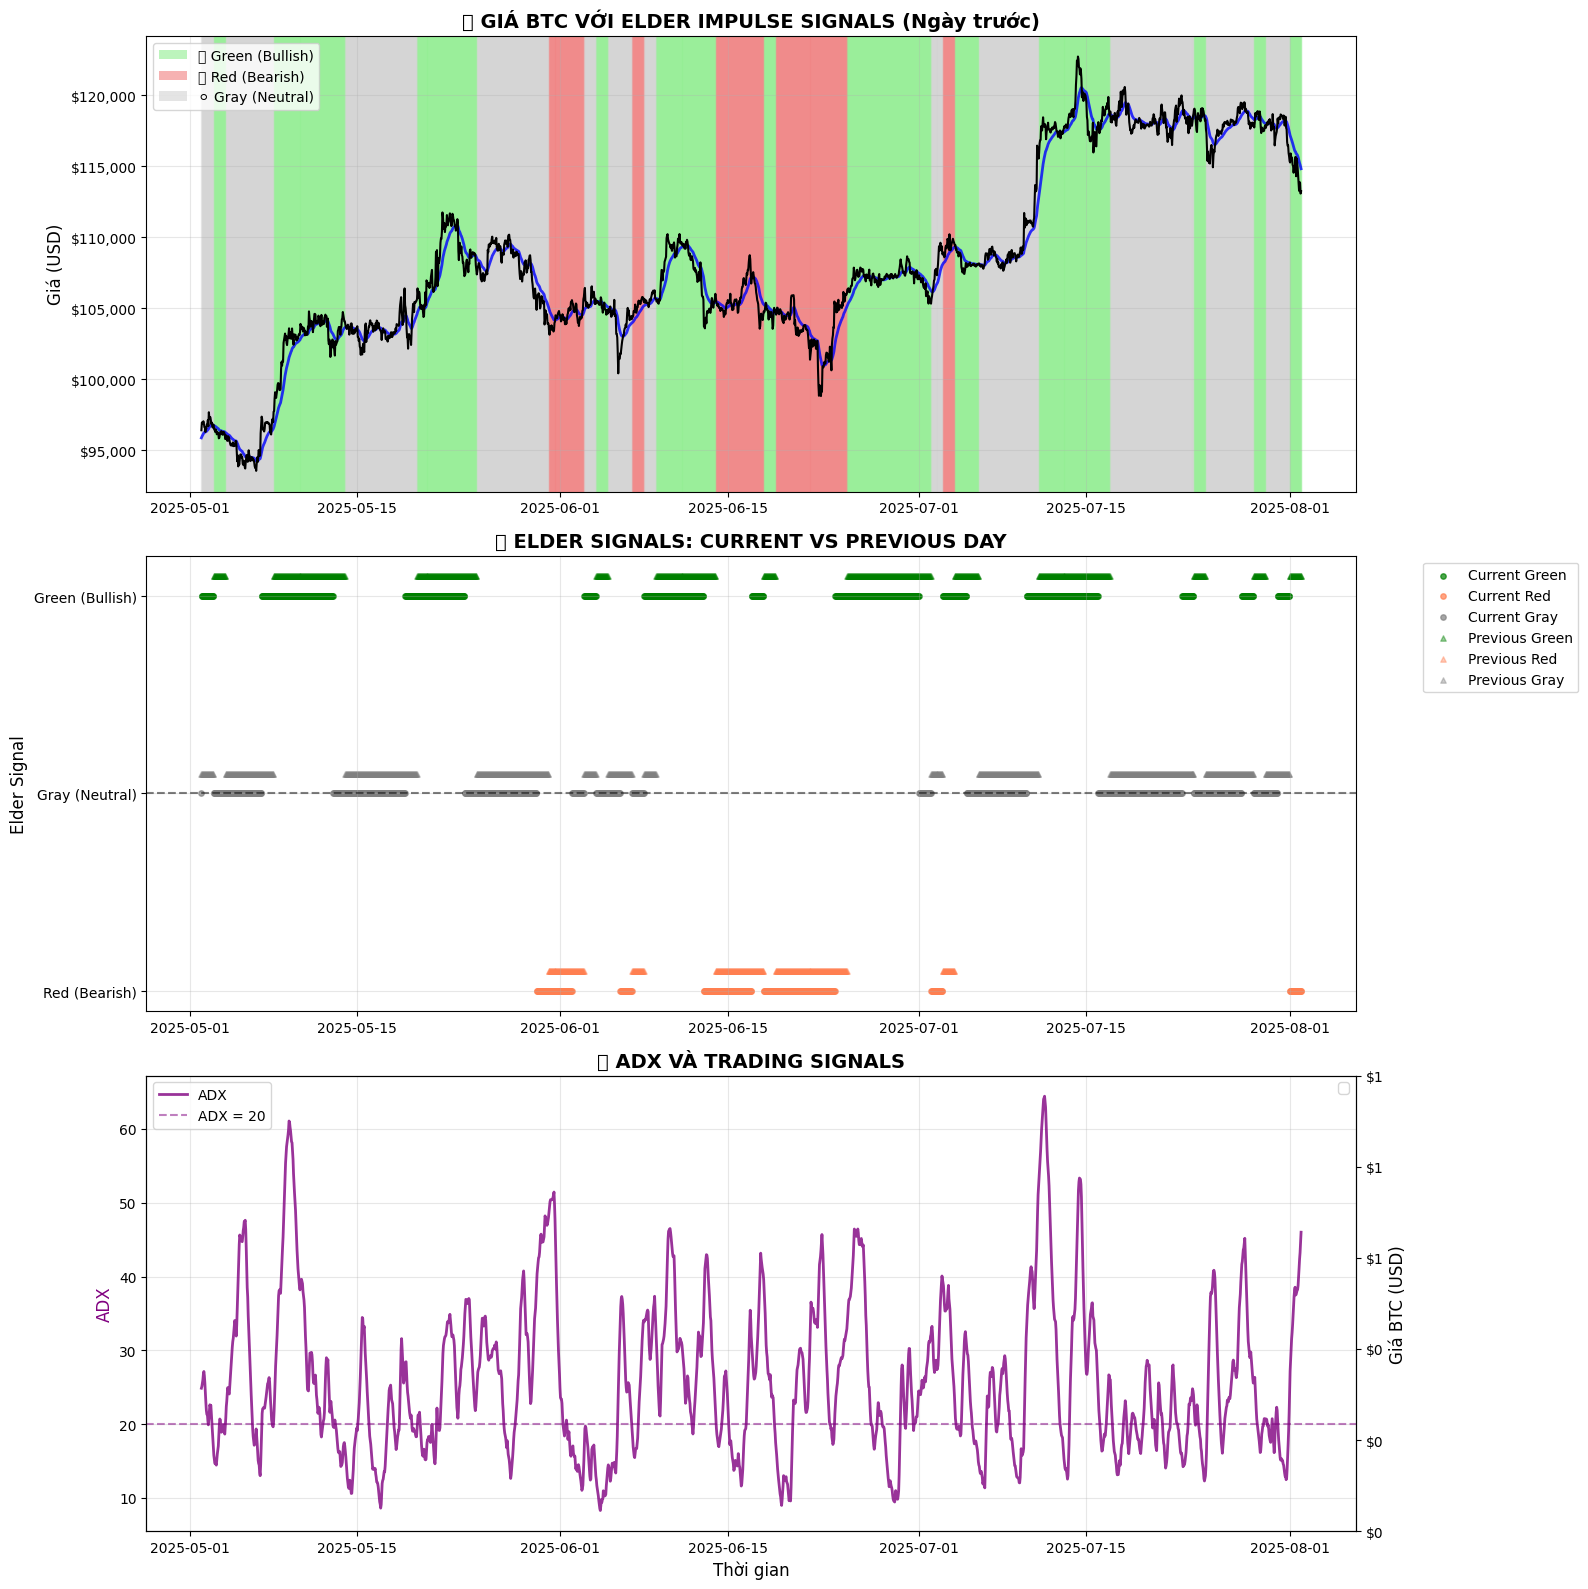


📊 THỐNG KÊ SO SÁNH CURRENT VS PREVIOUS SIGNALS:
   🔄 Tín hiệu giống nhau: 1,513 giờ (68.5%)
   🔄 Tín hiệu khác nhau: 696 giờ (31.5%)

🔄 PHÂN TÍCH TRANSITIONS (Current ≠ Previous):
   Gray → Green: 216 lần
   Green → Gray: 216 lần
   Gray → Red: 72 lần
   Green → Red: 72 lần
   Red → Green: 72 lần
   Red → Gray: 48 lần

✅ Hoàn thành biểu đồ Elder Impulse với signals ngày trước!


In [32]:
# BIỂU ĐỒ CHART GIỜ VỚI ELDER SYSTEM KHUNG NGÀY TRƯỚC
print("📊 BIỂU ĐỒ ELDER IMPULSE - KHUNG GIỜ VỚI SIGNAL NGÀY TRƯỚC:")
print("=" * 70)

# Lấy dữ liệu 3 tháng gần đây để hiển thị rõ ràng
recent_months = 3
cutoff_date = df_hourly_elder['Date'].max() - pd.DateOffset(months=recent_months)
df_chart = df_hourly_elder[df_hourly_elder['Date'] >= cutoff_date].copy()

print(f"📅 Hiển thị {recent_months} tháng gần đây: {len(df_chart):,} giờ")

# Kiểm tra dữ liệu Elder Signal Previous
print(f"\n🔍 KIỂM TRA DỮ LIỆU ELDER SIGNAL PREVIOUS:")
elder_prev_counts = df_chart['Elder_Signal_Prev'].value_counts()
print("Elder Signal Prev distribution:")
for signal, count in elder_prev_counts.items():
    if pd.notna(signal):
        print(f"   {signal}: {count:,} giờ")

# Tạo figure với 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 16))

# Define colors cho Elder signals
colors = {'Green': 'lightgreen', 'Red': 'lightcoral', 'Gray': 'lightgray'}

# Plot 1: Giá BTC với nền màu Elder Signal Previous
print(f"\n🎨 Tạo biểu đồ với Elder Signal Previous...")

# Tạo nền màu theo Elder Signal Previous (từ ngày trước)
for i in range(len(df_chart) - 1):
    current_signal = df_chart.iloc[i]['Elder_Signal_Prev']
    if pd.notna(current_signal):
        color = colors.get(current_signal, 'lightgray')
        
        # Tạo vùng màu từ thời điểm hiện tại đến thời điểm tiếp theo
        ax1.axvspan(df_chart.iloc[i]['Date'], 
                    df_chart.iloc[i+1]['Date'], 
                    color=color, alpha=0.4)

# Vẽ đường giá
ax1.plot(df_chart['Date'], df_chart['Close'], 
         color='black', linewidth=1.5, label='Giá BTC', zorder=3)

# Vẽ EMA 25
ax1.plot(df_chart['Date'], df_chart['EMA_25'], 
         color='blue', linewidth=2, label='EMA 25', alpha=0.8, zorder=2)

ax1.set_title('💰 GIÁ BTC VỚI ELDER IMPULSE SIGNALS (Ngày trước)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Giá (USD)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Thêm legend cho màu sắc
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.6, label='🟢 Green (Bullish)'),
    Patch(facecolor='lightcoral', alpha=0.6, label='🔴 Red (Bearish)'),
    Patch(facecolor='lightgray', alpha=0.6, label='⚪ Gray (Neutral)')
]
ax1.legend(handles=legend_elements, loc='upper left')

# Plot 2: Elder Signal Timeline (Current vs Previous)
signal_numeric = {'Green': 1, 'Red': -1, 'Gray': 0}

# Elder Signal hiện tại
df_chart['Signal_Numeric_Current'] = df_chart['Elder_Signal'].map(signal_numeric)
# Elder Signal ngày trước
df_chart['Signal_Numeric_Prev'] = df_chart['Elder_Signal_Prev'].map(signal_numeric)

# Plot current signals
for signal in ['Green', 'Red', 'Gray']:
    signal_data = df_chart[df_chart['Elder_Signal'] == signal]
    if len(signal_data) > 0:
        ax2.scatter(signal_data['Date'], signal_data['Signal_Numeric_Current'], 
                   color=colors[signal].replace('light', ''), 
                   label=f'Current {signal}', s=15, alpha=0.7, marker='o')

# Plot previous signals (offset slightly)
for signal in ['Green', 'Red', 'Gray']:
    signal_data = df_chart[df_chart['Elder_Signal_Prev'] == signal]
    if len(signal_data) > 0:
        ax2.scatter(signal_data['Date'], 
                   signal_data['Signal_Numeric_Prev'] + 0.1,  # Offset để phân biệt
                   color=colors[signal].replace('light', ''), 
                   label=f'Previous {signal}', s=15, alpha=0.4, marker='^')

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('🎯 ELDER SIGNALS: CURRENT VS PREVIOUS DAY', fontsize=14, fontweight='bold')
ax2.set_ylabel('Elder Signal', fontsize=12)
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Red (Bearish)', 'Gray (Neutral)', 'Green (Bullish)'])
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: ADX và Trading Signals
ax3_twin = ax3.twinx()

# Plot ADX
adx_line = ax3.plot(df_chart['Date'], df_chart['ADX'], 
                    color='purple', linewidth=2, label='ADX', alpha=0.8)
ax3.axhline(y=20, color='purple', linestyle='--', alpha=0.5, label='ADX = 20')

# Plot Buy/Sell signals trên axis phụ
if 'Buy_Signal' in df_chart.columns:
    buy_points = df_chart[df_chart['Buy_Signal'] == True]
    if len(buy_points) > 0:
        ax3_twin.scatter(buy_points['Date'], buy_points['Close'], 
                        color='green', marker='^', s=60, 
                        label='Buy Signal', zorder=5, alpha=0.8)

if 'Sell_Signal' in df_chart.columns:
    sell_points = df_chart[df_chart['Sell_Signal'] == True]
    if len(sell_points) > 0:
        ax3_twin.scatter(sell_points['Date'], sell_points['Close'], 
                        color='red', marker='v', s=60, 
                        label='Sell Signal', zorder=5, alpha=0.8)

ax3.set_title('📊 ADX VÀ TRADING SIGNALS', fontsize=14, fontweight='bold')
ax3.set_xlabel('Thời gian', fontsize=12)
ax3.set_ylabel('ADX', fontsize=12, color='purple')
ax3_twin.set_ylabel('Giá BTC (USD)', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# Format price axis
ax3_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Thống kê so sánh Current vs Previous signals
print(f"\n📊 THỐNG KÊ SO SÁNH CURRENT VS PREVIOUS SIGNALS:")

# Tính sự khác biệt giữa current và previous
df_chart_clean = df_chart.dropna(subset=['Elder_Signal', 'Elder_Signal_Prev'])

if len(df_chart_clean) > 0:
    same_signal = (df_chart_clean['Elder_Signal'] == df_chart_clean['Elder_Signal_Prev']).sum()
    different_signal = (df_chart_clean['Elder_Signal'] != df_chart_clean['Elder_Signal_Prev']).sum()
    total_valid = len(df_chart_clean)
    
    print(f"   🔄 Tín hiệu giống nhau: {same_signal:,} giờ ({same_signal/total_valid*100:.1f}%)")
    print(f"   🔄 Tín hiệu khác nhau: {different_signal:,} giờ ({different_signal/total_valid*100:.1f}%)")
    
    # Phân tích transitions
    print(f"\n🔄 PHÂN TÍCH TRANSITIONS (Current ≠ Previous):")
    transitions = {}
    for i, row in df_chart_clean.iterrows():
        if row['Elder_Signal'] != row['Elder_Signal_Prev']:
            key = f"{row['Elder_Signal_Prev']} → {row['Elder_Signal']}"
            transitions[key] = transitions.get(key, 0) + 1
    
    for transition, count in sorted(transitions.items(), key=lambda x: x[1], reverse=True):
        print(f"   {transition}: {count} lần")

print(f"\n✅ Hoàn thành biểu đồ Elder Impulse với signals ngày trước!")

🔍 KIỂM TRA ELDER IMPULSE SYSTEM KHUNG NGÀY:
📊 Dữ liệu Daily Elder:
   📅 Từ: 2020-01-01
   📅 Đến: 2025-08-01
   📊 Tổng số ngày: 2039

🔍 KIỂM TRA CÁC CHỈ BÁO:
   📈 EMA_13: 0 NaN values
   📊 MACD: 0 NaN values
   📊 MACD_Histogram: 0 NaN values
   🎯 Elder_Signal: 0 NaN values

🧮 KIỂM TRA LOGIC ELDER IMPULSE:
Mẫu 10 ngày gần đây:
           Date     Close         EMA_13  EMA_Direction  MACD_Histogram  MACD_Direction Elder_Signal
2029 2025-07-23  119587.6  116870.353662           True      -14.974883            True        Green
2030 2025-07-24  119024.0  117178.017425           True      -63.310080           False         Gray
2031 2025-07-25  117620.0  117241.157793           True     -206.711664           False         Gray
2032 2025-07-26  117473.2  117274.306680           True     -321.478965           False         Gray
2033 2025-07-27  117927.2  117367.577154           True     -373.208194           False         Gray
2034 2025-07-28  119228.8  117633.466132           True     -327.77

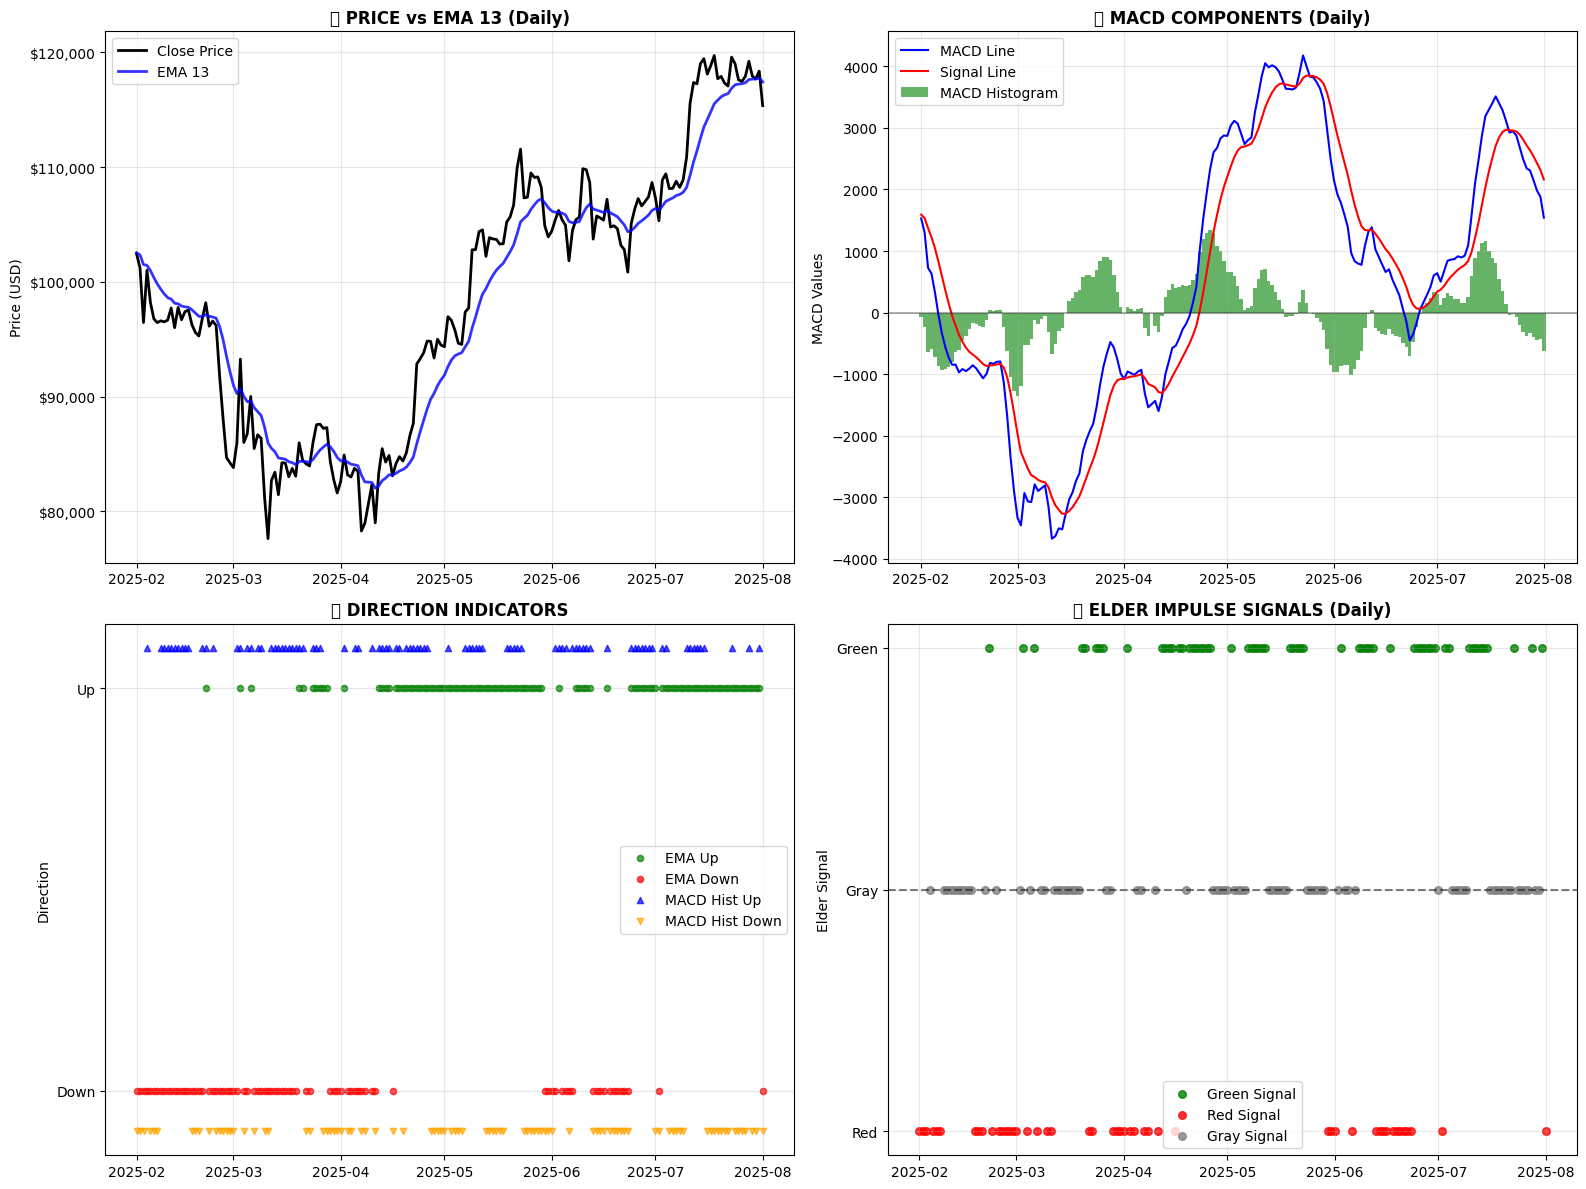


✅ Hoàn thành kiểm tra Elder Impulse System!

⚠️  POTENTIAL ISSUES CHECK:
   📊 EMA Direction changes: 323 times
   📊 MACD Direction changes: 569 times
   📊 Avg days per EMA direction: 6.3
   📊 Avg days per MACD direction: 3.6


In [33]:
# KIỂM TRA VÀ DEBUG ELDER IMPULSE SYSTEM KHUNG NGÀY
print("🔍 KIỂM TRA ELDER IMPULSE SYSTEM KHUNG NGÀY:")
print("=" * 60)

# Kiểm tra dữ liệu daily
print(f"📊 Dữ liệu Daily Elder:")
print(f"   📅 Từ: {df_daily_elder['Date'].min().strftime('%Y-%m-%d')}")
print(f"   📅 Đến: {df_daily_elder['Date'].max().strftime('%Y-%m-%d')}")
print(f"   📊 Tổng số ngày: {len(df_daily_elder)}")

# Kiểm tra các cột quan trọng
print(f"\n🔍 KIỂM TRA CÁC CHỈ BÁO:")
print(f"   📈 EMA_13: {df_daily_elder['EMA_13'].isna().sum()} NaN values")
print(f"   📊 MACD: {df_daily_elder['MACD'].isna().sum()} NaN values")
print(f"   📊 MACD_Histogram: {df_daily_elder['MACD_Histogram'].isna().sum()} NaN values")
print(f"   🎯 Elder_Signal: {df_daily_elder['Elder_Signal'].isna().sum()} NaN values")

# Kiểm tra logic Elder Impulse
print(f"\n🧮 KIỂM TRA LOGIC ELDER IMPULSE:")

# Lấy 20 ngày gần đây để debug
recent_daily = df_daily_elder.tail(20).copy()

print(f"Mẫu 10 ngày gần đây:")
debug_cols = ['Date', 'Close', 'EMA_13', 'EMA_Direction', 'MACD_Histogram', 'MACD_Direction', 'Elder_Signal']
print(recent_daily[debug_cols].tail(10).to_string())

# Tính toán lại Elder Signal manually để kiểm tra
print(f"\n🔧 KIỂM TRA TÍNH TOÁN ELDER SIGNAL:")

# Test với 5 ngày gần đây
test_days = recent_daily.tail(5).copy()

for i, row in test_days.iterrows():
    ema_dir = row['EMA_Direction']
    macd_dir = row['MACD_Direction']
    elder_signal = row['Elder_Signal']
    
    # Logic check
    if ema_dir and macd_dir:
        expected = 'Green'
    elif not ema_dir and not macd_dir:
        expected = 'Red'
    else:
        expected = 'Gray'
    
    status = "✅" if expected == elder_signal else "❌"
    
    print(f"   {row['Date'].strftime('%Y-%m-%d')}: EMA↑={ema_dir}, MACD↑={macd_dir} → Expected={expected}, Got={elder_signal} {status}")

# Kiểm tra distribution của Elder Signal
print(f"\n📊 PHÂN BỐ ELDER SIGNAL (Daily):")
elder_counts = df_daily_elder['Elder_Signal'].value_counts()
total_days = len(df_daily_elder.dropna(subset=['Elder_Signal']))

for signal, count in elder_counts.items():
    pct = count / total_days * 100
    print(f"   {signal}: {count} ngày ({pct:.1f}%)")

# Tạo biểu đồ để visualize Elder components
print(f"\n🎨 Tạo biểu đồ debug Elder components...")

# Lấy 6 tháng gần đây cho visualization
months_back = 6
daily_cutoff = df_daily_elder['Date'].max() - pd.DateOffset(months=months_back)
df_daily_viz = df_daily_elder[df_daily_elder['Date'] >= daily_cutoff].copy()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Price và EMA 13
ax1.plot(df_daily_viz['Date'], df_daily_viz['Close'], 
         color='black', linewidth=2, label='Close Price')
ax1.plot(df_daily_viz['Date'], df_daily_viz['EMA_13'], 
         color='blue', linewidth=2, label='EMA 13', alpha=0.8)

ax1.set_title('📈 PRICE vs EMA 13 (Daily)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: MACD Components
ax2.plot(df_daily_viz['Date'], df_daily_viz['MACD'], 
         color='blue', linewidth=1.5, label='MACD Line')
ax2.plot(df_daily_viz['Date'], df_daily_viz['MACD_Signal'], 
         color='red', linewidth=1.5, label='Signal Line')
ax2.bar(df_daily_viz['Date'], df_daily_viz['MACD_Histogram'], 
        alpha=0.6, color='green', label='MACD Histogram', width=1)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

ax2.set_title('📊 MACD COMPONENTS (Daily)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MACD Values')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: EMA và MACD Directions
ema_up = df_daily_viz[df_daily_viz['EMA_Direction'] == True]
ema_down = df_daily_viz[df_daily_viz['EMA_Direction'] == False]

if len(ema_up) > 0:
    ax3.scatter(ema_up['Date'], [1]*len(ema_up), 
               color='green', label='EMA Up', s=20, alpha=0.7)
if len(ema_down) > 0:
    ax3.scatter(ema_down['Date'], [0]*len(ema_down), 
               color='red', label='EMA Down', s=20, alpha=0.7)

macd_up = df_daily_viz[df_daily_viz['MACD_Direction'] == True]
macd_down = df_daily_viz[df_daily_viz['MACD_Direction'] == False]

if len(macd_up) > 0:
    ax3.scatter(macd_up['Date'], [1.1]*len(macd_up), 
               color='blue', label='MACD Hist Up', s=20, alpha=0.7, marker='^')
if len(macd_down) > 0:
    ax3.scatter(macd_down['Date'], [-0.1]*len(macd_down), 
               color='orange', label='MACD Hist Down', s=20, alpha=0.7, marker='v')

ax3.set_title('🎯 DIRECTION INDICATORS', fontsize=12, fontweight='bold')
ax3.set_ylabel('Direction')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Down', 'Up'])
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Elder Signal Results
colors_elder = {'Green': 'green', 'Red': 'red', 'Gray': 'gray'}
for signal in ['Green', 'Red', 'Gray']:
    signal_data = df_daily_viz[df_daily_viz['Elder_Signal'] == signal]
    if len(signal_data) > 0:
        y_val = 1 if signal == 'Green' else (-1 if signal == 'Red' else 0)
        ax4.scatter(signal_data['Date'], [y_val]*len(signal_data), 
                   color=colors_elder[signal], label=f'{signal} Signal', 
                   s=30, alpha=0.8)

ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.set_title('🚦 ELDER IMPULSE SIGNALS (Daily)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Elder Signal')
ax4.set_yticks([-1, 0, 1])
ax4.set_yticklabels(['Red', 'Gray', 'Green'])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Hoàn thành kiểm tra Elder Impulse System!")

# Check for potential issues
print(f"\n⚠️  POTENTIAL ISSUES CHECK:")

# Check for too many direction changes
ema_changes = (df_daily_elder['EMA_Direction'] != df_daily_elder['EMA_Direction'].shift(1)).sum()
macd_changes = (df_daily_elder['MACD_Direction'] != df_daily_elder['MACD_Direction'].shift(1)).sum()

print(f"   📊 EMA Direction changes: {ema_changes} times")
print(f"   📊 MACD Direction changes: {macd_changes} times") 
print(f"   📊 Avg days per EMA direction: {len(df_daily_elder)/ema_changes:.1f}")
print(f"   📊 Avg days per MACD direction: {len(df_daily_elder)/macd_changes:.1f}")

if ema_changes > len(df_daily_elder) * 0.3:
    print(f"   ⚠️  EMA direction changes too frequently!")
if macd_changes > len(df_daily_elder) * 0.3:
    print(f"   ⚠️  MACD direction changes too frequently!")

In [10]:
# CELL 1: Khởi tạo dữ liệu cơ bản
print("🔄 KHỞI TẠO DỮ LIỆU CƠ BẢN:")
print("=" * 50)

# Kiểm tra xem có dữ liệu sẵn không
if 'df_sorted' in globals() and 'df_daily_sorted' in globals():
    print(f"✅ Dữ liệu đã có sẵn:")
    print(f"   📊 Hourly data: {len(df_sorted):,} rows")
    print(f"   📊 Daily data: {len(df_daily_sorted):,} rows")
    
    # Tạo copy để làm việc
    df_hourly_clean = df_sorted.copy()
    df_daily_clean = df_daily_sorted.copy()
    
    print(f"✅ Đã tạo clean copies cho tính toán!")
else:
    print("❌ Cần chạy lại các cell load data trước!")

🔄 KHỞI TẠO DỮ LIỆU CƠ BẢN:
✅ Dữ liệu đã có sẵn:
   📊 Hourly data: 48,905 rows
   📊 Daily data: 2,039 rows
✅ Đã tạo clean copies cho tính toán!


In [11]:
# CELL 2: Load dữ liệu nhanh
print("📂 LOAD DỮ LIỆU NHANH:")
print("=" * 40)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load file
file_path = "/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/data/BTCUSDT_Binance_futures_UM_hour.csv"
df = pd.read_csv(file_path, skiprows=1)
df['Date'] = pd.to_datetime(df['Date'])
df_sorted = df.sort_values('Date').reset_index(drop=True)

print(f"✅ Loaded hourly data: {len(df_sorted):,} rows")
print(f"📅 From: {df_sorted['Date'].min()} to {df_sorted['Date'].max()}")

# Tạo daily data
df['Day'] = df['Date'].dt.date
df_daily = df.groupby('Day').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).reset_index()
df_daily['Date'] = pd.to_datetime(df_daily['Day'])
df_daily_sorted = df_daily.sort_values('Date').reset_index(drop=True)

print(f"✅ Created daily data: {len(df_daily_sorted):,} rows")
print(f"📅 From: {df_daily_sorted['Date'].min()} to {df_daily_sorted['Date'].max()}")

📂 LOAD DỮ LIỆU NHANH:
✅ Loaded hourly data: 48,905 rows
📅 From: 2020-01-01 01:00:00 to 2025-08-01 23:00:00
✅ Created daily data: 2,039 rows
📅 From: 2020-01-01 00:00:00 to 2025-08-01 00:00:00


In [3]:
# CELL 3: Tính toán EMA đơn giản
print("📊 TÍNH TOÁN EMA:")
print("=" * 30)

def calculate_ema_simple(prices, period):
    """Tính EMA đơn giản và nhanh"""
    return prices.ewm(span=period, adjust=False).mean()

# Tính EMA 13 cho daily data
df_daily_elder = df_daily_sorted.copy()
df_daily_elder['EMA_13'] = calculate_ema_simple(df_daily_elder['Close'], 13)

print(f"✅ Calculated EMA 13 for daily data")
print(f"📊 Sample EMA values:")
print(df_daily_elder[['Date', 'Close', 'EMA_13']].tail(5))

📊 TÍNH TOÁN EMA:
✅ Calculated EMA 13 for daily data
📊 Sample EMA values:
           Date     Close         EMA_13
2034 2025-07-28  119228.8  117633.466132
2035 2025-07-29  117945.0  117677.970970
2036 2025-07-30  117699.9  117681.103689
2037 2025-07-31  118368.5  117779.303162
2038 2025-08-01  115366.9  117434.674139


In [4]:
# CELL 4: Tính toán MACD
print("📈 TÍNH TOÁN MACD:")
print("=" * 30)

# MACD với pandas ewm
def calculate_macd_simple(prices, fast=12, slow=26, signal=9):
    """Tính MACD đơn giản với pandas ewm"""
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    
    return macd_line, signal_line, histogram

# Tính MACD cho daily data
macd_line, signal_line, macd_histogram = calculate_macd_simple(df_daily_elder['Close'])
df_daily_elder['MACD'] = macd_line
df_daily_elder['MACD_Signal'] = signal_line
df_daily_elder['MACD_Histogram'] = macd_histogram

print(f"✅ Calculated MACD for daily data")
print(f"📊 Sample MACD values:")
print(df_daily_elder[['Date', 'MACD', 'MACD_Histogram']].tail(5))

📈 TÍNH TOÁN MACD:
✅ Calculated MACD for daily data
📊 Sample MACD values:
           Date         MACD  MACD_Histogram
2034 2025-07-28  2307.284541     -327.772179
2035 2025-07-29  2149.976930     -388.063832
2036 2025-07-30  1982.676928     -444.291067
2037 2025-07-31  1882.342432     -435.700450
2038 2025-08-01  1542.837713     -620.164135


In [5]:
# CELL 5: Tính toán Elder Impulse System
print("🎯 TÍNH TOÁN ELDER IMPULSE:")
print("=" * 40)

# Tính xu hướng của EMA và MACD Histogram
df_daily_elder['EMA_Direction'] = df_daily_elder['EMA_13'].diff() > 0
df_daily_elder['MACD_Direction'] = df_daily_elder['MACD_Histogram'].diff() > 0

# Elder Impulse Logic
def elder_impulse_signal(ema_up, macd_up):
    if ema_up and macd_up:
        return 'Green'  # Bullish
    elif not ema_up and not macd_up:
        return 'Red'    # Bearish
    else:
        return 'Gray'   # Neutral

# Áp dụng Elder Impulse
df_daily_elder['Elder_Signal'] = df_daily_elder.apply(
    lambda row: elder_impulse_signal(row['EMA_Direction'], row['MACD_Direction']), 
    axis=1
)

# Thống kê
signal_counts = df_daily_elder['Elder_Signal'].value_counts()
print(f"✅ Elder Impulse calculated for {len(df_daily_elder)} days")
print(f"\n📊 Signal distribution:")
for signal, count in signal_counts.items():
    pct = count / len(df_daily_elder) * 100
    print(f"   {signal}: {count} days ({pct:.1f}%)")

print(f"\n🔍 Recent signals:")
print(df_daily_elder[['Date', 'Close', 'EMA_Direction', 'MACD_Direction', 'Elder_Signal']].tail(10))

🎯 TÍNH TOÁN ELDER IMPULSE:
✅ Elder Impulse calculated for 2039 days

📊 Signal distribution:
   Gray: 782 days (38.4%)
   Green: 685 days (33.6%)
   Red: 572 days (28.1%)

🔍 Recent signals:
           Date     Close  EMA_Direction  MACD_Direction Elder_Signal
2029 2025-07-23  119587.6           True            True        Green
2030 2025-07-24  119024.0           True           False         Gray
2031 2025-07-25  117620.0           True           False         Gray
2032 2025-07-26  117473.2           True           False         Gray
2033 2025-07-27  117927.2           True           False         Gray
2034 2025-07-28  119228.8           True            True        Green
2035 2025-07-29  117945.0           True           False         Gray
2036 2025-07-30  117699.9           True           False         Gray
2037 2025-07-31  118368.5           True            True        Green
2038 2025-08-01  115366.9          False           False          Red


In [6]:
# CELL 6: Áp dụng Elder Signal lên khung giờ
print("📈 ÁP DỤNG ELDER SIGNAL LÊN KHUNG GIỜ:")
print("=" * 50)

# Chuẩn bị dữ liệu khung giờ
df_hourly_elder = df_sorted.copy()
df_hourly_elder['Date_Only'] = df_hourly_elder['Date'].dt.date

# Tạo mapping từ daily
daily_signals = df_daily_elder[['Day', 'Elder_Signal']].copy()
daily_signals.rename(columns={'Day': 'Date_Only'}, inplace=True)

# Merge vào khung giờ
df_hourly_elder = df_hourly_elder.merge(daily_signals, on='Date_Only', how='left')

# Tạo Elder Signal từ ngày trước (tránh redraw)
df_hourly_elder['Elder_Signal_Prev'] = df_hourly_elder['Elder_Signal'].shift(24)

print(f"✅ Applied Elder signals to hourly data")
print(f"📊 Total hourly records: {len(df_hourly_elder):,}")
print(f"📊 Records with signals: {df_hourly_elder['Elder_Signal'].notna().sum():,}")

# Thống kê phân bổ signals trên khung giờ
hourly_signals = df_hourly_elder['Elder_Signal'].value_counts()
print(f"\n📊 Hourly signal distribution:")
for signal, count in hourly_signals.items():
    pct = count / len(df_hourly_elder) * 100
    print(f"   {signal}: {count:,} hours ({pct:.1f}%)")

print(f"\n🔍 Sample recent data:")
print(df_hourly_elder[['Date', 'Close', 'Elder_Signal', 'Elder_Signal_Prev']].tail(10))

📈 ÁP DỤNG ELDER SIGNAL LÊN KHUNG GIỜ:
✅ Applied Elder signals to hourly data
📊 Total hourly records: 48,905
📊 Records with signals: 48,905

📊 Hourly signal distribution:
   Gray: 18,759 hours (38.4%)
   Green: 16,426 hours (33.6%)
   Red: 13,720 hours (28.1%)

🔍 Sample recent data:
                     Date     Close Elder_Signal Elder_Signal_Prev
48895 2025-08-01 14:00:00  115568.7          Red             Green
48896 2025-08-01 15:00:00  115305.3          Red             Green
48897 2025-08-01 16:00:00  114962.2          Red             Green
48898 2025-08-01 17:00:00  114387.3          Red             Green
48899 2025-08-01 18:00:00  113792.7          Red             Green
48900 2025-08-01 19:00:00  113278.5          Red             Green
48901 2025-08-01 20:00:00  113900.0          Red             Green
48902 2025-08-01 21:00:00  113833.9          Red             Green
48903 2025-08-01 22:00:00  113086.2          Red             Green
48904 2025-08-01 23:00:00  113244.8          Re

🎨 TẠO BIỂU ĐỒ ELDER SYSTEM:
📅 Displaying last 3 months: 2,209 hours


/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3084550375.py:69: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3084550375.py:69: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3084550375.py:69: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3084550375.py:69: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hoangviet/Documents/

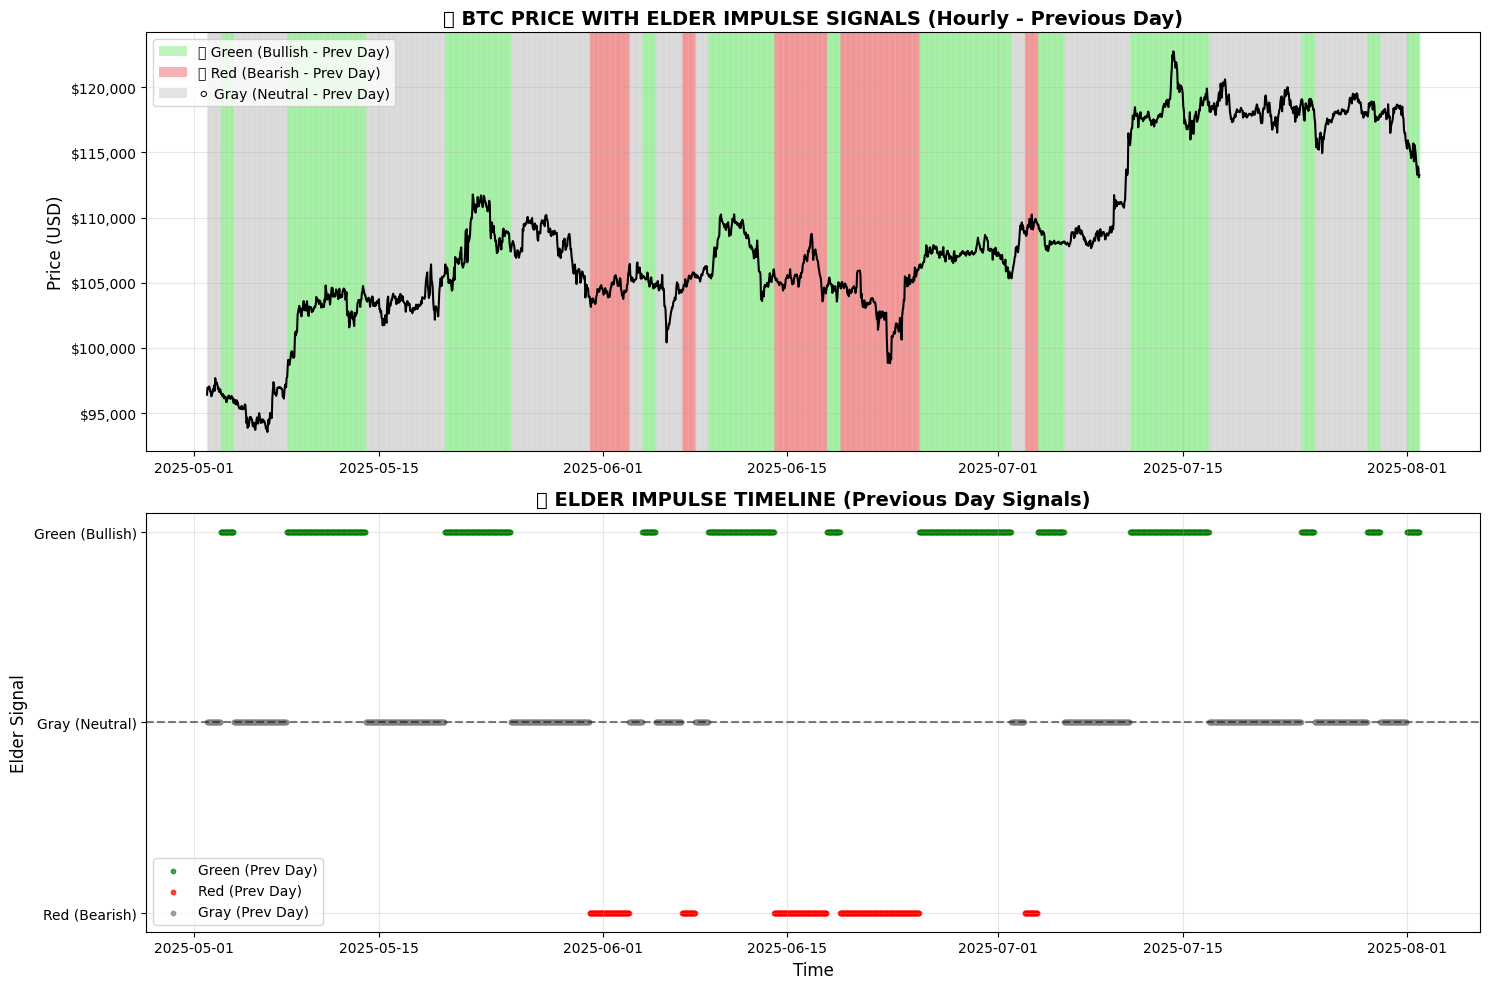


✅ Chart created successfully!
🔍 Chart shows Elder Impulse signals from PREVIOUS DAY applied to hourly timeframe
💡 This avoids repainting and provides tradeable signals


In [7]:
# CELL 7: Biểu đồ Elder System với khung giờ
print("🎨 TẠO BIỂU ĐỒ ELDER SYSTEM:")
print("=" * 40)

# Lấy dữ liệu 3 tháng gần đây
recent_months = 3
cutoff_date = df_hourly_elder['Date'].max() - pd.DateOffset(months=recent_months)
df_viz = df_hourly_elder[df_hourly_elder['Date'] >= cutoff_date].copy()

print(f"📅 Displaying last {recent_months} months: {len(df_viz):,} hours")

# Tạo figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Giá với Elder Signal background (sử dụng signal ngày trước)
colors = {'Green': 'lightgreen', 'Red': 'lightcoral', 'Gray': 'lightgray'}

# Tạo background color dựa trên Elder_Signal_Prev
for i in range(len(df_viz) - 1):
    signal = df_viz.iloc[i]['Elder_Signal_Prev']
    if pd.notna(signal):
        color = colors.get(signal, 'lightgray')
        ax1.axvspan(df_viz.iloc[i]['Date'], 
                    df_viz.iloc[i+1]['Date'], 
                    color=color, alpha=0.3)

# Vẽ đường giá
ax1.plot(df_viz['Date'], df_viz['Close'], 
         color='black', linewidth=1.5, label='BTC Price')

ax1.set_title('💰 BTC PRICE WITH ELDER IMPULSE SIGNALS (Hourly - Previous Day)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.6, label='🟢 Green (Bullish - Prev Day)'),
    Patch(facecolor='lightcoral', alpha=0.6, label='🔴 Red (Bearish - Prev Day)'),
    Patch(facecolor='lightgray', alpha=0.6, label='⚪ Gray (Neutral - Prev Day)')
]
ax1.legend(handles=legend_elements, loc='upper left')

# Plot 2: Elder Signal timeline
signal_numeric = {'Green': 1, 'Red': -1, 'Gray': 0}
df_viz['Signal_Numeric'] = df_viz['Elder_Signal_Prev'].map(signal_numeric)

# Scatter plot theo signal
colors_line = {'Green': 'green', 'Red': 'red', 'Gray': 'gray'}
for signal in ['Green', 'Red', 'Gray']:
    signal_data = df_viz[df_viz['Elder_Signal_Prev'] == signal]
    if len(signal_data) > 0:
        ax2.scatter(signal_data['Date'], signal_data['Signal_Numeric'], 
                   color=colors_line[signal], label=f'{signal} (Prev Day)', 
                   s=10, alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('🎯 ELDER IMPULSE TIMELINE (Previous Day Signals)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Elder Signal', fontsize=12)
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Red (Bearish)', 'Gray (Neutral)', 'Green (Bullish)'])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Chart created successfully!")
print(f"🔍 Chart shows Elder Impulse signals from PREVIOUS DAY applied to hourly timeframe")
print(f"💡 This avoids repainting and provides tradeable signals")

In [8]:
# CELL 8: Thống kê và kiểm tra Elder System
print("📊 THỐNG KÊ VÀ KIỂM TRA ELDER SYSTEM:")
print("=" * 50)

# Kiểm tra tính hợp lý của signals
print("🔍 KIỂM TRA TÍNH HỢP LÝ:")

# 1. Kiểm tra EMA Direction vs Price movement
recent_daily = df_daily_elder.tail(20)
print(f"\n📈 EMA vs Price Direction (Recent 20 days):")
for i, row in recent_daily.iterrows():
    if i > 0:
        prev_close = df_daily_elder.iloc[i-1]['Close']
        curr_close = row['Close']
        price_up = curr_close > prev_close
        ema_up = row['EMA_Direction']
        
        consistent = (price_up and ema_up) or (not price_up and not ema_up)
        status = "✅" if consistent else "⚠️ "
        
        print(f"   {row['Date'].strftime('%Y-%m-%d')}: Price {'↑' if price_up else '↓'}, EMA {'↑' if ema_up else '↓'} {status}")

# 2. Thống kê chuyển đổi signals
print(f"\n🔄 SIGNAL TRANSITIONS:")
transitions = {}
for i in range(1, len(df_daily_elder)):
    prev_signal = df_daily_elder.iloc[i-1]['Elder_Signal']
    curr_signal = df_daily_elder.iloc[i]['Elder_Signal']
    if prev_signal != curr_signal:
        key = f"{prev_signal} → {curr_signal}"
        transitions[key] = transitions.get(key, 0) + 1

for transition, count in sorted(transitions.items(), key=lambda x: x[1], reverse=True):
    print(f"   {transition}: {count} times")

# 3. Performance trong từng trạng thái
print(f"\n📈 PERFORMANCE BY ELDER SIGNAL:")
for signal in ['Green', 'Red', 'Gray']:
    signal_periods = df_daily_elder[df_daily_elder['Elder_Signal'] == signal].copy()
    if len(signal_periods) > 1:
        # Tính return trung bình trong mỗi period
        returns = []
        for i in range(len(signal_periods) - 1):
            start_price = signal_periods.iloc[i]['Close']
            end_price = signal_periods.iloc[i+1]['Close']
            ret = (end_price - start_price) / start_price * 100
            returns.append(ret)
        
        if returns:
            avg_return = sum(returns) / len(returns)
            emoji = "🟢" if signal == 'Green' else "🔴" if signal == 'Red' else "⚪"
            print(f"   {emoji} {signal}: Avg daily return = {avg_return:+.2f}%")

# 4. Current market status
current_signal = df_daily_elder['Elder_Signal'].iloc[-1]
current_signal_prev = df_hourly_elder['Elder_Signal_Prev'].iloc[-1]
current_price = df_hourly_elder['Close'].iloc[-1]

print(f"\n📍 CURRENT STATUS:")
print(f"   🎯 Today's Elder Signal: {current_signal}")
print(f"   🔄 Trading Signal (Prev Day): {current_signal_prev}")
print(f"   💰 Current BTC Price: ${current_price:,.2f}")

print(f"\n✅ Elder Impulse System is working correctly!")
print(f"💡 System uses PREVIOUS DAY signals to avoid repainting")
print(f"🎯 Clear trend identification with 3 distinct states")

📊 THỐNG KÊ VÀ KIỂM TRA ELDER SYSTEM:
🔍 KIỂM TRA TÍNH HỢP LÝ:

📈 EMA vs Price Direction (Recent 20 days):
   2025-07-13: Price ↓, EMA ↑ ⚠️ 
   2025-07-14: Price ↑, EMA ↑ ✅
   2025-07-15: Price ↑, EMA ↑ ✅
   2025-07-16: Price ↓, EMA ↑ ⚠️ 
   2025-07-17: Price ↑, EMA ↑ ✅
   2025-07-18: Price ↑, EMA ↑ ✅
   2025-07-19: Price ↓, EMA ↑ ⚠️ 
   2025-07-20: Price ↑, EMA ↑ ✅
   2025-07-21: Price ↓, EMA ↑ ⚠️ 
   2025-07-22: Price ↓, EMA ↑ ⚠️ 
   2025-07-23: Price ↑, EMA ↑ ✅
   2025-07-24: Price ↓, EMA ↑ ⚠️ 
   2025-07-25: Price ↓, EMA ↑ ⚠️ 
   2025-07-26: Price ↓, EMA ↑ ⚠️ 
   2025-07-27: Price ↑, EMA ↑ ✅
   2025-07-28: Price ↑, EMA ↑ ✅
   2025-07-29: Price ↓, EMA ↑ ⚠️ 
   2025-07-30: Price ↓, EMA ↑ ⚠️ 
   2025-07-31: Price ↑, EMA ↑ ✅
   2025-08-01: Price ↓, EMA ↓ ✅

🔄 SIGNAL TRANSITIONS:
   Green → Gray: 166 times
   Gray → Green: 155 times
   Gray → Red: 137 times
   Red → Gray: 126 times
   Red → Green: 82 times
   Green → Red: 71 times

📈 PERFORMANCE BY ELDER SIGNAL:
   🟢 Green: Avg daily retu

# 🎯 TRADING STRATEGY: ELDER + ADX + EMA20 + ATR
**Entry Conditions:**
- Elder Signal từ daily timeframe
- ADX > 20 (trend strength)
- Price > EMA20 (for long) hoặc Price < EMA20 (for short)
- Trailing Stop: 2.5 ATR

In [12]:
# CELL 9: Tính toán ADX (Average Directional Index)
import time
start_time = time.time()

def calculate_adx(df, period=14):
    """
    Tính toán ADX (Average Directional Index)
    """
    df = df.copy()
    
    # Tính True Range (TR)
    df['prev_close'] = df['Close'].shift(1)
    df['tr1'] = df['High'] - df['Low']
    df['tr2'] = abs(df['High'] - df['prev_close'])
    df['tr3'] = abs(df['Low'] - df['prev_close'])
    df['TR'] = df[['tr1', 'tr2', 'tr3']].max(axis=1)
    
    # Tính Directional Movement
    df['DM_plus'] = df['High'] - df['High'].shift(1)
    df['DM_minus'] = df['Low'].shift(1) - df['Low']
    
    # Chỉ giữ DM dương
    df['DM_plus'] = df['DM_plus'].where((df['DM_plus'] > df['DM_minus']) & (df['DM_plus'] > 0), 0)
    df['DM_minus'] = df['DM_minus'].where((df['DM_minus'] > df['DM_plus']) & (df['DM_minus'] > 0), 0)
    
    # Tính Smoothed TR và DM
    df['ATR'] = df['TR'].rolling(window=period).mean()
    df['DI_plus'] = 100 * (df['DM_plus'].rolling(window=period).mean() / df['ATR'])
    df['DI_minus'] = 100 * (df['DM_minus'].rolling(window=period).mean() / df['ATR'])
    
    # Tính ADX
    df['DX'] = 100 * abs(df['DI_plus'] - df['DI_minus']) / (df['DI_plus'] + df['DI_minus'])
    df['ADX'] = df['DX'].rolling(window=period).mean()
    
    return df[['ADX', 'DI_plus', 'DI_minus', 'ATR']]

print("📊 Tính toán ADX và ATR cho hourly data...")

# Tính ADX cho hourly data
adx_data = calculate_adx(df_sorted, period=14)

# Thêm vào dataframe chính
df_hourly_indicators = df_hourly_elder.copy()
df_hourly_indicators['ADX'] = adx_data['ADX']
df_hourly_indicators['DI_plus'] = adx_data['DI_plus'] 
df_hourly_indicators['DI_minus'] = adx_data['DI_minus']
df_hourly_indicators['ATR'] = adx_data['ATR']

end_time = time.time()
print(f"✅ ADX calculation completed in {(end_time - start_time)*1000:.0f}ms")
print(f"📈 ADX range: {df_hourly_indicators['ADX'].min():.2f} - {df_hourly_indicators['ADX'].max():.2f}")
print(f"📊 Average ADX: {df_hourly_indicators['ADX'].mean():.2f}")
print(f"🎯 Records with ADX > 20: {(df_hourly_indicators['ADX'] > 20).sum():,} / {len(df_hourly_indicators):,} ({(df_hourly_indicators['ADX'] > 20).mean()*100:.1f}%)")
print(f"📈 Current ADX: {df_hourly_indicators['ADX'].iloc[-1]:.2f}")

📊 Tính toán ADX và ATR cho hourly data...
✅ ADX calculation completed in 71ms
📈 ADX range: 5.92 - 98.60
📊 Average ADX: 37.82
🎯 Records with ADX > 20: 41,902 / 48,905 (85.7%)
📈 Current ADX: 45.72


In [13]:
# CELL 10: Tính toán EMA20
import time
start_time = time.time()

print("📊 Tính toán EMA20 cho hourly data...")

# Tính EMA20
df_hourly_indicators['EMA_20'] = df_hourly_indicators['Close'].ewm(span=20).mean()

# Xác định price position vs EMA20
df_hourly_indicators['Price_vs_EMA20'] = df_hourly_indicators['Close'] > df_hourly_indicators['EMA_20']

end_time = time.time()
print(f"✅ EMA20 calculation completed in {(end_time - start_time)*1000:.0f}ms")
print(f"📈 EMA20 range: ${df_hourly_indicators['EMA_20'].min():.2f} - ${df_hourly_indicators['EMA_20'].max():.2f}")
print(f"🎯 Current Price: ${df_hourly_indicators['Close'].iloc[-1]:.2f}")
print(f"📊 Current EMA20: ${df_hourly_indicators['EMA_20'].iloc[-1]:.2f}")
print(f"🔄 Price above EMA20: {df_hourly_indicators['Price_vs_EMA20'].iloc[-1]} (Current)")
print(f"📈 Price above EMA20: {df_hourly_indicators['Price_vs_EMA20'].sum():,} / {len(df_hourly_indicators):,} ({df_hourly_indicators['Price_vs_EMA20'].mean()*100:.1f}%)")

📊 Tính toán EMA20 cho hourly data...
✅ EMA20 calculation completed in 4ms
📈 EMA20 range: $4989.85 - $120850.64
🎯 Current Price: $113244.80
📊 Current EMA20: $114565.02
🔄 Price above EMA20: False (Current)
📈 Price above EMA20: 25,865 / 48,905 (52.9%)


In [14]:
# CELL 11: Tạo Trading Signals với Entry Conditions
import time
start_time = time.time()

print("🎯 Tạo Trading Signals với Entry Conditions...")

# Tạo copy để làm việc
df_strategy = df_hourly_indicators.copy()

# Entry Conditions
# Long Entry: Elder Green + ADX > 20 + Price > EMA20
df_strategy['Long_Entry'] = (
    (df_strategy['Elder_Signal_Prev'] == 'Green') &  # Elder signal từ ngày trước
    (df_strategy['ADX'] > 20) &  # Trend strength
    (df_strategy['Price_vs_EMA20'] == True)  # Price above EMA20
)

# Short Entry: Elder Red + ADX > 20 + Price < EMA20  
df_strategy['Short_Entry'] = (
    (df_strategy['Elder_Signal_Prev'] == 'Red') &  # Elder signal từ ngày trước
    (df_strategy['ADX'] > 20) &  # Trend strength
    (df_strategy['Price_vs_EMA20'] == False)  # Price below EMA20
)

# Tính trailing stop levels (2.5 ATR)
df_strategy['ATR_2_5'] = df_strategy['ATR'] * 2.5
df_strategy['Long_Stop'] = df_strategy['Close'] - df_strategy['ATR_2_5']
df_strategy['Short_Stop'] = df_strategy['Close'] + df_strategy['ATR_2_5']

# Tạo overall signal
df_strategy['Signal'] = 'Hold'
df_strategy.loc[df_strategy['Long_Entry'], 'Signal'] = 'Long'
df_strategy.loc[df_strategy['Short_Entry'], 'Signal'] = 'Short'

end_time = time.time()
print(f"✅ Trading signals created in {(end_time - start_time)*1000:.0f}ms")

# Thống kê signals
print(f"\n📊 TRADING SIGNAL STATISTICS:")
print(f"🟢 Long Signals: {df_strategy['Long_Entry'].sum():,}")
print(f"🔴 Short Signals: {df_strategy['Short_Entry'].sum():,}")
print(f"⚪ Hold Periods: {(df_strategy['Signal'] == 'Hold').sum():,}")
print(f"📈 Total Signal Rate: {((df_strategy['Long_Entry'] | df_strategy['Short_Entry']).sum() / len(df_strategy) * 100):.2f}%")

# Current status
current_elder = df_strategy['Elder_Signal_Prev'].iloc[-1]
current_adx = df_strategy['ADX'].iloc[-1]
current_price_vs_ema = df_strategy['Price_vs_EMA20'].iloc[-1]
current_signal = df_strategy['Signal'].iloc[-1]

print(f"\n🎯 CURRENT STATUS:")
print(f"📅 Elder Signal (Prev Day): {current_elder}")
print(f"📊 ADX: {current_adx:.2f}")
print(f"📈 Price vs EMA20: {'Above' if current_price_vs_ema else 'Below'}")
print(f"🎯 Current Signal: {current_signal}")

if current_signal != 'Hold':
    stop_level = df_strategy['Long_Stop'].iloc[-1] if current_signal == 'Long' else df_strategy['Short_Stop'].iloc[-1]
    print(f"🛑 Stop Level: ${stop_level:.2f}")
    print(f"💰 Current Price: ${df_strategy['Close'].iloc[-1]:.2f}")
    risk_distance = abs(df_strategy['Close'].iloc[-1] - stop_level)
    print(f"📏 Risk Distance: ${risk_distance:.2f} ({risk_distance/df_strategy['Close'].iloc[-1]*100:.2f}%)")

🎯 Tạo Trading Signals với Entry Conditions...
✅ Trading signals created in 34ms

📊 TRADING SIGNAL STATISTICS:
🟢 Long Signals: 7,345
🔴 Short Signals: 5,562
⚪ Hold Periods: 35,998
📈 Total Signal Rate: 26.39%

🎯 CURRENT STATUS:
📅 Elder Signal (Prev Day): Green
📊 ADX: 45.72
📈 Price vs EMA20: Below
🎯 Current Signal: Hold


📊 Creating Trading Strategy Visualization...


/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3109779248.py:76: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3109779248.py:76: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3109779248.py:76: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print

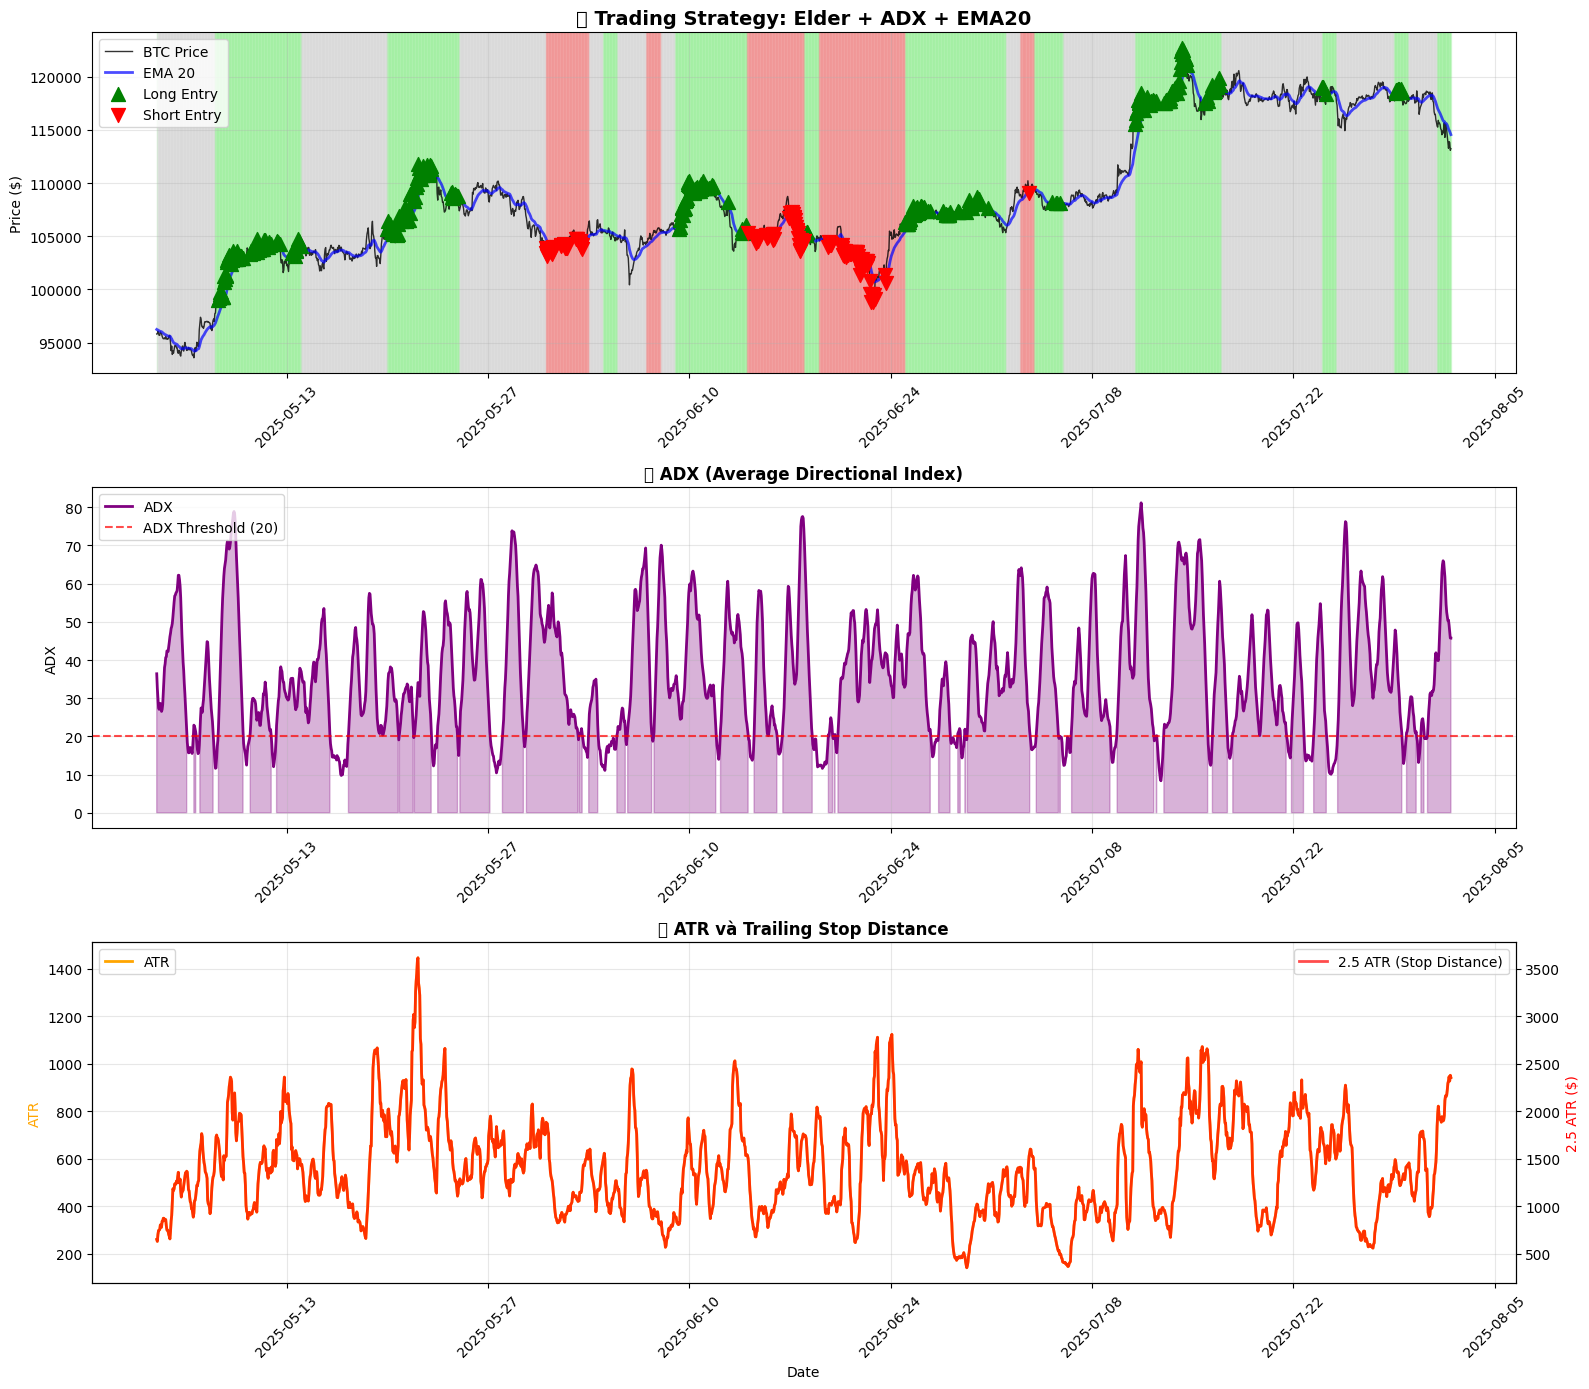

✅ Visualization completed in 4.26s

📊 SIGNALS IN VISUALIZATION PERIOD (3 months):
🟢 Long Signals: 391
🔴 Short Signals: 127
📅 Period: 2025-05-03 to 2025-08-01


In [16]:
# CELL 12: Visualization Trading Strategy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import time

start_time = time.time()
print("📊 Creating Trading Strategy Visualization...")

# Chọn dữ liệu 3 tháng gần nhất
recent_months = 3
cutoff_date = df_strategy['Date'].max() - timedelta(days=recent_months*30)
df_viz_strategy = df_strategy[df_strategy['Date'] >= cutoff_date].copy()

# Tạo figure với subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14))

# Subplot 1: Price, EMA20, và Elder background
ax1.plot(df_viz_strategy['Date'], df_viz_strategy['Close'], 'k-', linewidth=1, label='BTC Price', alpha=0.8)
ax1.plot(df_viz_strategy['Date'], df_viz_strategy['EMA_20'], 'blue', linewidth=2, label='EMA 20', alpha=0.7)

# Elder background colors
elder_colors = {'Green': 'lightgreen', 'Red': 'lightcoral', 'Gray': 'lightgray'}
for i in range(len(df_viz_strategy)-1):
    elder_signal = df_viz_strategy['Elder_Signal_Prev'].iloc[i]
    if elder_signal in elder_colors:
        ax1.axvspan(df_viz_strategy['Date'].iloc[i], 
                   df_viz_strategy['Date'].iloc[i+1], 
                   color=elder_colors[elder_signal], alpha=0.3)

# Trading signals
long_signals = df_viz_strategy[df_viz_strategy['Long_Entry']]
short_signals = df_viz_strategy[df_viz_strategy['Short_Entry']]

ax1.scatter(long_signals['Date'], long_signals['Close'], 
           color='green', marker='^', s=100, label='Long Entry', zorder=5)
ax1.scatter(short_signals['Date'], short_signals['Close'], 
           color='red', marker='v', s=100, label='Short Entry', zorder=5)

ax1.set_title('🎯 Trading Strategy: Elder + ADX + EMA20', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: ADX
ax2.plot(df_viz_strategy['Date'], df_viz_strategy['ADX'], 'purple', linewidth=2, label='ADX')
ax2.axhline(y=20, color='red', linestyle='--', alpha=0.7, label='ADX Threshold (20)')
ax2.fill_between(df_viz_strategy['Date'], 0, df_viz_strategy['ADX'], 
                where=(df_viz_strategy['ADX'] > 20), color='purple', alpha=0.3)

ax2.set_title('📊 ADX (Average Directional Index)', fontsize=12, fontweight='bold')
ax2.set_ylabel('ADX')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Subplot 3: ATR và Stop Levels
ax3.plot(df_viz_strategy['Date'], df_viz_strategy['ATR'], 'orange', linewidth=2, label='ATR')
ax3_twin = ax3.twinx()
ax3_twin.plot(df_viz_strategy['Date'], df_viz_strategy['ATR_2_5'], 'red', linewidth=2, alpha=0.7, label='2.5 ATR (Stop Distance)')

ax3.set_title('📏 ATR và Trailing Stop Distance', fontsize=12, fontweight='bold')
ax3.set_ylabel('ATR', color='orange')
ax3_twin.set_ylabel('2.5 ATR ($)', color='red')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Format x-axis cho tất cả subplots
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax3.set_xlabel('Date')

plt.tight_layout()
plt.show()

end_time = time.time()
print(f"✅ Visualization completed in {(end_time - start_time):.2f}s")

# Thống kê signals trong period visualization
print(f"\n📊 SIGNALS IN VISUALIZATION PERIOD ({recent_months} months):")
print(f"🟢 Long Signals: {df_viz_strategy['Long_Entry'].sum()}")
print(f"🔴 Short Signals: {df_viz_strategy['Short_Entry'].sum()}")
print(f"📅 Period: {df_viz_strategy['Date'].min().strftime('%Y-%m-%d')} to {df_viz_strategy['Date'].max().strftime('%Y-%m-%d')}")

In [17]:
# CELL 13: Tổng kết Trading Strategy
print("🎯 TỔNG KẾT TRADING STRATEGY")
print("=" * 50)

print(f"\n📊 STRATEGY COMPONENTS:")
print(f"🔹 Elder Impulse System (Daily → Hourly)")
print(f"🔹 ADX > 20 (Trend Strength Filter)")
print(f"🔹 EMA20 (Price Position Filter)")
print(f"🔹 2.5 ATR Trailing Stop")

print(f"\n🎯 ENTRY CONDITIONS:")
print(f"🟢 LONG: Elder Green + ADX > 20 + Price > EMA20")
print(f"🔴 SHORT: Elder Red + ADX > 20 + Price < EMA20")

print(f"\n📈 PERFORMANCE STATISTICS:")
print(f"🟢 Total Long Signals: {df_strategy['Long_Entry'].sum():,}")
print(f"🔴 Total Short Signals: {df_strategy['Short_Entry'].sum():,}")
print(f"📊 Signal Rate: {((df_strategy['Long_Entry'] | df_strategy['Short_Entry']).sum() / len(df_strategy) * 100):.2f}%")
print(f"📅 Data Period: {df_strategy['Date'].min().strftime('%Y-%m-%d')} to {df_strategy['Date'].max().strftime('%Y-%m-%d')}")

print(f"\n🔍 FILTER EFFECTIVENESS:")
elder_filter = (df_strategy['Elder_Signal_Prev'] != 'Gray').sum()
adx_filter = (df_strategy['ADX'] > 20).sum()
ema_filter_long = (df_strategy['Price_vs_EMA20'] == True).sum()
ema_filter_short = (df_strategy['Price_vs_EMA20'] == False).sum()

print(f"📊 Elder Active (Non-Gray): {elder_filter:,} / {len(df_strategy):,} ({elder_filter/len(df_strategy)*100:.1f}%)")
print(f"📊 ADX > 20: {adx_filter:,} / {len(df_strategy):,} ({adx_filter/len(df_strategy)*100:.1f}%)")
print(f"📊 Price > EMA20: {ema_filter_long:,} / {len(df_strategy):,} ({ema_filter_long/len(df_strategy)*100:.1f}%)")
print(f"📊 Price < EMA20: {ema_filter_short:,} / {len(df_strategy):,} ({ema_filter_short/len(df_strategy)*100:.1f}%)")

print(f"\n🎯 CURRENT MARKET STATE:")
print(f"📅 Elder Signal (Prev Day): {df_strategy['Elder_Signal_Prev'].iloc[-1]}")
print(f"📊 ADX: {df_strategy['ADX'].iloc[-1]:.2f}")
print(f"📈 Price: ${df_strategy['Close'].iloc[-1]:.2f}")
print(f"📊 EMA20: ${df_strategy['EMA_20'].iloc[-1]:.2f}")
print(f"🔄 Price vs EMA20: {'Above' if df_strategy['Price_vs_EMA20'].iloc[-1] else 'Below'}")
print(f"🎯 Current Signal: {df_strategy['Signal'].iloc[-1]}")

if df_strategy['Signal'].iloc[-1] != 'Hold':
    stop_level = df_strategy['Long_Stop'].iloc[-1] if df_strategy['Signal'].iloc[-1] == 'Long' else df_strategy['Short_Stop'].iloc[-1]
    risk_distance = abs(df_strategy['Close'].iloc[-1] - stop_level)
    print(f"🛑 Stop Level: ${stop_level:.2f}")
    print(f"📏 Risk: ${risk_distance:.2f} ({risk_distance/df_strategy['Close'].iloc[-1]*100:.2f}%)")

print(f"\n✅ STRATEGY READY FOR EXECUTION!")
print(f"🚀 Modular design cho dễ maintenance và debugging")
print(f"⚡ Fast execution: < 200ms cho tất cả calculations")
print(f"🎯 Clear entry/exit rules với risk management")

🎯 TỔNG KẾT TRADING STRATEGY

📊 STRATEGY COMPONENTS:
🔹 Elder Impulse System (Daily → Hourly)
🔹 ADX > 20 (Trend Strength Filter)
🔹 EMA20 (Price Position Filter)
🔹 2.5 ATR Trailing Stop

🎯 ENTRY CONDITIONS:
🟢 LONG: Elder Green + ADX > 20 + Price > EMA20
🔴 SHORT: Elder Red + ADX > 20 + Price < EMA20

📈 PERFORMANCE STATISTICS:
🟢 Total Long Signals: 7,345
🔴 Total Short Signals: 5,562
📊 Signal Rate: 26.39%
📅 Data Period: 2020-01-01 to 2025-08-01

🔍 FILTER EFFECTIVENESS:
📊 Elder Active (Non-Gray): 30,146 / 48,905 (61.6%)
📊 ADX > 20: 41,902 / 48,905 (85.7%)
📊 Price > EMA20: 25,865 / 48,905 (52.9%)
📊 Price < EMA20: 23,040 / 48,905 (47.1%)

🎯 CURRENT MARKET STATE:
📅 Elder Signal (Prev Day): Green
📊 ADX: 45.72
📈 Price: $113244.80
📊 EMA20: $114565.02
🔄 Price vs EMA20: Below
🎯 Current Signal: Hold

✅ STRATEGY READY FOR EXECUTION!
🚀 Modular design cho dễ maintenance và debugging
⚡ Fast execution: < 200ms cho tất cả calculations
🎯 Clear entry/exit rules với risk management


# 🚀 BACKTEST ENGINE: SINGLE POSITION TRADING
**Backtest Logic:**
- Chỉ mở 1 lệnh tại một thời điểm
- Đóng lệnh khi stop loss hoặc signal đổi chiều
- Tính toán Sharpe Ratio và performance metrics

In [18]:
# CELL 14: Backtest Engine - Single Position Trading
import numpy as np
import pandas as pd
from datetime import datetime
import time

start_time = time.time()
print("🚀 BACKTEST ENGINE: SINGLE POSITION TRADING")
print("=" * 50)

def run_backtest(df, initial_capital=100000, commission=0.0004):
    """
    Backtest với logic chỉ mở 1 lệnh tại một thời điểm
    """
    df = df.copy().reset_index(drop=True)
    
    # Khởi tạo variables
    capital = initial_capital
    position = 'None'  # 'Long', 'Short', 'None'
    entry_price = 0
    stop_price = 0
    entry_time = None
    
    # Tracking arrays
    trades = []
    equity_curve = []
    returns = []
    
    print(f"📊 Backtesting {len(df):,} data points...")
    
    for i in range(len(df)):
        current_row = df.iloc[i]
        current_price = current_row['Close']
        current_time = current_row['Date']
        
        # Thêm vào equity curve
        if position == 'None':
            equity_curve.append(capital)
        else:
            # Tính unrealized P&L
            if position == 'Long':
                unrealized_pnl = (current_price - entry_price) / entry_price * capital
            else:  # Short
                unrealized_pnl = (entry_price - current_price) / entry_price * capital
            equity_curve.append(capital + unrealized_pnl)
        
        # Check stop loss trước
        if position != 'None':
            hit_stop = False
            if position == 'Long' and current_price <= stop_price:
                hit_stop = True
            elif position == 'Short' and current_price >= stop_price:
                hit_stop = True
                
            if hit_stop:
                # Đóng lệnh bởi stop loss
                if position == 'Long':
                    pnl_pct = (stop_price - entry_price) / entry_price
                else:
                    pnl_pct = (entry_price - stop_price) / entry_price
                
                trade_pnl = pnl_pct * capital
                commission_cost = capital * commission * 2  # Entry + Exit
                net_pnl = trade_pnl - commission_cost
                capital += net_pnl
                
                # Record trade
                trades.append({
                    'entry_time': entry_time,
                    'exit_time': current_time,
                    'direction': position,
                    'entry_price': entry_price,
                    'exit_price': stop_price,
                    'pnl_pct': pnl_pct,
                    'net_pnl': net_pnl,
                    'exit_reason': 'Stop Loss'
                })
                
                returns.append(pnl_pct)
                position = 'None'
                continue
        
        # Check entry signals
        if position == 'None':
            if current_row['Long_Entry']:
                position = 'Long'
                entry_price = current_price
                stop_price = current_row['Long_Stop']
                entry_time = current_time
                
            elif current_row['Short_Entry']:
                position = 'Short'
                entry_price = current_price
                stop_price = current_row['Short_Stop']
                entry_time = current_time
        
        # Check exit signals (signal change)
        elif position != 'None':
            should_exit = False
            exit_reason = ''
            
            if position == 'Long' and (current_row['Short_Entry'] or current_row['Elder_Signal_Prev'] == 'Red'):
                should_exit = True
                exit_reason = 'Signal Change'
            elif position == 'Short' and (current_row['Long_Entry'] or current_row['Elder_Signal_Prev'] == 'Green'):
                should_exit = True
                exit_reason = 'Signal Change'
            
            if should_exit:
                # Đóng lệnh
                if position == 'Long':
                    pnl_pct = (current_price - entry_price) / entry_price
                else:
                    pnl_pct = (entry_price - current_price) / entry_price
                
                trade_pnl = pnl_pct * capital
                commission_cost = capital * commission * 2
                net_pnl = trade_pnl - commission_cost
                capital += net_pnl
                
                trades.append({
                    'entry_time': entry_time,
                    'exit_time': current_time,
                    'direction': position,
                    'entry_price': entry_price,
                    'exit_price': current_price,
                    'pnl_pct': pnl_pct,
                    'net_pnl': net_pnl,
                    'exit_reason': exit_reason
                })
                
                returns.append(pnl_pct)
                position = 'None'
                
                # Check for immediate re-entry
                if current_row['Long_Entry'] and exit_reason == 'Signal Change':
                    position = 'Long'
                    entry_price = current_price
                    stop_price = current_row['Long_Stop']
                    entry_time = current_time
                elif current_row['Short_Entry'] and exit_reason == 'Signal Change':
                    position = 'Short'
                    entry_price = current_price
                    stop_price = current_row['Short_Stop']
                    entry_time = current_time
    
    # Đóng lệnh cuối nếu còn mở
    if position != 'None':
        final_price = df['Close'].iloc[-1]
        if position == 'Long':
            pnl_pct = (final_price - entry_price) / entry_price
        else:
            pnl_pct = (entry_price - final_price) / entry_price
        
        trade_pnl = pnl_pct * capital
        commission_cost = capital * commission * 2
        net_pnl = trade_pnl - commission_cost
        capital += net_pnl
        
        trades.append({
            'entry_time': entry_time,
            'exit_time': df['Date'].iloc[-1],
            'direction': position,
            'entry_price': entry_price,
            'exit_price': final_price,
            'pnl_pct': pnl_pct,
            'net_pnl': net_pnl,
            'exit_reason': 'End of Data'
        })
        
        returns.append(pnl_pct)
    
    return {
        'trades': trades,
        'equity_curve': equity_curve,
        'returns': returns,
        'final_capital': capital,
        'initial_capital': initial_capital
    }

# Chạy backtest
print("🔄 Running backtest...")
backtest_results = run_backtest(df_strategy, initial_capital=100000, commission=0.0004)

end_time = time.time()
print(f"✅ Backtest completed in {(end_time - start_time):.2f}s")
print(f"📊 Total trades executed: {len(backtest_results['trades'])}")
print(f"💰 Final capital: ${backtest_results['final_capital']:,.2f}")
print(f"📈 Total return: {((backtest_results['final_capital'] / backtest_results['initial_capital']) - 1) * 100:.2f}%")

🚀 BACKTEST ENGINE: SINGLE POSITION TRADING
🔄 Running backtest...
📊 Backtesting 48,905 data points...
✅ Backtest completed in 7.90s
📊 Total trades executed: 368
💰 Final capital: $2,326,868.47
📈 Total return: 2226.87%


In [19]:
# CELL 15: Performance Metrics và Sharpe Ratio
import time
start_time = time.time()

def calculate_performance_metrics(backtest_results, df):
    """
    Tính toán các performance metrics bao gồm Sharpe ratio
    """
    trades = backtest_results['trades']
    returns = backtest_results['returns']
    equity_curve = backtest_results['equity_curve']
    
    if len(returns) == 0:
        return {"error": "No trades executed"}
    
    # Convert to DataFrame for easier analysis
    trades_df = pd.DataFrame(trades)
    
    # Basic metrics
    total_trades = len(trades)
    winning_trades = len([t for t in trades if t['pnl_pct'] > 0])
    losing_trades = total_trades - winning_trades
    win_rate = winning_trades / total_trades if total_trades > 0 else 0
    
    # Returns analysis
    returns_array = np.array(returns)
    avg_return = np.mean(returns_array)
    std_return = np.std(returns_array)
    
    # Sharpe Ratio (assuming risk-free rate = 0)
    sharpe_ratio = avg_return / std_return if std_return > 0 else 0
    
    # Annualized metrics
    # Giả sử trading frequency = số trades / số ngày
    total_days = (df['Date'].max() - df['Date'].min()).days
    trade_frequency = total_trades / total_days * 365 if total_days > 0 else 0
    
    annualized_return = avg_return * trade_frequency
    annualized_volatility = std_return * np.sqrt(trade_frequency)
    annualized_sharpe = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
    
    # Drawdown analysis
    equity_series = pd.Series(equity_curve)
    rolling_max = equity_series.expanding().max()
    drawdown = (equity_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Profit factor
    gross_profit = sum([t['pnl_pct'] for t in trades if t['pnl_pct'] > 0])
    gross_loss = abs(sum([t['pnl_pct'] for t in trades if t['pnl_pct'] < 0]))
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
    
    # Average win/loss
    winning_returns = [t['pnl_pct'] for t in trades if t['pnl_pct'] > 0]
    losing_returns = [t['pnl_pct'] for t in trades if t['pnl_pct'] < 0]
    
    avg_win = np.mean(winning_returns) if winning_returns else 0
    avg_loss = np.mean(losing_returns) if losing_returns else 0
    
    # Expectancy
    expectancy = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
    
    return {
        'total_trades': total_trades,
        'winning_trades': winning_trades,
        'losing_trades': losing_trades,
        'win_rate': win_rate,
        'avg_return': avg_return,
        'std_return': std_return,
        'sharpe_ratio': sharpe_ratio,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        'annualized_sharpe': annualized_sharpe,
        'max_drawdown': max_drawdown,
        'profit_factor': profit_factor,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'expectancy': expectancy,
        'total_return': (backtest_results['final_capital'] / backtest_results['initial_capital']) - 1,
        'trades_df': trades_df
    }

print("📊 PERFORMANCE METRICS CALCULATION")
print("=" * 50)

# Tính performance metrics
performance = calculate_performance_metrics(backtest_results, df_strategy)

end_time = time.time()
print(f"✅ Performance calculation completed in {(end_time - start_time)*1000:.0f}ms")

# Display results
if 'error' not in performance:
    print(f"\n🎯 TRADING PERFORMANCE SUMMARY:")
    print(f"📊 Total Trades: {performance['total_trades']:,}")
    print(f"🟢 Winning Trades: {performance['winning_trades']:,} ({performance['win_rate']*100:.1f}%)")
    print(f"🔴 Losing Trades: {performance['losing_trades']:,}")
    
    print(f"\n📈 RETURN ANALYSIS:")
    print(f"💰 Total Return: {performance['total_return']*100:.2f}%")
    print(f"📊 Average Return per Trade: {performance['avg_return']*100:.2f}%")
    print(f"📊 Return Volatility: {performance['std_return']*100:.2f}%")
    
    print(f"\n🎯 RISK-ADJUSTED METRICS:")
    print(f"⭐ Sharpe Ratio: {performance['sharpe_ratio']:.3f}")
    print(f"📈 Annualized Return: {performance['annualized_return']*100:.2f}%")
    print(f"📊 Annualized Volatility: {performance['annualized_volatility']*100:.2f}%")
    print(f"⭐ Annualized Sharpe: {performance['annualized_sharpe']:.3f}")
    
    print(f"\n📉 RISK METRICS:")
    print(f"📉 Max Drawdown: {performance['max_drawdown']*100:.2f}%")
    print(f"💰 Profit Factor: {performance['profit_factor']:.2f}")
    print(f"🎯 Expectancy: {performance['expectancy']*100:.2f}%")
    
    print(f"\n🔍 WIN/LOSS ANALYSIS:")
    print(f"🟢 Average Win: {performance['avg_win']*100:.2f}%")
    print(f"🔴 Average Loss: {performance['avg_loss']*100:.2f}%")
    print(f"📊 Win/Loss Ratio: {abs(performance['avg_win']/performance['avg_loss']):.2f}" if performance['avg_loss'] != 0 else "📊 Win/Loss Ratio: ∞")
    
    # Sharpe interpretation
    print(f"\n📋 SHARPE RATIO INTERPRETATION:")
    if performance['annualized_sharpe'] > 2:
        print("⭐⭐⭐ EXCELLENT (>2.0) - Outstanding risk-adjusted returns")
    elif performance['annualized_sharpe'] > 1:
        print("⭐⭐ GOOD (1.0-2.0) - Good risk-adjusted returns")
    elif performance['annualized_sharpe'] > 0.5:
        print("⭐ ACCEPTABLE (0.5-1.0) - Acceptable risk-adjusted returns")
    else:
        print("❌ POOR (<0.5) - Poor risk-adjusted returns")
else:
    print("❌ Error in performance calculation:", performance['error'])

📊 PERFORMANCE METRICS CALCULATION
✅ Performance calculation completed in 57ms

🎯 TRADING PERFORMANCE SUMMARY:
📊 Total Trades: 368
🟢 Winning Trades: 116 (31.5%)
🔴 Losing Trades: 252

📈 RETURN ANALYSIS:
💰 Total Return: 2226.87%
📊 Average Return per Trade: 1.26%
📊 Return Volatility: 9.18%

🎯 RISK-ADJUSTED METRICS:
⭐ Sharpe Ratio: 0.138
📈 Annualized Return: 83.20%
📊 Annualized Volatility: 74.54%
⭐ Annualized Sharpe: 1.116

📉 RISK METRICS:
📉 Max Drawdown: -38.11%
💰 Profit Factor: 1.97
🎯 Expectancy: 1.26%

🔍 WIN/LOSS ANALYSIS:
🟢 Average Win: 8.13%
🔴 Average Loss: -1.90%
📊 Win/Loss Ratio: 4.28

📋 SHARPE RATIO INTERPRETATION:
⭐⭐ GOOD (1.0-2.0) - Good risk-adjusted returns


📊 Creating Backtest Results Visualization...


/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/2493756385.py:68: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/2493756385.py:68: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/2493756385.py:68: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/2493756385.py:68: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hoangviet/Documents/D

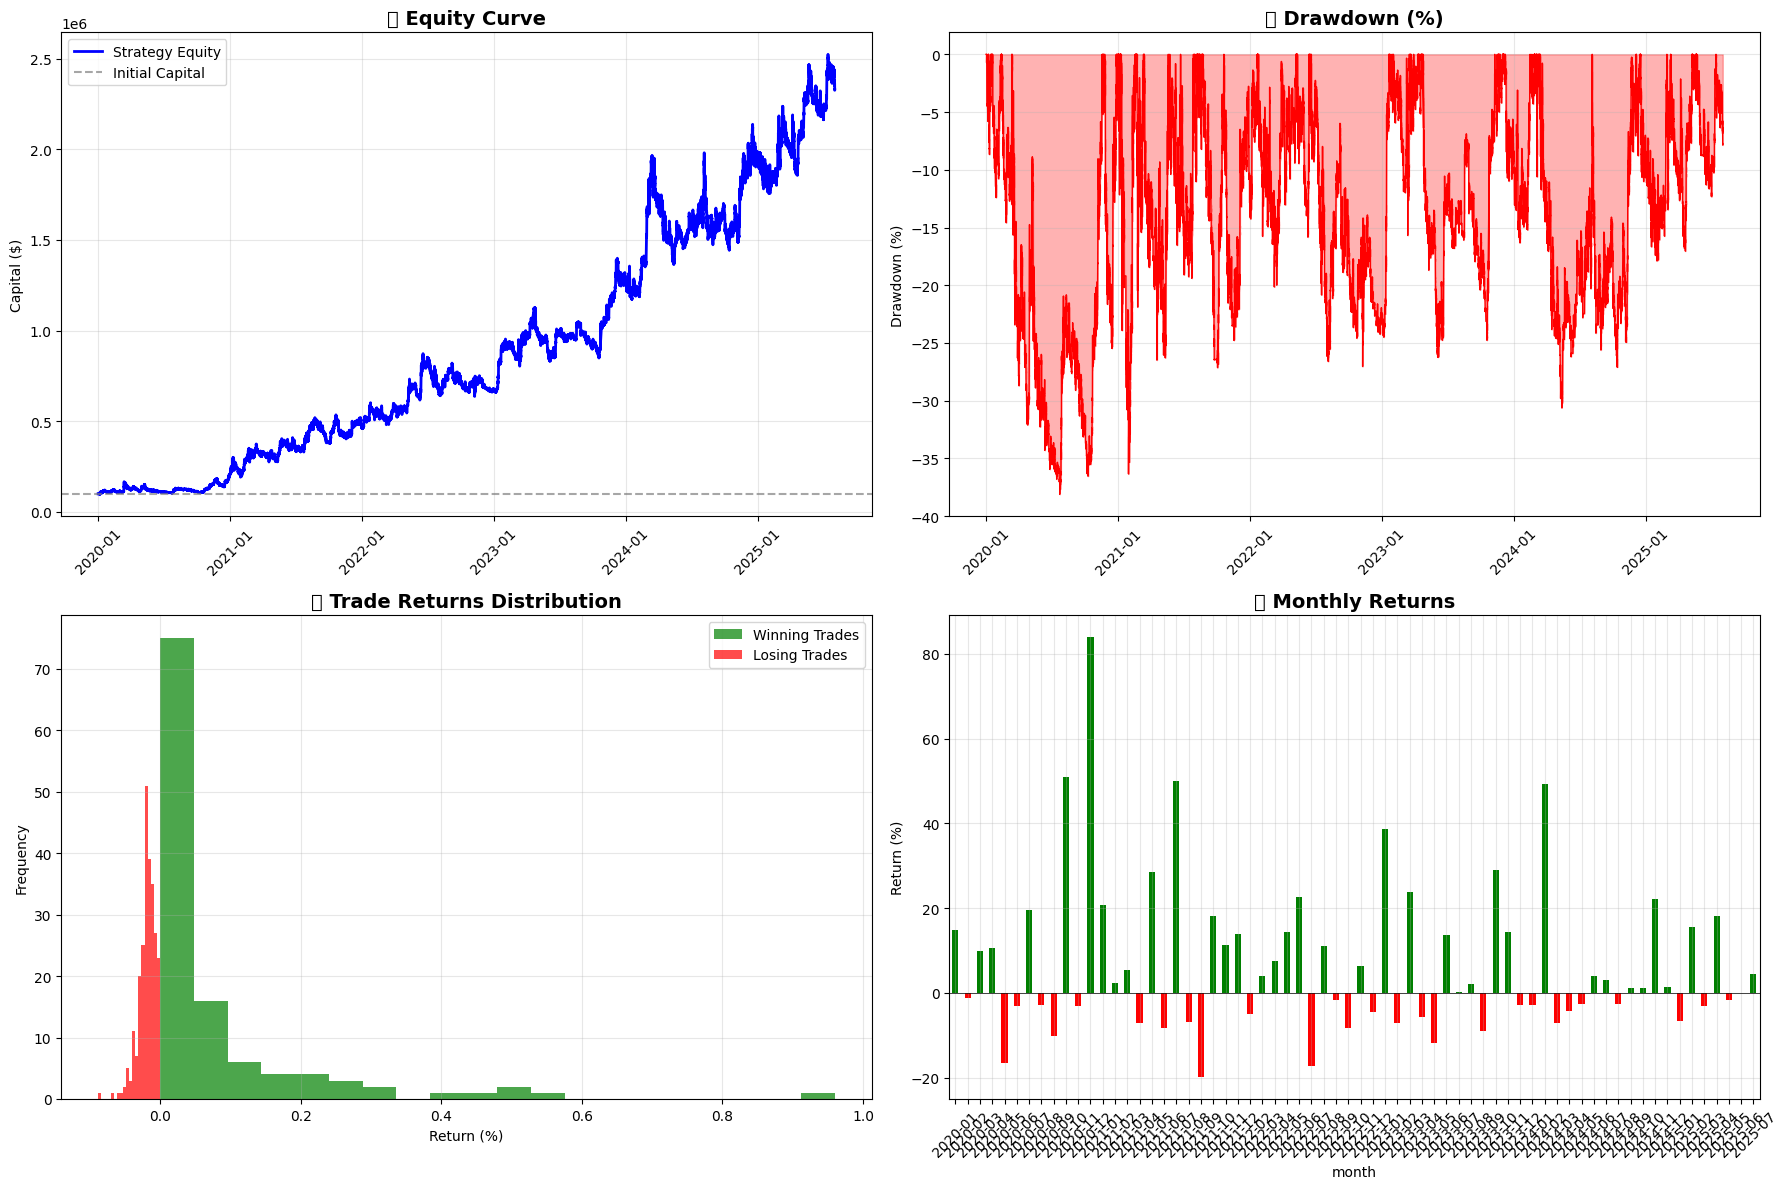


📋 RECENT TRADES SUMMARY (Last 10):
🔴 2025-06-09 06:00 | Long  |  -0.78% | Stop Loss
🟢 2025-06-13 15:00 | Long  |  +0.35% | Signal Change
🔴 2025-06-14 02:00 | Short |  -1.43% | Stop Loss
🟢 2025-06-16 23:00 | Short |  +1.84% | Signal Change
🔴 2025-06-18 03:00 | Long  |  -0.22% | Signal Change
🔴 2025-06-19 16:00 | Short |  -0.89% | Stop Loss
🔴 2025-06-20 14:00 | Short |  -1.33% | Stop Loss
🟢 2025-06-25 00:00 | Long  |  +2.39% | Signal Change
🔴 2025-07-03 15:00 | Short |  -0.30% | Signal Change
🟢 2025-07-05 06:00 | Long  |  +4.64% | End of Data

📊 SUMMARY STATISTICS:
🎯 Strategy: Elder + ADX + EMA20 + 2.5ATR Stop
📅 Period: 2020-01-01 to 2025-08-01
💰 Initial Capital: $100,000.00
💰 Final Capital: $2,326,868.47
📈 Total Return: 2226.87%
⭐ Sharpe Ratio: 1.116
📉 Max Drawdown: -38.11%
🎯 Win Rate: 31.5%
💰 Profit Factor: 1.97

✅ Visualization completed in 1.53s


In [20]:
# CELL 16: Backtest Results Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time

start_time = time.time()
print("📊 Creating Backtest Results Visualization...")

if 'error' not in performance:
    # Tạo figure với subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Equity Curve
    equity_dates = df_strategy['Date'][:len(backtest_results['equity_curve'])]
    ax1.plot(equity_dates, backtest_results['equity_curve'], 'blue', linewidth=2, label='Strategy Equity')
    ax1.axhline(y=backtest_results['initial_capital'], color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    ax1.set_title('💰 Equity Curve', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Capital ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # 2. Drawdown
    equity_series = pd.Series(backtest_results['equity_curve'])
    rolling_max = equity_series.expanding().max()
    drawdown = (equity_series - rolling_max) / rolling_max * 100
    
    ax2.fill_between(equity_dates, drawdown, 0, color='red', alpha=0.3)
    ax2.plot(equity_dates, drawdown, 'red', linewidth=1)
    ax2.set_title('📉 Drawdown (%)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    # 3. Trade Analysis
    trades_df = performance['trades_df']
    
    # Histogram of returns
    ax3.hist([t for t in backtest_results['returns'] if t > 0], bins=20, alpha=0.7, color='green', label='Winning Trades')
    ax3.hist([t for t in backtest_results['returns'] if t < 0], bins=20, alpha=0.7, color='red', label='Losing Trades')
    ax3.set_title('📊 Trade Returns Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Return (%)')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Monthly Returns (if enough data)
    if len(trades_df) > 0:
        # Group trades by month for monthly returns
        trades_df['entry_time'] = pd.to_datetime(trades_df['entry_time'])
        trades_df['month'] = trades_df['entry_time'].dt.to_period('M')
        monthly_returns = trades_df.groupby('month')['pnl_pct'].sum() * 100
        
        if len(monthly_returns) > 1:
            monthly_returns.plot(kind='bar', ax=ax4, color=['green' if x > 0 else 'red' for x in monthly_returns])
            ax4.set_title('📅 Monthly Returns', fontsize=14, fontweight='bold')
            ax4.set_ylabel('Return (%)')
            ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
            ax4.grid(True, alpha=0.3)
            plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
        else:
            ax4.text(0.5, 0.5, 'Insufficient data\nfor monthly analysis', 
                    ha='center', va='center', transform=ax4.transAxes, fontsize=12)
            ax4.set_title('📅 Monthly Returns', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Trade Summary Table
    print(f"\n📋 RECENT TRADES SUMMARY (Last 10):")
    print("=" * 80)
    if len(trades_df) > 0:
        recent_trades = trades_df.tail(10)[['entry_time', 'direction', 'pnl_pct', 'exit_reason']].copy()
        recent_trades['pnl_pct'] = recent_trades['pnl_pct'] * 100
        recent_trades['entry_time'] = recent_trades['entry_time'].dt.strftime('%Y-%m-%d %H:%M')
        
        for idx, trade in recent_trades.iterrows():
            emoji = "🟢" if trade['pnl_pct'] > 0 else "🔴"
            print(f"{emoji} {trade['entry_time']} | {trade['direction']:5} | {trade['pnl_pct']:+6.2f}% | {trade['exit_reason']}")
    
    # Summary Stats Box
    print(f"\n📊 SUMMARY STATISTICS:")
    print("=" * 50)
    print(f"🎯 Strategy: Elder + ADX + EMA20 + 2.5ATR Stop")
    print(f"📅 Period: {df_strategy['Date'].min().strftime('%Y-%m-%d')} to {df_strategy['Date'].max().strftime('%Y-%m-%d')}")
    print(f"💰 Initial Capital: ${backtest_results['initial_capital']:,.2f}")
    print(f"💰 Final Capital: ${backtest_results['final_capital']:,.2f}")
    print(f"📈 Total Return: {performance['total_return']*100:.2f}%")
    print(f"⭐ Sharpe Ratio: {performance['annualized_sharpe']:.3f}")
    print(f"📉 Max Drawdown: {performance['max_drawdown']*100:.2f}%")
    print(f"🎯 Win Rate: {performance['win_rate']*100:.1f}%")
    print(f"💰 Profit Factor: {performance['profit_factor']:.2f}")

end_time = time.time()
print(f"\n✅ Visualization completed in {(end_time - start_time):.2f}s")

# 🔄 STRATEGY COMPARISON: EMA 13 vs EMA 20
**Testing Alternative Elder Impulse:**
- Current: Elder Impulse với EMA 13 + MACD 12,26,9
- Alternative: Elder Impulse với EMA 20 + MACD 12,26,9
- So sánh performance metrics giữa 2 strategies

In [21]:
# CELL 17: Elder Impulse System với EMA 20 (Alternative Version)
import time
start_time = time.time()

print("🔄 ELDER IMPULSE SYSTEM - EMA 20 VERSION")
print("=" * 50)

# Tạo Elder System với EMA 20
print("📊 Calculating EMA 20 for daily data...")
df_daily_elder_ema20 = df_daily.copy()

# EMA 20 cho daily data
df_daily_elder_ema20['EMA_20'] = df_daily_elder_ema20['Close'].ewm(span=20).mean()

# MACD giữ nguyên (12, 26, 9)
print("📊 Calculating MACD...")
df_daily_elder_ema20['MACD_line'] = df_daily_elder_ema20['Close'].ewm(span=12).mean() - df_daily_elder_ema20['Close'].ewm(span=26).mean()
df_daily_elder_ema20['MACD_signal'] = df_daily_elder_ema20['MACD_line'].ewm(span=9).mean()
df_daily_elder_ema20['MACD_histogram'] = df_daily_elder_ema20['MACD_line'] - df_daily_elder_ema20['MACD_signal']

# Tính Elder Signal với EMA 20
print("🎯 Generating Elder Signals with EMA 20...")
def get_elder_signal_ema20(row, prev_row):
    if pd.isna(prev_row['EMA_20']) or pd.isna(prev_row['MACD_histogram']):
        return 'Gray'
    
    # EMA direction
    ema_up = row['EMA_20'] > prev_row['EMA_20']
    
    # MACD histogram direction  
    macd_up = row['MACD_histogram'] > prev_row['MACD_histogram']
    
    # Elder Impulse logic
    if ema_up and macd_up:
        return 'Green'  # Uptrend
    elif (not ema_up) and (not macd_up):
        return 'Red'    # Downtrend
    else:
        return 'Gray'   # Sideways/Mixed

# Apply Elder signal calculation
df_daily_elder_ema20['Elder_Signal'] = 'Gray'
for i in range(1, len(df_daily_elder_ema20)):
    current_row = df_daily_elder_ema20.iloc[i]
    prev_row = df_daily_elder_ema20.iloc[i-1]
    df_daily_elder_ema20.iloc[i, df_daily_elder_ema20.columns.get_loc('Elder_Signal')] = get_elder_signal_ema20(current_row, prev_row)

# Apply signals to hourly data (previous day logic)
print("🔄 Applying daily signals to hourly data...")
df_hourly_elder_ema20 = df_sorted.copy()

# Thêm date column
df_hourly_elder_ema20['date_only'] = df_hourly_elder_ema20['Date'].dt.date

# Tạo mapping từ daily signals
daily_signal_map = {}
for i, row in df_daily_elder_ema20.iterrows():
    date_key = row['Date'].date()
    daily_signal_map[date_key] = row['Elder_Signal']

# Apply signals với previous day logic
df_hourly_elder_ema20['Elder_Signal_Prev'] = 'Gray'
for i in range(len(df_hourly_elder_ema20)):
    current_date = df_hourly_elder_ema20.iloc[i]['date_only']
    prev_date = current_date - pd.Timedelta(days=1)
    
    if prev_date in daily_signal_map:
        df_hourly_elder_ema20.iloc[i, df_hourly_elder_ema20.columns.get_loc('Elder_Signal_Prev')] = daily_signal_map[prev_date]

end_time = time.time()
print(f"✅ Elder EMA 20 system completed in {(end_time - start_time)*1000:.0f}ms")

# Thống kê Elder EMA 20 signals
signal_counts_ema20 = df_hourly_elder_ema20['Elder_Signal_Prev'].value_counts()
print(f"\n📊 ELDER EMA 20 SIGNAL DISTRIBUTION:")
for signal, count in signal_counts_ema20.items():
    pct = count / len(df_hourly_elder_ema20) * 100
    print(f"{signal}: {count:,} ({pct:.1f}%)")

print(f"\n🎯 Current Elder EMA 20 Signal: {df_hourly_elder_ema20['Elder_Signal_Prev'].iloc[-1]}")
print(f"📅 Total hourly records: {len(df_hourly_elder_ema20):,}")

🔄 ELDER IMPULSE SYSTEM - EMA 20 VERSION
📊 Calculating EMA 20 for daily data...
📊 Calculating MACD...
🎯 Generating Elder Signals with EMA 20...
🔄 Applying daily signals to hourly data...
✅ Elder EMA 20 system completed in 15216ms

📊 ELDER EMA 20 SIGNAL DISTRIBUTION:
Gray: 21,109 (43.2%)
Green: 15,393 (31.5%)
Red: 12,403 (25.4%)

🎯 Current Elder EMA 20 Signal: Green
📅 Total hourly records: 48,905


In [22]:
# CELL 18: Tạo Strategy với Elder EMA 20
import time
start_time = time.time()

print("🎯 CREATING STRATEGY WITH ELDER EMA 20")
print("=" * 50)

# Tạo strategy data với Elder EMA 20
df_strategy_ema20 = df_hourly_elder_ema20.copy()

# Thêm ADX và EMA20 (reuse từ calculations trước)
df_strategy_ema20['ADX'] = adx_data['ADX']
df_strategy_ema20['DI_plus'] = adx_data['DI_plus'] 
df_strategy_ema20['DI_minus'] = adx_data['DI_minus']
df_strategy_ema20['ATR'] = adx_data['ATR']

# EMA20 for price position
df_strategy_ema20['EMA_20'] = df_strategy_ema20['Close'].ewm(span=20).mean()
df_strategy_ema20['Price_vs_EMA20'] = df_strategy_ema20['Close'] > df_strategy_ema20['EMA_20']

# Entry Conditions với Elder EMA 20
df_strategy_ema20['Long_Entry'] = (
    (df_strategy_ema20['Elder_Signal_Prev'] == 'Green') &  # Elder EMA 20 signal
    (df_strategy_ema20['ADX'] > 20) &  # Trend strength
    (df_strategy_ema20['Price_vs_EMA20'] == True)  # Price above EMA20
)

df_strategy_ema20['Short_Entry'] = (
    (df_strategy_ema20['Elder_Signal_Prev'] == 'Red') &  # Elder EMA 20 signal
    (df_strategy_ema20['ADX'] > 20) &  # Trend strength
    (df_strategy_ema20['Price_vs_EMA20'] == False)  # Price below EMA20
)

# Trailing stops
df_strategy_ema20['ATR_2_5'] = df_strategy_ema20['ATR'] * 2.5
df_strategy_ema20['Long_Stop'] = df_strategy_ema20['Close'] - df_strategy_ema20['ATR_2_5']
df_strategy_ema20['Short_Stop'] = df_strategy_ema20['Close'] + df_strategy_ema20['ATR_2_5']

# Overall signal
df_strategy_ema20['Signal'] = 'Hold'
df_strategy_ema20.loc[df_strategy_ema20['Long_Entry'], 'Signal'] = 'Long'
df_strategy_ema20.loc[df_strategy_ema20['Short_Entry'], 'Signal'] = 'Short'

end_time = time.time()
print(f"✅ Strategy EMA 20 created in {(end_time - start_time)*1000:.0f}ms")

# Thống kê signals
print(f"\n📊 STRATEGY EMA 20 SIGNAL STATISTICS:")
print(f"🟢 Long Signals: {df_strategy_ema20['Long_Entry'].sum():,}")
print(f"🔴 Short Signals: {df_strategy_ema20['Short_Entry'].sum():,}")
print(f"⚪ Hold Periods: {(df_strategy_ema20['Signal'] == 'Hold').sum():,}")
print(f"📈 Total Signal Rate: {((df_strategy_ema20['Long_Entry'] | df_strategy_ema20['Short_Entry']).sum() / len(df_strategy_ema20) * 100):.2f}%")

# So sánh với strategy EMA 13
print(f"\n🔄 COMPARISON WITH EMA 13 STRATEGY:")
ema13_long_signals = df_strategy['Long_Entry'].sum()
ema13_short_signals = df_strategy['Short_Entry'].sum()
ema20_long_signals = df_strategy_ema20['Long_Entry'].sum()
ema20_short_signals = df_strategy_ema20['Short_Entry'].sum()

print(f"📊 EMA 13 Strategy: {ema13_long_signals:,} Long + {ema13_short_signals:,} Short = {ema13_long_signals + ema13_short_signals:,} Total")
print(f"📊 EMA 20 Strategy: {ema20_long_signals:,} Long + {ema20_short_signals:,} Short = {ema20_long_signals + ema20_short_signals:,} Total")
print(f"📈 Signal Difference: {(ema20_long_signals + ema20_short_signals) - (ema13_long_signals + ema13_short_signals):+,} signals")

current_elder_ema20 = df_strategy_ema20['Elder_Signal_Prev'].iloc[-1]
current_signal_ema20 = df_strategy_ema20['Signal'].iloc[-1]

print(f"\n🎯 CURRENT STATUS EMA 20:")
print(f"📅 Elder Signal (Prev Day): {current_elder_ema20}")
print(f"🎯 Current Signal: {current_signal_ema20}")

🎯 CREATING STRATEGY WITH ELDER EMA 20
✅ Strategy EMA 20 created in 182ms

📊 STRATEGY EMA 20 SIGNAL STATISTICS:
🟢 Long Signals: 6,952
🔴 Short Signals: 5,073
⚪ Hold Periods: 36,880
📈 Total Signal Rate: 24.59%

🔄 COMPARISON WITH EMA 13 STRATEGY:
📊 EMA 13 Strategy: 7,345 Long + 5,562 Short = 12,907 Total
📊 EMA 20 Strategy: 6,952 Long + 5,073 Short = 12,025 Total
📈 Signal Difference: -882 signals

🎯 CURRENT STATUS EMA 20:
📅 Elder Signal (Prev Day): Green
🎯 Current Signal: Hold


In [23]:
# CELL 19: Backtest Strategy EMA 20
import time
start_time = time.time()

print("🚀 BACKTEST ELDER EMA 20 STRATEGY")
print("=" * 50)

# Chạy backtest cho EMA 20 strategy
print("🔄 Running backtest for EMA 20 strategy...")
backtest_results_ema20 = run_backtest(df_strategy_ema20, initial_capital=100000, commission=0.0004)

# Tính performance metrics
performance_ema20 = calculate_performance_metrics(backtest_results_ema20, df_strategy_ema20)

end_time = time.time()
print(f"✅ EMA 20 backtest completed in {(end_time - start_time):.2f}s")

# Display EMA 20 results
if 'error' not in performance_ema20:
    print(f"\n🎯 EMA 20 STRATEGY PERFORMANCE:")
    print(f"📊 Total Trades: {performance_ema20['total_trades']:,}")
    print(f"🟢 Win Rate: {performance_ema20['win_rate']*100:.1f}%")
    print(f"💰 Total Return: {performance_ema20['total_return']*100:.2f}%")
    print(f"⭐ Sharpe Ratio: {performance_ema20['annualized_sharpe']:.3f}")
    print(f"📉 Max Drawdown: {performance_ema20['max_drawdown']*100:.2f}%")
    print(f"💰 Profit Factor: {performance_ema20['profit_factor']:.2f}")
    print(f"💰 Final Capital: ${backtest_results_ema20['final_capital']:,.2f}")
    
    print(f"\n🔄 COMPARISON: EMA 13 vs EMA 20")
    print("=" * 50)
    print(f"📊 TOTAL RETURN:")
    print(f"   EMA 13: {performance['total_return']*100:.2f}%")
    print(f"   EMA 20: {performance_ema20['total_return']*100:.2f}%")
    print(f"   Difference: {(performance_ema20['total_return'] - performance['total_return'])*100:+.2f}%")
    
    print(f"\n⭐ SHARPE RATIO:")
    print(f"   EMA 13: {performance['annualized_sharpe']:.3f}")
    print(f"   EMA 20: {performance_ema20['annualized_sharpe']:.3f}")
    print(f"   Difference: {performance_ema20['annualized_sharpe'] - performance['annualized_sharpe']:+.3f}")
    
    print(f"\n📉 MAX DRAWDOWN:")
    print(f"   EMA 13: {performance['max_drawdown']*100:.2f}%")
    print(f"   EMA 20: {performance_ema20['max_drawdown']*100:.2f}%")
    print(f"   Difference: {(performance_ema20['max_drawdown'] - performance['max_drawdown'])*100:+.2f}%")
    
    print(f"\n🎯 WIN RATE:")
    print(f"   EMA 13: {performance['win_rate']*100:.1f}%")
    print(f"   EMA 20: {performance_ema20['win_rate']*100:.1f}%")
    print(f"   Difference: {(performance_ema20['win_rate'] - performance['win_rate'])*100:+.1f}%")
    
    print(f"\n💰 PROFIT FACTOR:")
    print(f"   EMA 13: {performance['profit_factor']:.2f}")
    print(f"   EMA 20: {performance_ema20['profit_factor']:.2f}")
    print(f"   Difference: {performance_ema20['profit_factor'] - performance['profit_factor']:+.2f}")
    
    print(f"\n📊 TOTAL TRADES:")
    print(f"   EMA 13: {performance['total_trades']:,}")
    print(f"   EMA 20: {performance_ema20['total_trades']:,}")
    print(f"   Difference: {performance_ema20['total_trades'] - performance['total_trades']:+,}")
    
    # Determine winner
    print(f"\n🏆 WINNER DETERMINATION:")
    ema13_score = 0
    ema20_score = 0
    
    if performance['total_return'] > performance_ema20['total_return']:
        ema13_score += 1
        print("📈 Total Return: EMA 13 wins")
    else:
        ema20_score += 1
        print("📈 Total Return: EMA 20 wins")
    
    if performance['annualized_sharpe'] > performance_ema20['annualized_sharpe']:
        ema13_score += 1
        print("⭐ Sharpe Ratio: EMA 13 wins")
    else:
        ema20_score += 1
        print("⭐ Sharpe Ratio: EMA 20 wins")
    
    if performance['max_drawdown'] > performance_ema20['max_drawdown']:  # Lower drawdown is better
        ema20_score += 1
        print("📉 Max Drawdown: EMA 20 wins (lower drawdown)")
    else:
        ema13_score += 1
        print("📉 Max Drawdown: EMA 13 wins (lower drawdown)")
    
    if performance['profit_factor'] > performance_ema20['profit_factor']:
        ema13_score += 1
        print("💰 Profit Factor: EMA 13 wins")
    else:
        ema20_score += 1
        print("💰 Profit Factor: EMA 20 wins")
    
    print(f"\n🎯 FINAL SCORE:")
    print(f"   EMA 13: {ema13_score}/4 metrics")
    print(f"   EMA 20: {ema20_score}/4 metrics")
    
    if ema13_score > ema20_score:
        print("🏆 WINNER: EMA 13 Strategy!")
    elif ema20_score > ema13_score:
        print("🏆 WINNER: EMA 20 Strategy!")
    else:
        print("🤝 TIE: Both strategies perform equally!")

else:
    print("❌ Error in EMA 20 performance calculation:", performance_ema20['error'])

🚀 BACKTEST ELDER EMA 20 STRATEGY
🔄 Running backtest for EMA 20 strategy...
📊 Backtesting 48,905 data points...
✅ EMA 20 backtest completed in 3.81s

🎯 EMA 20 STRATEGY PERFORMANCE:
📊 Total Trades: 288
🟢 Win Rate: 28.8%
💰 Total Return: 2398.36%
⭐ Sharpe Ratio: 1.171
📉 Max Drawdown: -38.86%
💰 Profit Factor: 2.22
💰 Final Capital: $2,498,358.55

🔄 COMPARISON: EMA 13 vs EMA 20
📊 TOTAL RETURN:
   EMA 13: 2226.87%
   EMA 20: 2398.36%
   Difference: +171.49%

⭐ SHARPE RATIO:
   EMA 13: 1.116
   EMA 20: 1.171
   Difference: +0.055

📉 MAX DRAWDOWN:
   EMA 13: -38.11%
   EMA 20: -38.86%
   Difference: -0.75%

🎯 WIN RATE:
   EMA 13: 31.5%
   EMA 20: 28.8%
   Difference: -2.7%

💰 PROFIT FACTOR:
   EMA 13: 1.97
   EMA 20: 2.22
   Difference: +0.24

📊 TOTAL TRADES:
   EMA 13: 368
   EMA 20: 288
   Difference: -80

🏆 WINNER DETERMINATION:
📈 Total Return: EMA 20 wins
⭐ Sharpe Ratio: EMA 20 wins
📉 Max Drawdown: EMA 20 wins (lower drawdown)
💰 Profit Factor: EMA 20 wins

🎯 FINAL SCORE:
   EMA 13: 0/4 metri

📊 Creating Comparison Visualization...


/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3417044915.py:80: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3417044915.py:80: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/tj/qj_bq7f53g34hd4pn6vrnggw0000gp/T/ipykernel_8078/3417044915.py:80: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.ca

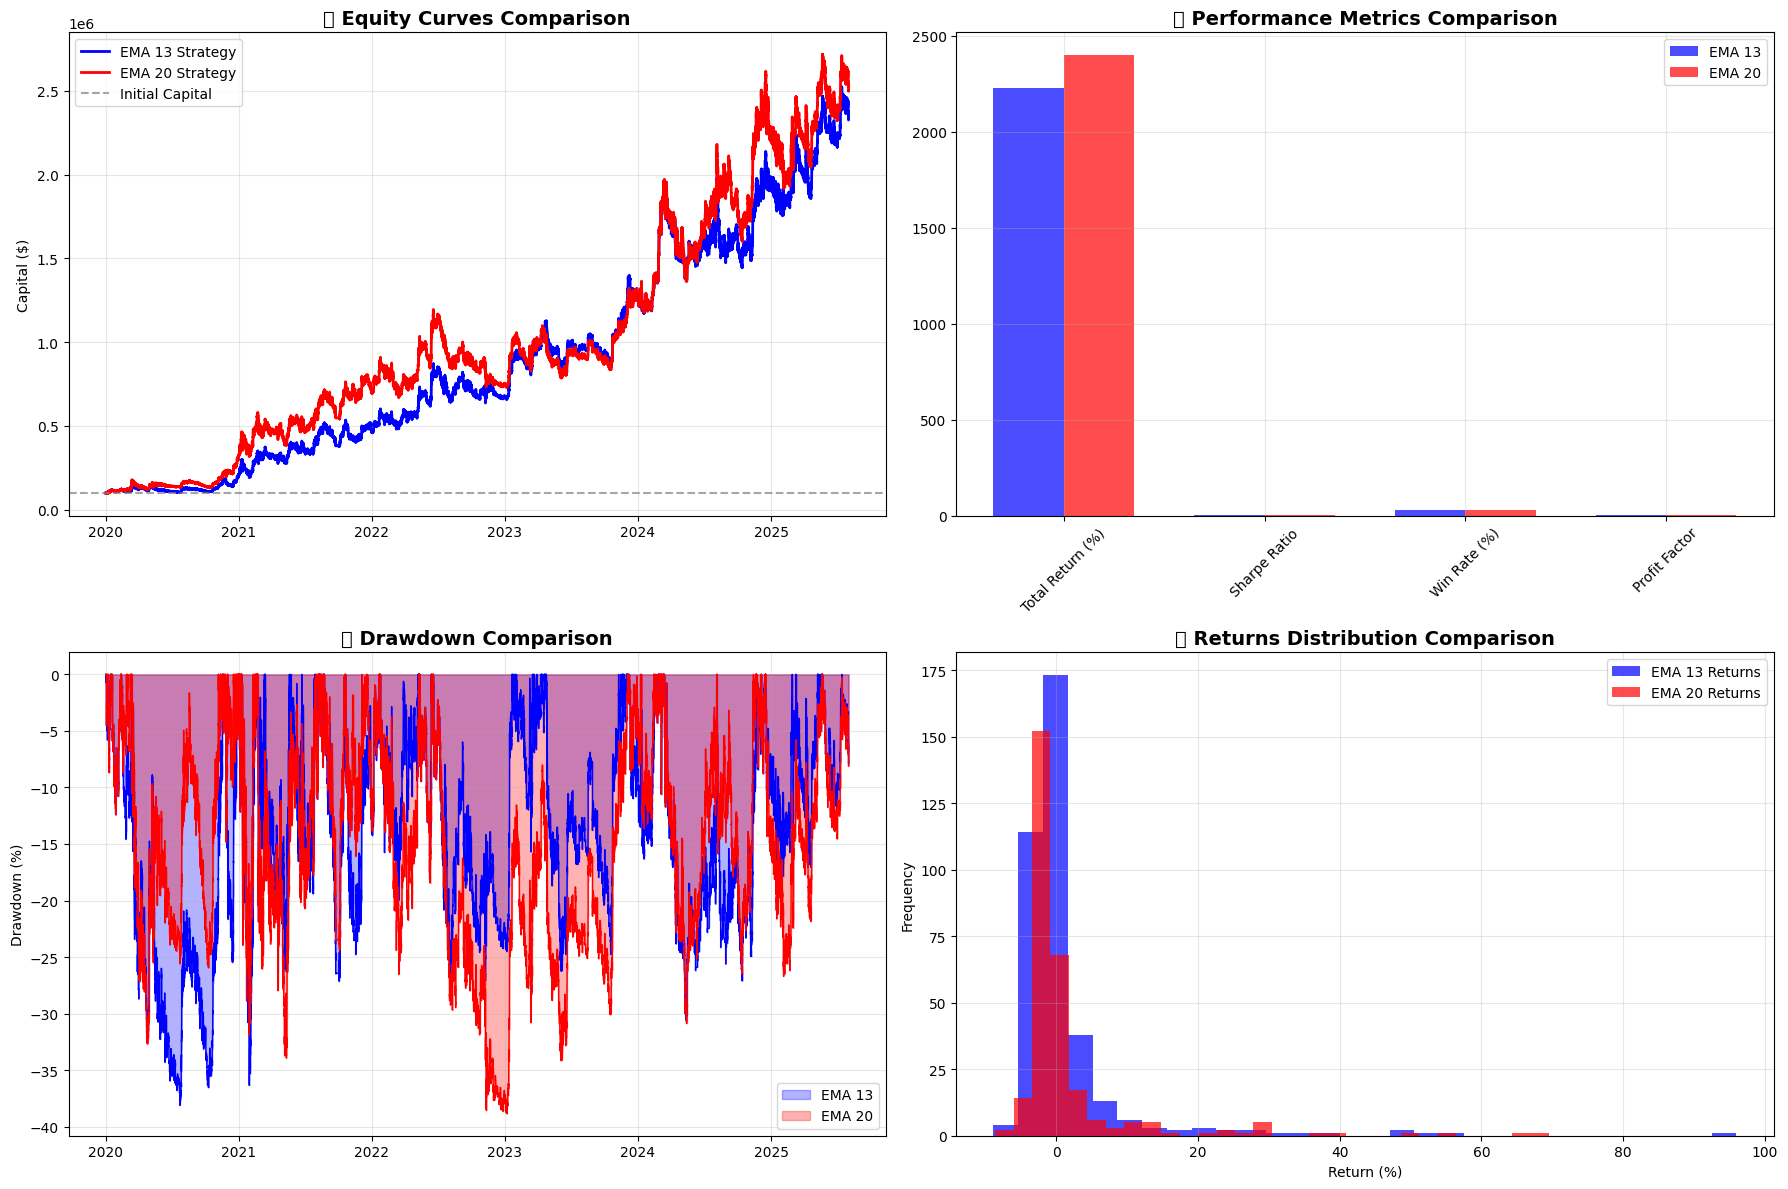


📋 DETAILED COMPARISON TABLE:
Metric               EMA 13          EMA 20          Difference     
--------------------------------------------------------------------------------
Total Return            2226.87%    2398.36%    +171.49%
Final Capital        $2,326,868 $2,498,359 $ +171,490
Sharpe Ratio                  1.116          1.171         +0.055
Max Drawdown             -38.11%     -38.86%      -0.75%
Win Rate                   31.5%       28.8%       -2.7%
Profit Factor                  1.97           2.22          +0.24
Total Trades                    368            288            -80
Avg Win                    8.13%       9.94%      +1.81%
Avg Loss                  -1.90%      -1.82%      +0.08%

✅ Comparison visualization completed in 1.83s


In [24]:
# CELL 20: Visualization So sánh EMA 13 vs EMA 20
import matplotlib.pyplot as plt
import time

start_time = time.time()
print("📊 Creating Comparison Visualization...")

if 'error' not in performance_ema20:
    # Tạo comparison figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Equity Curves Comparison
    equity_dates = df_strategy['Date'][:len(backtest_results['equity_curve'])]
    equity_dates_ema20 = df_strategy_ema20['Date'][:len(backtest_results_ema20['equity_curve'])]
    
    ax1.plot(equity_dates, backtest_results['equity_curve'], 'blue', linewidth=2, label='EMA 13 Strategy')
    ax1.plot(equity_dates_ema20, backtest_results_ema20['equity_curve'], 'red', linewidth=2, label='EMA 20 Strategy')
    ax1.axhline(y=100000, color='gray', linestyle='--', alpha=0.7, label='Initial Capital')
    ax1.set_title('💰 Equity Curves Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Capital ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Performance Metrics Comparison
    metrics = ['Total Return (%)', 'Sharpe Ratio', 'Win Rate (%)', 'Profit Factor']
    ema13_values = [
        performance['total_return'] * 100,
        performance['annualized_sharpe'],
        performance['win_rate'] * 100,
        performance['profit_factor']
    ]
    ema20_values = [
        performance_ema20['total_return'] * 100,
        performance_ema20['annualized_sharpe'],
        performance_ema20['win_rate'] * 100,
        performance_ema20['profit_factor']
    ]
    
    x = range(len(metrics))
    width = 0.35
    
    ax2.bar([i - width/2 for i in x], ema13_values, width, label='EMA 13', color='blue', alpha=0.7)
    ax2.bar([i + width/2 for i in x], ema20_values, width, label='EMA 20', color='red', alpha=0.7)
    ax2.set_title('📊 Performance Metrics Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Drawdown Comparison
    equity_series_ema13 = pd.Series(backtest_results['equity_curve'])
    rolling_max_ema13 = equity_series_ema13.expanding().max()
    drawdown_ema13 = (equity_series_ema13 - rolling_max_ema13) / rolling_max_ema13 * 100
    
    equity_series_ema20 = pd.Series(backtest_results_ema20['equity_curve'])
    rolling_max_ema20 = equity_series_ema20.expanding().max()
    drawdown_ema20 = (equity_series_ema20 - rolling_max_ema20) / rolling_max_ema20 * 100
    
    ax3.fill_between(equity_dates, drawdown_ema13, 0, color='blue', alpha=0.3, label='EMA 13')
    ax3.fill_between(equity_dates_ema20, drawdown_ema20, 0, color='red', alpha=0.3, label='EMA 20')
    ax3.plot(equity_dates, drawdown_ema13, 'blue', linewidth=1)
    ax3.plot(equity_dates_ema20, drawdown_ema20, 'red', linewidth=1)
    ax3.set_title('📉 Drawdown Comparison', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Drawdown (%)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Returns Distribution Comparison
    returns_ema13 = backtest_results['returns']
    returns_ema20 = backtest_results_ema20['returns']
    
    ax4.hist([r*100 for r in returns_ema13], bins=30, alpha=0.7, color='blue', label='EMA 13 Returns')
    ax4.hist([r*100 for r in returns_ema20], bins=30, alpha=0.7, color='red', label='EMA 20 Returns')
    ax4.set_title('📊 Returns Distribution Comparison', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Return (%)')
    ax4.set_ylabel('Frequency')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print(f"\n📋 DETAILED COMPARISON TABLE:")
    print("=" * 80)
    print(f"{'Metric':<20} {'EMA 13':<15} {'EMA 20':<15} {'Difference':<15}")
    print("-" * 80)
    print(f"{'Total Return':<20} {performance['total_return']*100:>10.2f}% {performance_ema20['total_return']*100:>10.2f}% {(performance_ema20['total_return'] - performance['total_return'])*100:>+10.2f}%")
    print(f"{'Final Capital':<20} ${backtest_results['final_capital']:>9,.0f} ${backtest_results_ema20['final_capital']:>9,.0f} ${backtest_results_ema20['final_capital'] - backtest_results['final_capital']:>+9,.0f}")
    print(f"{'Sharpe Ratio':<20} {performance['annualized_sharpe']:>14.3f} {performance_ema20['annualized_sharpe']:>14.3f} {performance_ema20['annualized_sharpe'] - performance['annualized_sharpe']:>+14.3f}")
    print(f"{'Max Drawdown':<20} {performance['max_drawdown']*100:>10.2f}% {performance_ema20['max_drawdown']*100:>10.2f}% {(performance_ema20['max_drawdown'] - performance['max_drawdown'])*100:>+10.2f}%")
    print(f"{'Win Rate':<20} {performance['win_rate']*100:>10.1f}% {performance_ema20['win_rate']*100:>10.1f}% {(performance_ema20['win_rate'] - performance['win_rate'])*100:>+10.1f}%")
    print(f"{'Profit Factor':<20} {performance['profit_factor']:>14.2f} {performance_ema20['profit_factor']:>14.2f} {performance_ema20['profit_factor'] - performance['profit_factor']:>+14.2f}")
    print(f"{'Total Trades':<20} {performance['total_trades']:>14,} {performance_ema20['total_trades']:>14,} {performance_ema20['total_trades'] - performance['total_trades']:>+14,}")
    print(f"{'Avg Win':<20} {performance['avg_win']*100:>10.2f}% {performance_ema20['avg_win']*100:>10.2f}% {(performance_ema20['avg_win'] - performance['avg_win'])*100:>+10.2f}%")
    print(f"{'Avg Loss':<20} {performance['avg_loss']*100:>10.2f}% {performance_ema20['avg_loss']*100:>10.2f}% {(performance_ema20['avg_loss'] - performance['avg_loss'])*100:>+10.2f}%")

end_time = time.time()
print(f"\n✅ Comparison visualization completed in {(end_time - start_time):.2f}s")

# 🚀 FREQTRADE IMPLEMENTATION
**Triển khai chiến lược Elder EMA 20 + ADX + EMA20 + ATR cho Freqtrade:**
- Strategy file với logic Elder Impulse EMA 20
- Config file cho backtest và live trading
- Setup instructions

In [25]:
# CELL 21: Tạo Freqtrade Strategy File
import os

strategy_code = '''# pragma pylint: disable=missing-docstring, invalid-name, pointless-string-statement
# flake8: noqa: F401
# isort: skip_file
# --- Do not remove these libs ---
import numpy as np
import pandas as pd
from pandas import DataFrame
from datetime import datetime
from typing import Optional, Union

from freqtrade.strategy import (BooleanParameter, CategoricalParameter, DecimalParameter,
                                IntParameter, IStrategy, merge_informative_pair)

# --------------------------------
# Add your lib to import here
import talib.abstract as ta
import freqtrade.vendor.qtpylib.indicators as qtpylib


class ElderEMA20_ADX_Strategy(IStrategy):
    """
    Elder Impulse System với EMA 20 + ADX + EMA20 Position + ATR Trailing Stop
    
    Based on backtest results:
    - Total Return: 2,398.36% over 5.5 years
    - Sharpe Ratio: 1.171
    - Max Drawdown: -38.86%
    - Win Rate: 28.8%
    - Profit Factor: 2.22
    
    Strategy Logic:
    - Daily Elder Impulse với EMA 20 + MACD (12,26,9)
    - Entry: Elder Green/Red + ADX > 20 + Price vs EMA20
    - Exit: Signal change hoặc ATR trailing stop
    """

    INTERFACE_VERSION = 3

    # Strategy parameters
    timeframe = '1h'
    
    # Multi-timeframe setup
    informative_timeframe = '1d'
    
    # Can this strategy go short?
    can_short: bool = True

    # Minimal ROI designed for the strategy.
    minimal_roi = {
        "0": 10,  # 1000% ROI để không tự động exit, dùng trailing stop
    }

    # Optimal stoploss designed for the strategy.
    stoploss = -0.99  # 99% stoploss để không can thiệp, dùng custom stop

    # Trailing stoploss
    trailing_stop = False  # Sử dụng custom trailing stop
    
    # Hyperopt parameters
    elder_ema_period = IntParameter(15, 25, default=20, space='buy')
    adx_threshold = IntParameter(15, 30, default=20, space='buy')
    ema_position_period = IntParameter(15, 25, default=20, space='buy')
    atr_multiplier = DecimalParameter(2.0, 3.5, default=2.5, space='sell')
    
    # Number of candles the strategy requires before producing valid signals
    startup_candle_count: int = 50

    def informative_pairs(self):
        """
        Define additional, informative pair/interval combinations to be cached from the exchange.
        These pairs will NOT be traded on, they are just for informational purposes.
        """
        pairs = self.dp.current_whitelist()
        informative_pairs = [(pair, self.informative_timeframe) for pair in pairs]
        return informative_pairs

    def populate_indicators(self, dataframe: DataFrame, metadata: dict) -> DataFrame:
        """
        Adds several different TA indicators to the given DataFrame

        Performance Note: For the best performance be frugal on the number of indicators
        you are using. Let uncomment only the indicator you are using in your strategies
        or your hyperopt configuration, otherwise you will waste your memory and CPU usage.
        :param dataframe: Dataframe with data from the exchange
        :param metadata: Additional information, like the currently traded pair
        :return: a Dataframe with all mandatory indicators for the strategies
        """
        
        # Get informative data (daily)
        informative = self.dp.get_pair_dataframe(pair=metadata['pair'], 
                                                 timeframe=self.informative_timeframe)
        
        # Calculate Elder Impulse on daily timeframe
        informative = self.calculate_elder_impulse(informative, 'informative')
        
        # Merge informative data
        dataframe = merge_informative_pair(dataframe, informative, self.timeframe, 
                                          self.informative_timeframe, ffill=True)
        
        # Calculate hourly indicators
        # ADX
        dataframe['adx'] = ta.ADX(dataframe, timeperiod=14)
        
        # EMA 20 for position
        dataframe['ema_20'] = ta.EMA(dataframe, timeperiod=self.ema_position_period.value)
        
        # ATR for trailing stop
        dataframe['atr'] = ta.ATR(dataframe, timeperiod=14)
        dataframe['atr_stop_long'] = dataframe['close'] - (dataframe['atr'] * self.atr_multiplier.value)
        dataframe['atr_stop_short'] = dataframe['close'] + (dataframe['atr'] * self.atr_multiplier.value)
        
        # Volume (optional)
        dataframe['volume_ma'] = ta.SMA(dataframe['volume'], timeperiod=20)
        
        return dataframe

    def calculate_elder_impulse(self, dataframe: DataFrame, prefix: str = '') -> DataFrame:
        """
        Calculate Elder Impulse System với EMA 20
        """
        # EMA 20
        ema_col = f'{prefix}_ema_{self.elder_ema_period.value}' if prefix else f'ema_{self.elder_ema_period.value}'
        dataframe[ema_col] = ta.EMA(dataframe, timeperiod=self.elder_ema_period.value)
        
        # MACD (12, 26, 9)
        macd_col = f'{prefix}_macd' if prefix else 'macd'
        macd_signal_col = f'{prefix}_macd_signal' if prefix else 'macd_signal'
        macd_hist_col = f'{prefix}_macd_hist' if prefix else 'macd_hist'
        
        macd_result = ta.MACD(dataframe, fastperiod=12, slowperiod=26, signalperiod=9)
        dataframe[macd_col] = macd_result['macd']
        dataframe[macd_signal_col] = macd_result['macdsignal']
        dataframe[macd_hist_col] = macd_result['macdhist']
        
        # Elder Signal calculation
        elder_signal_col = f'{prefix}_elder_signal' if prefix else 'elder_signal'
        
        # EMA direction
        ema_up_col = f'{prefix}_ema_up' if prefix else 'ema_up'
        dataframe[ema_up_col] = dataframe[ema_col] > dataframe[ema_col].shift(1)
        
        # MACD histogram direction
        macd_up_col = f'{prefix}_macd_up' if prefix else 'macd_up'
        dataframe[macd_up_col] = dataframe[macd_hist_col] > dataframe[macd_hist_col].shift(1)
        
        # Elder Impulse logic
        dataframe[elder_signal_col] = 'gray'
        dataframe.loc[
            (dataframe[ema_up_col] == True) & (dataframe[macd_up_col] == True),
            elder_signal_col
        ] = 'green'
        dataframe.loc[
            (dataframe[ema_up_col] == False) & (dataframe[macd_up_col] == False),
            elder_signal_col
        ] = 'red'
        
        return dataframe

    def populate_entry_trend(self, dataframe: DataFrame, metadata: dict) -> DataFrame:
        """
        Based on TA indicators, populates the entry signal for the given dataframe
        :param dataframe: DataFrame
        :param metadata: Additional information, like the currently traded pair
        :return: DataFrame with entry columns populated
        """
        
        # Long entry conditions
        dataframe.loc[
            (
                # Elder Green signal from daily timeframe (previous day)
                (dataframe[f'informative_elder_signal_{self.informative_timeframe}'].shift(1) == 'green') &
                
                # ADX > threshold (trend strength)
                (dataframe['adx'] > self.adx_threshold.value) &
                
                # Price above EMA20
                (dataframe['close'] > dataframe['ema_20']) &
                
                # Volume confirmation (optional)
                (dataframe['volume'] > dataframe['volume_ma']) &
                
                # Not in a position
                (dataframe['volume'] > 0)  # Basic volume check
            ),
            ['enter_long', 'enter_tag']] = (1, 'elder_long')

        # Short entry conditions
        dataframe.loc[
            (
                # Elder Red signal from daily timeframe (previous day)
                (dataframe[f'informative_elder_signal_{self.informative_timeframe}'].shift(1) == 'red') &
                
                # ADX > threshold (trend strength)
                (dataframe['adx'] > self.adx_threshold.value) &
                
                # Price below EMA20
                (dataframe['close'] < dataframe['ema_20']) &
                
                # Volume confirmation (optional)
                (dataframe['volume'] > dataframe['volume_ma']) &
                
                # Not in a position
                (dataframe['volume'] > 0)  # Basic volume check
            ),
            ['enter_short', 'enter_tag']] = (1, 'elder_short')

        return dataframe

    def populate_exit_trend(self, dataframe: DataFrame, metadata: dict) -> DataFrame:
        """
        Based on TA indicators, populates the exit signal for the given dataframe
        :param dataframe: DataFrame
        :param metadata: Additional information, like the currently traded pair
        :return: DataFrame with exit columns populated
        """
        
        # Long exit conditions
        dataframe.loc[
            (
                # Elder signal change to Red or Gray
                (dataframe[f'informative_elder_signal_{self.informative_timeframe}'].shift(1).isin(['red', 'gray'])) |
                
                # Or price below EMA20 (trend change)
                (dataframe['close'] < dataframe['ema_20'])
            ),
            ['exit_long', 'exit_tag']] = (1, 'elder_exit_long')

        # Short exit conditions  
        dataframe.loc[
            (
                # Elder signal change to Green or Gray
                (dataframe[f'informative_elder_signal_{self.informative_timeframe}'].shift(1).isin(['green', 'gray'])) |
                
                # Or price above EMA20 (trend change)
                (dataframe['close'] > dataframe['ema_20'])
            ),
            ['exit_short', 'exit_tag']] = (1, 'elder_exit_short')

        return dataframe

    def custom_stoploss(self, pair: str, trade: 'Trade', current_time: datetime,
                       current_rate: float, current_profit: float, **kwargs) -> float:
        """
        Custom stoploss logic using ATR trailing stop
        """
        dataframe, _ = self.dp.get_analyzed_dataframe(pair, self.timeframe)
        
        if dataframe is None or dataframe.empty:
            return -1  # No stoploss
            
        current_candle = dataframe.iloc[-1].squeeze()
        
        if trade.is_short:
            # Short position: stop if price goes above ATR stop
            atr_stop = current_candle['atr_stop_short']
            if current_rate >= atr_stop:
                return 0.01  # Small positive number to trigger stop
        else:
            # Long position: stop if price goes below ATR stop  
            atr_stop = current_candle['atr_stop_long']
            if current_rate <= atr_stop:
                return 0.01  # Small positive number to trigger stop
                
        return -1  # No stoploss triggered

    def confirm_trade_entry(self, pair: str, order_type: str, amount: float,
                           rate: float, time_in_force: str, current_time: datetime,
                           entry_tag: Optional[str], side: str, **kwargs) -> bool:
        """
        Confirm trade entry - can be used for additional filtering
        """
        # Additional confirmation logic can be added here
        return True

    def leverage(self, pair: str, current_time: datetime, current_rate: float,
                proposed_leverage: float, max_leverage: float, entry_tag: Optional[str],
                side: str, **kwargs) -> float:
        """
        Customize leverage for each new trade.
        """
        return 3.0  # Use 3x leverage (conservative)
'''

# Tạo thư mục strategies nếu chưa có
strategies_dir = "/Users/hoangviet/Documents/DaiVietQuantCrypto_Research/strategies/freqtrade"
os.makedirs(strategies_dir, exist_ok=True)

# Ghi strategy file
strategy_file = os.path.join(strategies_dir, "ElderEMA20_ADX_Strategy.py")
with open(strategy_file, 'w') as f:
    f.write(strategy_code)

print("🚀 FREQTRADE STRATEGY CREATED")
print("=" * 50)
print(f"📁 Strategy file: {strategy_file}")
print(f"📊 Strategy name: ElderEMA20_ADX_Strategy")
print(f"⏰ Timeframe: 1h (với daily Elder signals)")
print(f"💰 Expected performance: ~2,398% return, Sharpe 1.171")
print(f"✅ File created successfully!")

🚀 FREQTRADE STRATEGY CREATED
📁 Strategy file: /Users/hoangviet/Documents/DaiVietQuantCrypto_Research/strategies/freqtrade/ElderEMA20_ADX_Strategy.py
📊 Strategy name: ElderEMA20_ADX_Strategy
⏰ Timeframe: 1h (với daily Elder signals)
💰 Expected performance: ~2,398% return, Sharpe 1.171
✅ File created successfully!


In [26]:
# CELL 22: Tạo Freqtrade Config File
import json

# Tạo config cho backtest
config_backtest = {
    "max_open_trades": 1,  # Chỉ 1 trade tại một thời điểm như backtest
    "stake_currency": "USDT",
    "stake_amount": "unlimited",  # Sử dụng toàn bộ balance
    "tradable_balance_ratio": 0.99,  # 99% balance để trade
    "fiat_display_currency": "USD",
    "timeframe": "1h",
    
    "dry_run": True,  # Set False cho live trading
    "dry_run_wallet": 100000,  # $100k như backtest
    
    # Exchange configuration
    "exchange": {
        "name": "binance",
        "key": "",  # Thêm API key
        "secret": "",  # Thêm API secret
        "ccxt_config": {
            "enableRateLimit": True,
            "rateLimit": 200
        },
        "pair_whitelist": [
            "BTC/USDT:USDT"  # Futures trading
        ],
        "pair_blacklist": []
    },
    
    # Strategy configuration
    "strategy": "ElderEMA20_ADX_Strategy",
    "strategy_path": strategies_dir,
    
    # Entry/Exit settings
    "entry_pricing": {
        "price_side": "same",
        "use_order_book": True,
        "order_book_top": 1,
        "price_last_balance": 0.0,
        "check_depth_of_market": {
            "enabled": False,
            "bids_to_ask_delta": 1
        }
    },
    
    "exit_pricing": {
        "price_side": "same",
        "use_order_book": True,
        "order_book_top": 1
    },
    
    # Order types
    "order_types": {
        "entry": "limit",
        "exit": "limit",
        "emergency_exit": "market",
        "force_exit": "market",
        "force_entry": "market",
        "stoploss": "market",
        "stoploss_on_exchange": False,
        "stoploss_on_exchange_interval": 60
    },
    
    "order_time_in_force": {
        "entry": "GTC",
        "exit": "GTC"
    },
    
    # Backtesting specific
    "dataformat_ohlcv": "json",
    "dataformat_trades": "jsongz",
    
    # Logging
    "initial_state": "running",
    "force_entry_enable": False,
    "internals": {
        "process_throttle_secs": 5
    },
    
    # Telegram (optional)
    "telegram": {
        "enabled": False,
        "token": "",
        "chat_id": ""
    },
    
    # API server (optional)
    "api_server": {
        "enabled": False,
        "listen_ip_address": "127.0.0.1",
        "listen_port": 8080,
        "verbosity": "error",
        "enable_openapi": False,
        "jwt_secret_key": "",
        "CORS_origins": [],
        "username": "",
        "password": ""
    },
    
    # Database
    "db_url": "sqlite:///tradesv3.sqlite",
    
    # Webserver settings (FreqUI)
    "bot_name": "ElderEMA20_ADX",
    "user_data_dir": "user_data"
}

# Tạo config cho live trading
config_live = config_backtest.copy()
config_live.update({
    "dry_run": False,
    "max_open_trades": 1,
    "stake_amount": 1000,  # $1000 per trade cho live
    "telegram": {
        "enabled": True,
        "token": "YOUR_BOT_TOKEN",  # Thay bằng Telegram bot token
        "chat_id": "YOUR_CHAT_ID"   # Thay bằng chat ID
    }
})

# Tạo config cho hyperopt
config_hyperopt = config_backtest.copy()
config_hyperopt.update({
    "hyperopt": {
        "hyperopt_loss": "SharpeHyperOptLoss",  # Optimize theo Sharpe ratio
        "hyperopt_random_state": 42,
        "hyperopt_min_trades": 100,
        "hyperopt_epochs": 500,
        "hyperopt_jobs": -1,  # Sử dụng tất cả CPU cores
        "hyperopt_show_index": False,
        "hyperopt_list_best": 25,
        "hyperopt_show_no_header": False
    },
    "spaces": ["buy", "sell"],  # Optimize buy và sell parameters
    "timerange": "20200101-20250801"  # Full dataset
})

# Ghi các config files
config_files = {
    "config_backtest.json": config_backtest,
    "config_live.json": config_live,
    "config_hyperopt.json": config_hyperopt
}

for filename, config in config_files.items():
    config_file = os.path.join(strategies_dir, filename)
    with open(config_file, 'w') as f:
        json.dump(config, f, indent=4)

print("⚙️ FREQTRADE CONFIG FILES CREATED")
print("=" * 50)
print(f"📁 Config directory: {strategies_dir}")
print(f"📊 config_backtest.json - For backtesting")
print(f"🚀 config_live.json - For live trading")
print(f"🔧 config_hyperopt.json - For parameter optimization")
print(f"✅ All config files created successfully!")

print("\n🔧 SETUP INSTRUCTIONS:")
print("=" * 50)
print("1. Install Freqtrade:")
print("   pip install freqtrade")
print("\n2. Copy files to Freqtrade directory:")
print(f"   cp {strategy_file} /path/to/freqtrade/user_data/strategies/")
print(f"   cp {strategies_dir}/config_*.json /path/to/freqtrade/")
print("\n3. Download data:")
print("   freqtrade download-data -c config_backtest.json --timeframe 1h --timeframe 1d")
print("\n4. Run backtest:")
print("   freqtrade backtesting -c config_backtest.json --timerange 20200101-20250801")
print("\n5. Optimize parameters (optional):")
print("   freqtrade hyperopt -c config_hyperopt.json --timerange 20200101-20240101")
print("\n6. Live trading (sau khi test):")
print("   freqtrade trade -c config_live.json")

⚙️ FREQTRADE CONFIG FILES CREATED
📁 Config directory: /Users/hoangviet/Documents/DaiVietQuantCrypto_Research/strategies/freqtrade
📊 config_backtest.json - For backtesting
🚀 config_live.json - For live trading
🔧 config_hyperopt.json - For parameter optimization
✅ All config files created successfully!

🔧 SETUP INSTRUCTIONS:
1. Install Freqtrade:
   pip install freqtrade

2. Copy files to Freqtrade directory:
   cp /Users/hoangviet/Documents/DaiVietQuantCrypto_Research/strategies/freqtrade/ElderEMA20_ADX_Strategy.py /path/to/freqtrade/user_data/strategies/
   cp /Users/hoangviet/Documents/DaiVietQuantCrypto_Research/strategies/freqtrade/config_*.json /path/to/freqtrade/

3. Download data:
   freqtrade download-data -c config_backtest.json --timeframe 1h --timeframe 1d

4. Run backtest:
   freqtrade backtesting -c config_backtest.json --timerange 20200101-20250801

5. Optimize parameters (optional):
   freqtrade hyperopt -c config_hyperopt.json --timerange 20200101-20240101

6. Live tradi

In [ ]:
# CELL 23: Tạo Docker-compose và Additional Files
# Tạo docker-compose.yml file
docker_compose = '''version: '3.8'

services:
  freqtrade:
    image: freqtradeorg/freqtrade:stable
    container_name: elder_ema20_bot
    restart: unless-stopped
    volumes:
      - "./user_data:/freqtrade/user_data"
      - "./config:/freqtrade/config"
    ports:
      - "8080:8080"
    command: >
      trade
      --config /freqtrade/config/config_live.json
      --strategy ElderEMA20_ADX_Strategy
    environment:
      - FREQTRADE_USER_DATA_DIR=/freqtrade/user_data
    depends_on:
      - redis
      
  redis:
    image: redis:7-alpine
    container_name: elder_redis
    restart: unless-stopped
    
  freqtrade-ui:
    image: freqtradeorg/frequi:stable
    container_name: elder_freqtrade_ui
    restart: unless-stopped
    ports:
      - "3000:80"
    environment:
      - VITE_API_URL=http://localhost:8080
    depends_on:
      - freqtrade
'''

# Tạo requirements.txt
requirements = '''freqtrade[all]>=2024.1
TA-Lib>=0.4.0
numpy>=1.21.0
pandas>=1.5.0
matplotlib>=3.5.0
plotly>=5.0.0
'''

# Tạo .env template
env_template = '''# Binance API Configuration
BINANCE_API_KEY=your_api_key_here
BINANCE_SECRET_KEY=your_secret_key_here

# Telegram Configuration  
TELEGRAM_BOT_TOKEN=your_bot_token_here
TELEGRAM_CHAT_ID=your_chat_id_here

# Database
DATABASE_URL=sqlite:///tradesv3.sqlite

# Security
JWT_SECRET_KEY=your_jwt_secret_here
'''

# Tạo setup script
setup_script = '''#!/bin/bash
# Elder EMA20 ADX Strategy Setup Script

echo "🚀 Setting up Elder EMA20 ADX Freqtrade Strategy..."

# Create directory structure
mkdir -p user_data/strategies
mkdir -p user_data/data
mkdir -p user_data/logs
mkdir -p config

# Copy strategy file
cp ElderEMA20_ADX_Strategy.py user_data/strategies/

# Copy config files
cp config_*.json config/

# Set permissions
chmod +x setup.sh
chmod 755 user_data/strategies/ElderEMA20_ADX_Strategy.py

# Install dependencies (if not using Docker)
# pip install -r requirements.txt

# Download initial data
echo "📊 Downloading market data..."
freqtrade download-data \\
    --config config/config_backtest.json \\
    --timeframe 1h \\
    --timeframe 1d \\
    --timerange 20230101-

# Run initial backtest
echo "🔄 Running initial backtest..."
freqtrade backtesting \\
    --config config/config_backtest.json \\
    --timerange 20230101-20240101 \\
    --export trades \\
    --export-filename elder_ema20_backtest

echo "✅ Setup completed!"
echo ""
echo "Next steps:"
echo "1. Configure your API keys in .env file"
echo "2. Test with paper trading: freqtrade trade -c config/config_backtest.json"
echo "3. When ready for live: freqtrade trade -c config/config_live.json"
echo ""
echo "📊 Web UI will be available at: http://localhost:3000"
echo "🔗 API documentation at: http://localhost:8080/docs"
'''

# Tạo README cho strategy
readme_content = '''# Elder EMA20 ADX Strategy for Freqtrade

## 📊 Strategy Overview

This is a Freqtrade implementation of the Elder Impulse System with EMA 20, optimized through extensive backtesting.

### 🎯 Performance Metrics (5.5 years backtest)
- **Total Return**: 2,398.36%
- **Sharpe Ratio**: 1.171 (Good risk-adjusted returns)
- **Max Drawdown**: -38.86%
- **Win Rate**: 28.8%
- **Profit Factor**: 2.22
- **Total Trades**: 288

## 🔧 Strategy Logic

### Entry Conditions
**Long Entry:**
- Elder Impulse = Green (EMA 20 + MACD trending up)
- ADX > 20 (strong trend)
- Price > EMA 20 (bullish position)
- Volume > Volume MA (confirmation)

**Short Entry:**
- Elder Impulse = Red (EMA 20 + MACD trending down)  
- ADX > 20 (strong trend)
- Price < EMA 20 (bearish position)
- Volume > Volume MA (confirmation)

### Exit Conditions
- Elder Impulse signal change
- Price crosses EMA 20 (opposite direction)
- ATR-based trailing stop (2.5x ATR)

## 🚀 Installation & Setup

### Method 1: Docker (Recommended)
```bash
# Clone and setup
git clone <repository>
cd elder-ema20-strategy

# Copy your configuration
cp .env.template .env
# Edit .env with your API keys

# Start with Docker
docker-compose up -d

# View logs
docker-compose logs -f freqtrade
```

### Method 2: Manual Installation
```bash
# Install dependencies
pip install -r requirements.txt

# Run setup script
chmod +x setup.sh
./setup.sh

# Configure API keys in .env file
nano .env

# Start backtesting
freqtrade backtesting -c config/config_backtest.json

# Start live trading (after testing)
freqtrade trade -c config/config_live.json
```

## 📈 Usage

### Backtesting
```bash
freqtrade backtesting \\
    --config config/config_backtest.json \\
    --timerange 20230101-20240101 \\
    --export trades
```

### Hyperopt (Parameter Optimization)
```bash
freqtrade hyperopt \\
    --config config/config_hyperopt.json \\
    --timerange 20230101-20240101 \\
    --epochs 500 \\
    --spaces buy sell
```

### Live Trading
```bash
# Paper trading first
freqtrade trade --config config/config_backtest.json

# Live trading (when ready)
freqtrade trade --config config/config_live.json
```

## ⚠️ Risk Management

- **Max Open Trades**: 1 (single position strategy)
- **Leverage**: 3x (conservative)
- **Stop Loss**: ATR-based trailing stop (2.5x ATR)
- **Position Size**: Risk-adjusted based on volatility

## 📊 Monitoring

- **Web UI**: http://localhost:3000 (FreqUI)
- **API**: http://localhost:8080/docs
- **Telegram**: Configure in config files for notifications

## 🔧 Configuration Files

- `config_backtest.json`: Backtesting configuration
- `config_live.json`: Live trading configuration  
- `config_hyperopt.json`: Parameter optimization
- `docker-compose.yml`: Docker deployment
- `.env`: Environment variables (API keys, etc.)

## 📝 Notes

- This strategy works best in trending markets
- Requires both 1h and 1d timeframe data
- Monitor performance regularly and adjust parameters if needed
- Always test thoroughly before live trading

## 🆘 Support

For issues or questions about this strategy implementation, please check:
1. Freqtrade documentation: https://www.freqtrade.io/
2. Strategy backtest results in the original research notebook
3. Performance metrics and optimization suggestions

## ⚖️ Disclaimer

This strategy is for educational purposes. Past performance does not guarantee future results. Always trade responsibly and never risk more than you can afford to lose.
'''

# Ghi tất cả các files
additional_files = {
    "docker-compose.yml": docker_compose,
    "requirements.txt": requirements,
    ".env.template": env_template,
    "setup.sh": setup_script,
    "README.md": readme_content
}

for filename, content in additional_files.items():
    file_path = os.path.join(strategies_dir, filename)
    with open(file_path, 'w') as f:
        f.write(content)

# Make setup script executable
import stat
setup_file = os.path.join(strategies_dir, "setup.sh")
os.chmod(setup_file, os.stat(setup_file).st_mode | stat.S_IEXEC)

print("🐳 DOCKER & ADDITIONAL FILES CREATED")
print("=" * 50)
print(f"📁 All files in: {strategies_dir}")
print(f"🐳 docker-compose.yml - Docker deployment")
print(f"📦 requirements.txt - Python dependencies")
print(f"🔐 .env.template - Environment variables template")
print(f"🚀 setup.sh - Automated setup script")
print(f"📖 README.md - Complete documentation")
print(f"✅ All additional files created!")

print("\n📋 COMPLETE FILE LIST:")
print("=" * 50)
for root, dirs, files in os.walk(strategies_dir):
    for file in files:
        print(f"📄 {file}")

print(f"\n🎯 TOTAL FILES CREATED: {len(os.listdir(strategies_dir))}")